In [1]:
# ==============================================================================
# CELL 1: IMPORTS
# ==============================================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models
import torchvision.transforms.functional as TF
import torch.nn.functional as F
import random

In [33]:
# ==============================================================================
# ESTILO UNIFICADO PARA FIGURAS DEL TRABAJO DE GRADO
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib as mpl

def setup_thesis_style():
    """
    Configura estilo profesional consistente para todas las figuras.
    """
    # Estilo base
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Parámetros personalizados
    thesis_params = {
        # Fuentes
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 10,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'legend.title_fontsize': 10,
        
        # Líneas y markers
        'lines.linewidth': 1.5,
        'lines.markersize': 5,
        
        # Ejes
        'axes.linewidth': 0.8,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.5,
        
        # Figura
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1,
        
        # LaTeX
        'text.usetex': False,  # True si tienes LaTeX instalado
        'mathtext.fontset': 'stix',
    }
    
    mpl.rcParams.update(thesis_params)
    
    return thesis_params

# Paleta de colores profesional (colorblind-friendly, print-safe)
COLORS = {
    # Primarios
    'train': '#0077BB',       # Azul fuerte - entrenamiento
    'val': '#CC3311',         # Rojo - validación
    
    # Parámetros
    'D': '#0077BB',           # Azul - DMI
    'sigma': '#EE7733',       # Naranja - sigma
    
    # Componentes de loss
    'regression': '#0077BB',  # Azul
    'spectral': '#009988',    # Verde azulado
    'energy': '#EE7733',      # Naranja
    
    # Referencias
    'reference': '#555555',   # Gris oscuro
    'highlight': '#CC3311',   # Rojo para destacar
    'neutral': '#BBBBBB',     # Gris claro
}

# Llamar al inicio de tu notebook
setup_thesis_style()

{'font.family': 'serif',
 'font.serif': ['Times New Roman', 'DejaVu Serif'],
 'font.size': 10,
 'axes.titlesize': 11,
 'axes.labelsize': 10,
 'xtick.labelsize': 9,
 'ytick.labelsize': 9,
 'legend.fontsize': 9,
 'legend.title_fontsize': 10,
 'lines.linewidth': 1.5,
 'lines.markersize': 5,
 'axes.linewidth': 0.8,
 'axes.grid': True,
 'grid.alpha': 0.3,
 'grid.linewidth': 0.5,
 'figure.dpi': 150,
 'savefig.dpi': 300,
 'savefig.bbox': 'tight',
 'savefig.pad_inches': 0.1,
 'text.usetex': False,
 'mathtext.fontset': 'stix'}

In [3]:

# ==============================================================================
# CELL 2: CONFIGURATION (MODIFIED)
# ==============================================================================

# -----------------------------
# 1) Data Paths
# -----------------------------
CSV_PATH = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_3/training_index.csv")
IMG_DIR = Path("../images/corrected_3")
NPY_DIR = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_3")

IMG_INDEX_COL = "run_id"  

COL_D = "Dind"
COL_SIGMA = "sigma_nominal"

IMG_EXT = ".png"
IMG_PREFIX = "mz_binary_"
NPY_PREFIX = "run_"

# -----------------------------
# 2) Physical Constants
# -----------------------------
PHYS_PARAMS = {
    'Aex': 3.1e-11,        # Exchange stiffness [J/m]
    'Ms': 1.445e6,         # Saturation magnetization [A/m]
    'Ku': 1.6e6,           # Base anisotropy [J/m³]
    'cell_x': 4e-9,        # Cell size x [m]
    'cell_y': 4e-9,        # Cell size y [m]
    'thickness': 0.9e-9,   # Film thickness [m]
}

# NEW: Derived physical quantities (important for improved physics)
PHYS_DERIVED = {
    'Q': np.sqrt(PHYS_PARAMS['Aex'] * PHYS_PARAMS['Ku']),           # Quality factor √(A·K)
    'D_critical': 4 * np.sqrt(PHYS_PARAMS['Aex'] * PHYS_PARAMS['Ku']) / np.pi,  # Critical DMI
    'exchange_length': np.sqrt(PHYS_PARAMS['Aex'] / PHYS_PARAMS['Ku']),         # l_ex = √(A/K)
    'domain_wall_width': np.pi * np.sqrt(PHYS_PARAMS['Aex'] / PHYS_PARAMS['Ku']), # δ = π√(A/K)
}

# NEW: Training data ranges (for OOD classification)
ID_D_RANGE = (0.3e-3, 1.5e-3)      # In-distribution D range [J/m²]
ID_SIGMA_RANGE = (0.02, 0.15)      # In-distribution σ range

# -----------------------------
# 3) Training Config
# -----------------------------
BATCH_SIZE = 15
LR = 1e-4
EPOCHS = 110
VAL_RATIO = 0.15
RANDOM_SEED = 0000     #42

MODEL_TYPE = "improved_pinn"
USE_AUGMENTATION = False

# MODIFIED: New loss weights with spectral instead of observables
# Choose one of these configurations:

# Option A: Conservative PINN (recommended to start)
LOSS_WEIGHTS = {
    'regression': 1.0,      # Standard MSE on (D, σ)
    'energy_ratio': 0.0,    # Energy physics for D (reduced from 0.2)
    'spectral': 0.8,        # NEW: Spectral width for σ
}

# # Option B: Energy-only PINN
# LOSS_WEIGHTS = {
#     'regression': 1.0,
#     'energy_ratio': 0.15,
#     'spectral': 0.0,
# }

# Option C: Full PINN
#LOSS_WEIGHTS = {
#    'regression': 1.0,
#    'energy_ratio': 0.5,
#    'spectral': 0.5,
#}

# NEW: Annealing configuration
USE_ANNEALING = False
WARMUP_EPOCHS = 20  # Physics losses start after this many epochs

# NEW: Gradient tracking
TRACK_GRADIENTS = True
GRAD_TRACK_INTERVAL = 20  # Track every N batches

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# 4) Output Directories
# -----------------------------
RUN_TAG = "pinn__with_dpectral__nonfiltered_noannealing"  # MODIFIED: New tag
OUT_DIR = Path(f"./outputs_ablation_final/{RUN_TAG}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR = OUT_DIR / "checkpoints"
FIG_DIR  = OUT_DIR / "figures"
MET_DIR  = OUT_DIR / "metrics"

for d in [CKPT_DIR, FIG_DIR, MET_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    
PINN_CKPT_PATH = CKPT_DIR / f"pinn_{RUN_TAG}.pt"
SCALER_PATH    = CKPT_DIR / f"scalers_{RUN_TAG}.pkl"

LOSS_PLOT_PATH     = FIG_DIR / f"loss_curves_{RUN_TAG}.png"
HEATMAP_D_PATH     = FIG_DIR / f"heatmap_err_D_{RUN_TAG}.png"
HEATMAP_SIGMA_PATH = FIG_DIR / f"heatmap_err_sigma_{RUN_TAG}.png"

PRED_IMG_DIR = OUT_DIR / "pred_images"
PRED_IMG_DIR.mkdir(parents=True, exist_ok=True)

# Print configuration summary
print(f"\n{'='*60}")
print(f"IMPROVED PINN CONFIGURATION")
print(f"{'='*60}")
print(f"\nPhysical Parameters:")
print(f"  Aex = {PHYS_PARAMS['Aex']:.2e} J/m")
print(f"  Ku  = {PHYS_PARAMS['Ku']:.2e} J/m³")
print(f"\nDerived Quantities:")
print(f"  Quality factor Q = {PHYS_DERIVED['Q']:.2e}")
print(f"  Critical DMI D_c = {PHYS_DERIVED['D_critical']*1e3:.3f} mJ/m²")
print(f"  Exchange length  = {PHYS_DERIVED['exchange_length']*1e9:.2f} nm")
print(f"  Domain wall width = {PHYS_DERIVED['domain_wall_width']*1e9:.2f} nm")
print(f"\nTraining Range:")
print(f"  D: {ID_D_RANGE[0]*1e3:.2f} - {ID_D_RANGE[1]*1e3:.2f} mJ/m²")
print(f"  σ: {ID_SIGMA_RANGE[0]:.2f} - {ID_SIGMA_RANGE[1]:.2f}")
print(f"  D/D_c range: {ID_D_RANGE[0]/PHYS_DERIVED['D_critical']:.3f} - {ID_D_RANGE[1]/PHYS_DERIVED['D_critical']:.3f}")
print(f"\nLoss Weights:")
for key, val in LOSS_WEIGHTS.items():
    print(f"  {key}: {val}")
print(f"\nAnnealing: {'Enabled' if USE_ANNEALING else 'Disabled'}")
if USE_ANNEALING:
    print(f"  Warmup epochs: {WARMUP_EPOCHS}")
print(f"\nOutput directory: {OUT_DIR}")
print(f"{'='*60}\n")


TRAIN = True

Device: cuda

IMPROVED PINN CONFIGURATION

Physical Parameters:
  Aex = 3.10e-11 J/m
  Ku  = 1.60e+06 J/m³

Derived Quantities:
  Quality factor Q = 7.04e-03
  Critical DMI D_c = 8.967 mJ/m²
  Exchange length  = 4.40 nm
  Domain wall width = 13.83 nm

Training Range:
  D: 0.30 - 1.50 mJ/m²
  σ: 0.02 - 0.15
  D/D_c range: 0.033 - 0.167

Loss Weights:
  regression: 1.0
  energy_ratio: 0.0
  spectral: 0.8

Annealing: Disabled

Output directory: outputs_ablation_final/pinn__with_dpectral__nonfiltered_noannealing



In [35]:
# ==============================================================================
# CELL 3: PHYSICS FUNCTIONS (RECALIBRADO para rango completo D∈[0,1.5], σ∈[0,0.15])
# ==============================================================================

import torch
import torch.nn.functional as F
import numpy as np

# ============================================================================
# NUEVOS FEATURES ÓPTIMOS (basados en tu análisis)
# ============================================================================
DEFAULT_SPECTRAL_FEATURES = [
    'gradient_mean',      # R² = 0.63 solo, mejor predictor
    'anisotropy',         # Independiente de D (r = -0.04)
    'gradient_max',       
    'high_low_ratio',     
    'edge_roughness',     # R² = 0.62 solo
    'peak_height',        
    'gradient_std',       
    'spectral_entropy',   
    'power_low',          
    'power_mid',          
]

# ============================================================================
# COEFICIENTES CALIBRADOS CON RANGO COMPLETO (CV R² = 0.856)
# ============================================================================
SPECTRAL_COEFFICIENTS = {
    'gradient_mean': 0.063845,
    'anisotropy': -0.002201,
    'gradient_max': -0.010955,
    'high_low_ratio': 0.003000,
    'edge_roughness': -0.024899,
    'peak_height': 0.015203,
    'gradient_std': -0.053370,
    'spectral_entropy': 0.022088,
    'power_low': -0.047417,
    'power_mid': 0.031256,
}

SPECTRAL_INTERCEPT = 0.076971

# ============================================================================
# PARÁMETROS DE NORMALIZACIÓN RECALIBRADOS (mean, std) - RANGO COMPLETO
# ============================================================================
SPECTRAL_NORM_PARAMS = {
    'gradient_mean': (0.007397, 0.002630),
    'anisotropy': (0.297289, 0.191814),
    'gradient_max': (0.388632, 0.079933),
    'high_low_ratio': (0.000156, 0.000087),
    'edge_roughness': (4.375793, 1.126333),
    'peak_height': (0.639363, 0.034481),
    'gradient_std': (0.029768, 0.004686),
    'spectral_entropy': (2.704455, 0.626075),
    'power_low': (0.003940, 0.001482),
    'power_mid': (0.000059, 0.000026),
}

## Default features based on empirical analysis (CV R² = 0.9049)
#DEFAULT_SPECTRAL_FEATURES = [
#    'edge_roughness',      # Best single predictor (R² = 0.62)
#    'gradient_std',        
#    'gradient_mean',       
#    'high_low_ratio',      
#    'gradient_max',        
#    'power_mid',           
#    'power_very_low',      
#    'power_high',          
#    'relative_width',      
#    'anisotropy'           # Almost independent of D (r = 0.024)
#]
#
## Calibrated coefficients from regression analysis (scaled features)
#SPECTRAL_COEFFICIENTS = {
#    'edge_roughness': -0.06261865530591953,
#    'gradient_std': -0.1003788761122361,
#    'gradient_mean': 0.07281444928453028,
#    'high_low_ratio': 0.007331868139312743,
#    'gradient_max': -0.005507362718208809,
#    'power_mid': 0.05960002575113261,
#    'power_very_low': 0.03757093221234066,
#    'power_high': -0.019617505101020297,
#    'relative_width': 0.004275321118636547,
#    'anisotropy': -0.0014855784465632464
#}
#
#SPECTRAL_INTERCEPT = 0.08418462862512169
#
## Normalization parameters (mean, std) for each feature
#SPECTRAL_NORM_PARAMS = {
#    'edge_roughness': (4.1200378704152, 0.8896923627779814),
#    'gradient_std': (0.0310414392494791, 0.003958578369946785),
#    'gradient_mean': (0.008035099018422068, 0.0024565168272737354),
#    'high_low_ratio': (0.00017430976493211248, 8.049796024407529e-05),
#    'gradient_max': (0.4115320633217718, 0.0677471278552067),
#    'power_mid': (6.437438609002766e-05, 2.3605440315921624e-05),
#    'power_very_low': (0.9957278921618324, 0.0013977681061595024),
#    'power_high': (7.687521854226825e-07, 4.783509210331153e-07),
#    'relative_width': (2.169586634978723, 0.41706046435695726),
#    'anisotropy': (0.26947150220312843, 0.1410774043836204)
#}



def compute_spatial_gradients(field, dx, dy):
    """Compute spatial gradients using central differences with periodic BC."""
    grad_x = (torch.roll(field, -1, dims=2) - torch.roll(field, 1, dims=2)) / (2 * dx)
    grad_y = (torch.roll(field, -1, dims=1) - torch.roll(field, 1, dims=1)) / (2 * dy)
    return grad_x, grad_y


def compute_exchange_energy_density(mx, my, mz, Aex, dx, dy):
    """Exchange energy density: e_ex = A·(∇m)²"""
    dmx_dx, dmx_dy = compute_spatial_gradients(mx, dx, dy)
    dmy_dx, dmy_dy = compute_spatial_gradients(my, dx, dy)
    dmz_dx, dmz_dy = compute_spatial_gradients(mz, dx, dy)
    
    grad_m_squared = (
        dmx_dx**2 + dmx_dy**2 +
        dmy_dx**2 + dmy_dy**2 +
        dmz_dx**2 + dmz_dy**2
    )
    
    e_ex = Aex * grad_m_squared
    return e_ex.mean(dim=(1, 2))


def compute_dmi_energy_density(mx, my, mz, D, dx, dy):
    """Interfacial DMI energy density (Néel type)."""
    dmx_dx, _ = compute_spatial_gradients(mx, dx, dy)
    _, dmy_dy = compute_spatial_gradients(my, dx, dy)
    dmz_dx, dmz_dy = compute_spatial_gradients(mz, dx, dy)
    
    dmi_term = (
        mz * dmx_dx - mx * dmz_dx +
        mz * dmy_dy - my * dmz_dy
    )
    
    if isinstance(D, torch.Tensor) and D.dim() > 0:
        D = D.view(-1, 1, 1)
    
    e_dmi = D * dmi_term
    return e_dmi.mean(dim=(1, 2))


# ==============================================================================
# EXTRACCIÓN DE FEATURES ESPECTRALES (ACTUALIZADO)
# ==============================================================================

def extract_spectral_features(imgs, features_to_compute=None):
    """
    Extract spectral features from mz images.
    ACTUALIZADO con peak_height y spectral_entropy.
    """
    if features_to_compute is None:
        features_to_compute = DEFAULT_SPECTRAL_FEATURES
    
    mz = imgs[:, 0, :, :]  # [B, H, W]
    mz_centered = 2.0 * mz - 1.0
    
    B, H, W = mz_centered.shape
    device = imgs.device
    
    features = {}
    
    # =========================================================================
    # GRADIENT-BASED FEATURES
    # =========================================================================
    need_gradients = any(f in features_to_compute for f in [
        'gradient_mean', 'gradient_std', 'gradient_max', 'edge_roughness'
    ])
    
    if need_gradients:
        grad_y = mz_centered[:, 2:, 1:-1] - mz_centered[:, :-2, 1:-1]
        grad_x = mz_centered[:, 1:-1, 2:] - mz_centered[:, 1:-1, :-2]
        
        min_h = min(grad_y.shape[1], grad_x.shape[1])
        min_w = min(grad_y.shape[2], grad_x.shape[2])
        grad_y = grad_y[:, :min_h, :min_w]
        grad_x = grad_x[:, :min_h, :min_w]
        
        grad_mag = torch.sqrt(grad_x**2 + grad_y**2 + 1e-10)
        
        if 'gradient_mean' in features_to_compute:
            features['gradient_mean'] = grad_mag.mean(dim=(1, 2))
        
        if 'gradient_std' in features_to_compute:
            features['gradient_std'] = grad_mag.std(dim=(1, 2))
        
        if 'gradient_max' in features_to_compute:
            features['gradient_max'] = grad_mag.amax(dim=(1, 2))
        
        if 'edge_roughness' in features_to_compute:
            grad_mean = grad_mag.mean(dim=(1, 2))
            grad_std = grad_mag.std(dim=(1, 2))
            features['edge_roughness'] = grad_std / (grad_mean + 1e-10)
    
    # =========================================================================
    # FFT-BASED FEATURES
    # =========================================================================
    need_fft = any(f in features_to_compute for f in [
        'power_low', 'power_mid', 'power_high', 'high_low_ratio',
        'anisotropy', 'peak_height', 'spectral_entropy'
    ])
    
    if need_fft:
        mz_fft_input = mz_centered - mz_centered.mean(dim=(1, 2), keepdim=True)
        
        fft = torch.fft.fft2(mz_fft_input)
        fft_shifted = torch.fft.fftshift(fft, dim=(1, 2))
        power = torch.abs(fft_shifted) ** 2
        
        total_power = power.sum(dim=(1, 2), keepdim=True) + 1e-10
        power_norm = power / total_power
        
        ky = torch.fft.fftfreq(H, device=device).reshape(-1, 1)
        kx = torch.fft.fftfreq(W, device=device).reshape(1, -1)
        ky = torch.fft.fftshift(ky)
        kx = torch.fft.fftshift(kx)
        k_mag = torch.sqrt(kx**2 + ky**2)
        
        # ----- Power in frequency bands -----
        bands = {
            'power_very_low': (0.0, 0.05),
            'power_low': (0.05, 0.15),
            'power_mid': (0.15, 0.30),
            'power_high': (0.30, 0.50)
        }
        
        for band_name, (k_min, k_max) in bands.items():
            if band_name in features_to_compute or 'high_low_ratio' in features_to_compute:
                mask = (k_mag >= k_min) & (k_mag < k_max)
                band_power = (power * mask).sum(dim=(1, 2)) / (total_power.squeeze() + 1e-10)
                features[band_name] = band_power
        
        if 'high_low_ratio' in features_to_compute:
            power_high = features.get('power_high', (power * ((k_mag >= 0.30) & (k_mag < 0.50))).sum(dim=(1, 2)) / total_power.squeeze())
            power_low = features.get('power_low', (power * ((k_mag >= 0.05) & (k_mag < 0.15))).sum(dim=(1, 2)) / total_power.squeeze())
            features['high_low_ratio'] = power_high / (power_low + 1e-10)
        
        # ----- Anisotropy -----
        if 'anisotropy' in features_to_compute:
            Ixx = (power_norm * kx**2).sum(dim=(1, 2))
            Iyy = (power_norm * ky**2).sum(dim=(1, 2))
            Ixy = (power_norm * kx * ky).sum(dim=(1, 2))
            
            trace = Ixx + Iyy
            det = Ixx * Iyy - Ixy**2
            discriminant = torch.clamp((trace/2)**2 - det, min=1e-10)
            
            lambda1 = trace/2 + torch.sqrt(discriminant)
            lambda2 = trace/2 - torch.sqrt(discriminant)
            
            features['anisotropy'] = (lambda1 - lambda2) / (lambda1 + lambda2 + 1e-10)
        
        # ----- Peak Height (NUEVO) -----
        if 'peak_height' in features_to_compute:
            # Altura máxima del espectro normalizado (excluyendo DC)
            center_h, center_w = H // 2, W // 2
            # Crear máscara que excluye el centro (DC)
            dc_mask = torch.ones_like(power_norm[0], dtype=torch.bool)
            dc_radius = 3
            for i in range(-dc_radius, dc_radius + 1):
                for j in range(-dc_radius, dc_radius + 1):
                    if 0 <= center_h + i < H and 0 <= center_w + j < W:
                        dc_mask[center_h + i, center_w + j] = False
            
            # Máximo fuera del DC
            power_no_dc = power_norm * dc_mask.unsqueeze(0)
            features['peak_height'] = power_no_dc.amax(dim=(1, 2))
        
        # ----- Spectral Entropy (NUEVO) -----
        if 'spectral_entropy' in features_to_compute:
            # Entropía de Shannon del espectro de potencia
            # H = -Σ p*log(p)
            power_flat = power_norm.view(B, -1)  # [B, H*W]
            # Evitar log(0)
            power_safe = torch.clamp(power_flat, min=1e-10)
            entropy = -torch.sum(power_safe * torch.log(power_safe), dim=1)
            features['spectral_entropy'] = entropy
            
        if 'relative_width' in features_to_compute:
            w = power_norm / (power_norm.sum(dim=(1,2), keepdim=True) + 1e-10)  # ya es norm, pero seguro
            k = k_mag.unsqueeze(0)  # [1,H,W]
            k_mean = (w * k).sum(dim=(1,2))
            k2_mean = (w * (k**2)).sum(dim=(1,2))
            k_std = torch.sqrt(torch.clamp(k2_mean - k_mean**2, min=1e-12))
            features['relative_width'] = k_std / (k_mean + 1e-10)

    
    return features


def compute_sigma_from_features(imgs, features_to_use=None, return_features=False):
    """
    Compute theoretical σ from image features using calibrated regression.
    RECALIBRADO para rango completo D∈[0,1.5], σ∈[0,0.15]
    CV R² = 0.856
    """
    if features_to_use is None:
        features_to_use = DEFAULT_SPECTRAL_FEATURES
    
    device = imgs.device
    B = imgs.shape[0]
    
    features = extract_spectral_features(imgs, features_to_use)
    
    coeffs = []
    means = []
    stds = []
    feature_values = []
    
    for feat_name in features_to_use:
        if feat_name in features and feat_name in SPECTRAL_COEFFICIENTS:
            coeffs.append(SPECTRAL_COEFFICIENTS[feat_name])
            mean, std = SPECTRAL_NORM_PARAMS[feat_name]
            means.append(mean)
            stds.append(std)
            feature_values.append(features[feat_name])
    
    if len(feature_values) == 0:
        sigma_theory = torch.full((B,), SPECTRAL_INTERCEPT, device=device)
        if return_features:
            return sigma_theory, features
        return sigma_theory
    
    coeffs = torch.tensor(coeffs, device=device, dtype=torch.float32)
    means = torch.tensor(means, device=device, dtype=torch.float32)
    stds = torch.tensor(stds, device=device, dtype=torch.float32)
    
    feature_matrix = torch.stack(feature_values, dim=1)
    
    # =========================================
    # PROTECCIÓN NUMÉRICA
    # =========================================
    # 1. Verificar NaN/Inf en features
    if torch.any(~torch.isfinite(feature_matrix)):
        sigma_theory = torch.full((B,), SPECTRAL_INTERCEPT, device=device)
        if return_features:
            return sigma_theory, features
        return sigma_theory
    
    # 2. Normalizar
    feature_matrix_norm = (feature_matrix - means) / (stds + 1e-10)
    
    # 3. CLAMP para evitar valores extremos (máximo 4 std)
    feature_matrix_norm = torch.clamp(feature_matrix_norm, min=-4.0, max=4.0)
    
    # 4. Calcular σ
    sigma_theory = torch.matmul(feature_matrix_norm, coeffs) + SPECTRAL_INTERCEPT
    
    # 5. Verificar NaN en resultado
    if torch.any(~torch.isfinite(sigma_theory)):
        sigma_theory = torch.where(
            torch.isfinite(sigma_theory),
            sigma_theory,
            torch.full_like(sigma_theory, SPECTRAL_INTERCEPT)
        )
    
    # 6. Clamp a rango físico válido
    sigma_theory = torch.clamp(sigma_theory, min=0.0, max=0.20)
    
    if return_features:
        return sigma_theory, features
    return sigma_theory


print("✓ Physics functions loaded (RECALIBRADO para rango completo)")
print(f"  Features óptimos ({len(DEFAULT_SPECTRAL_FEATURES)}): {DEFAULT_SPECTRAL_FEATURES}")
print(f"  CV R² = 0.856")
print(f"  Rango válido: D ∈ [0, 1.5] mJ/m², σ ∈ [0, 0.15]")

✓ Physics functions loaded (RECALIBRADO para rango completo)
  Features óptimos (10): ['gradient_mean', 'anisotropy', 'gradient_max', 'high_low_ratio', 'edge_roughness', 'peak_height', 'gradient_std', 'spectral_entropy', 'power_low', 'power_mid']
  CV R² = 0.856
  Rango válido: D ∈ [0, 1.5] mJ/m², σ ∈ [0, 0.15]


In [36]:

# ==============================================================================
# CELL 4: LOSS ANNEALING (NEW)
# ==============================================================================

class LossAnnealer:
    """
    Gradually increase physics loss weights during training.
    
    Rationale:
    - Early training: focus on data fitting (regression only)
    - Late training: add physics constraints (increase physics weights)
    
    This prevents physics from interfering with initial learning.
    """
    
    def __init__(self, final_weights, warmup_epochs=20, schedule='linear'):
        """
        Args:
            final_weights: target weights at end of training
            warmup_epochs: epochs before physics kicks in
            schedule: 'linear', 'cosine', or 'step'
        """
        self.final_weights = final_weights.copy()
        self.warmup_epochs = warmup_epochs
        self.schedule = schedule
        self.weight_history = {k: [] for k in final_weights}
    
    def get_weights(self, epoch, total_epochs):
        """Get weights for current epoch."""
        weights = {}
        
        # Regression always at full weight
        weights['regression'] = self.final_weights.get('regression', 1.0)
        
        # Physics weights are annealed
        physics_keys = ['energy_ratio', 'spectral']
        
        if epoch <= self.warmup_epochs:
            # Warmup period: no physics
            physics_factor = 0.0
        else:
            # Annealing period
            progress = (epoch - self.warmup_epochs) / (total_epochs - self.warmup_epochs + 1e-10)
            progress = min(progress, 1.0)
            
            if self.schedule == 'linear':
                physics_factor = progress
            elif self.schedule == 'cosine':
                physics_factor = 0.5 * (1 - np.cos(np.pi * progress))
            elif self.schedule == 'step':
                physics_factor = 1.0 if progress > 0.5 else 0.0
            else:
                physics_factor = progress
        
        for key in physics_keys:
            weights[key] = self.final_weights.get(key, 0.0) * physics_factor
        
        # Record history
        for k, v in weights.items():
            self.weight_history[k].append(v)
        
        return weights


print("✓ Loss annealing loaded")

✓ Loss annealing loaded


In [37]:

# ==============================================================================
# CELL 5: GRADIENT CONFLICT TRACKER (NEW)
# ==============================================================================

class GradientConflictTracker:
    """
    Track gradient statistics and detect conflicts between loss components.
    
    Key insight: Two losses can both have large gradients but push in 
    opposite directions, canceling each other out (conflict).
    
    Measures:
    1. Gradient magnitudes for each loss
    2. Cosine similarity between gradients (conflict detection)
    """
    
    def __init__(self):
        self.history = {
            # Gradient norms
            'grad_norm_reg': [],
            'grad_norm_energy': [],
            'grad_norm_spectral': [],
            
            # Cosine similarities (negative = conflict)
            'cosine_reg_energy': [],
            'cosine_reg_spectral': [],
            
            # Combined gradient
            'grad_norm_combined': [],
        }
    
    def _get_gradient_vector(self, model):
        """Flatten all gradients into a single vector."""
        grads = []
        for p in model.parameters():
            if p.grad is not None:
                grads.append(p.grad.flatten())
        return torch.cat(grads) if grads else None
    
    def _compute_cosine(self, grad1, grad2):
        """Compute cosine similarity between two gradient vectors."""
        if grad1 is None or grad2 is None:
            return 0.0
        cos = (grad1 @ grad2) / (grad1.norm() * grad2.norm() + 1e-10)
        return cos.item()
    
    def track(self, model, loss_reg, loss_energy, loss_spectral, current_weights):
        """
        Track gradients from each loss component.
        
        Call this every N batches during training.
        """
        grads = {}
        
        # Compute gradient for each component
        for name, loss in [('reg', loss_reg), ('energy', loss_energy), ('spectral', loss_spectral)]:
            if isinstance(loss, torch.Tensor) and loss.requires_grad:
                model.zero_grad()
                loss.backward(retain_graph=True)
                grad_vec = self._get_gradient_vector(model)
                if grad_vec is not None:
                    grads[name] = grad_vec.clone()
                    self.history[f'grad_norm_{name}'].append(grad_vec.norm().item())
                else:
                    self.history[f'grad_norm_{name}'].append(0.0)
            else:
                self.history[f'grad_norm_{name}'].append(0.0)
        
        # Compute cosine similarities
        if 'reg' in grads and 'energy' in grads:
            self.history['cosine_reg_energy'].append(
                self._compute_cosine(grads['reg'], grads['energy'])
            )
        else:
            self.history['cosine_reg_energy'].append(0.0)
        
        if 'reg' in grads and 'spectral' in grads:
            self.history['cosine_reg_spectral'].append(
                self._compute_cosine(grads['reg'], grads['spectral'])
            )
        else:
            self.history['cosine_reg_spectral'].append(0.0)
        
        # Compute combined gradient norm
        model.zero_grad()
        total = current_weights['regression'] * loss_reg
        if isinstance(loss_energy, torch.Tensor) and loss_energy.requires_grad:
            total = total + current_weights.get('energy_ratio', 0) * loss_energy
        if isinstance(loss_spectral, torch.Tensor) and loss_spectral.requires_grad:
            total = total + current_weights.get('spectral', 0) * loss_spectral
        
        if total.requires_grad:
            total.backward(retain_graph=True)
            combined = self._get_gradient_vector(model)
            self.history['grad_norm_combined'].append(
                combined.norm().item() if combined is not None else 0.0
            )
        else:
            self.history['grad_norm_combined'].append(0.0)
    
    def get_summary(self):
        """Get summary statistics."""
        if len(self.history['cosine_reg_energy']) == 0:
            return {}
        
        return {
            'mean_cosine_reg_energy': np.mean(self.history['cosine_reg_energy']),
            'mean_cosine_reg_spectral': np.mean(self.history['cosine_reg_spectral']),
            'conflict_rate_reg_energy': np.mean(np.array(self.history['cosine_reg_energy']) < 0),
            'conflict_rate_reg_spectral': np.mean(np.array(self.history['cosine_reg_spectral']) < 0),
        }


print("✓ Gradient conflict tracker loaded")

✓ Gradient conflict tracker loaded


In [4]:
# ==============================================================================
# CELL 6: DATA LOADING (MINIMAL CHANGES - Your code was already good!)
# ==============================================================================

def load_16bit_image(path):
    """
    Load 16-bit grayscale PNG preserving full dynamic range.
    
    Returns:
        np.ndarray of shape (H, W) with values in [0, 1] as float32
    """
    img = Image.open(path)
    
    if img.mode == 'I;16':
        # Proper 16-bit grayscale
        arr = np.array(img, dtype=np.uint16)
        arr = arr.astype(np.float32) / 65535.0
    elif img.mode == 'I':
        # 32-bit integer (sometimes PIL does this)
        arr = np.array(img, dtype=np.float32)
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    elif img.mode == 'L':
        # Already 8-bit (fallback with warning)
        print(f"WARNING: {path} loaded as 8-bit!")
        arr = np.array(img, dtype=np.float32) / 255.0
    else:
        raise ValueError(f"Unexpected image mode: {img.mode}")
    
    return arr


def load_magnetization_from_npy(npy_path):
    """
    Load full magnetization field from NPY file.
    
    Args:
        npy_path: Path to .npy file with shape (3, nz, ny, nx)
    
    Returns:
        dict with keys 'mx', 'my', 'mz', each shape (nx, ny) as float32
    """
    spins = np.load(npy_path)  # (3, nz, ny, nx)
    
    # Transform to (nx, ny, nz, 3)
    arr = np.moveaxis(spins, 0, -1)      # (nz, ny, nx, 3)
    arr = arr.transpose(2, 1, 0, 3)      # (nx, ny, nz, 3)
    
    # Extract components (assume nz=0 for single layer)
    mx = arr[:, :, 0, 0].astype(np.float32)
    my = arr[:, :, 0, 1].astype(np.float32)
    mz = arr[:, :, 0, 2].astype(np.float32)
    
    return {'mx': mx, 'my': my, 'mz': mz}


class MzDataset(Dataset):
    """
    Dataset for Physics-Informed CNN.
    
    Returns:
    - img: mz visualization [3, H, W] for CNN
    - m_field: full magnetization {mx, my, mz} for energy computation
    - target: (D, sigma) labels
    - run_id: for tracking
    
    NEW: Supports limiting number of samples for data efficiency experiments.
    """

    def __init__(self, csv_path, img_dir, npy_dir, index_col,
                 transform=None,
                 target_mean=None,
                 target_std=None,
                 filter_low_D=True,
                 D_min_threshold=0.3e-3,
                 filter_low_sigma=True,
                 sigma_min_threshold=0.02,
                 load_npy=True,
                 # NEW: Optional sample limit
                 max_samples=None,
                 random_subset_seed=42):
        """
        Args:
            csv_path: Path to CSV with labels
            img_dir: Directory with images
            npy_dir: Directory with NPY files
            index_col: Column name for run_id in CSV
            transform: Optional transforms
            target_mean, target_std: For normalization
            filter_low_D: Whether to filter low D values
            D_min_threshold: Minimum D value
            filter_low_sigma: Whether to filter low sigma values
            sigma_min_threshold: Minimum sigma value
            load_npy: Whether to load NPY files for energy computation
            
            NEW PARAMETERS:
            max_samples: Maximum number of samples to use (None = use all)
            random_subset_seed: Seed for reproducible random subset selection
        """

        self.df = pd.read_csv(csv_path)
        self.df.set_index(index_col, inplace=True)

        self.img_dir = Path(img_dir)
        self.npy_dir = Path(npy_dir)
        self.transform = transform
        self.load_npy = load_npy

        self.records = []
        
        n_filtered_D = 0
        n_filtered_sigma = 0
        n_missing_npy = 0

        # Find all available images
        img_files = sorted(self.img_dir.glob(f"{IMG_PREFIX}*{IMG_EXT}"))

        if len(img_files) == 0:
            raise RuntimeError(f"No images found in {img_dir}")

        for img_path in img_files:
            try:
                run_id = int(img_path.stem.replace(IMG_PREFIX, ""))
            except ValueError:
                continue

            if run_id not in self.df.index:
                continue

            row = self.df.loc[run_id]
            D = float(row[COL_D])
            sigma = float(row[COL_SIGMA])
            
            if filter_low_D and D < D_min_threshold:
                n_filtered_D += 1
                continue
                
            if filter_low_sigma and sigma < sigma_min_threshold:
                n_filtered_sigma += 1
                continue

            # Check if NPY file exists
            npy_path = None
            if self.load_npy:
                run_dir = self.npy_dir / f"run_{run_id:05d}"
                
                if run_dir.exists():
                    npy_files = list(run_dir.glob("*.npy"))
                    if len(npy_files) == 1:
                        npy_path = npy_files[0]
                    elif len(npy_files) > 1:
                        for nf in npy_files:
                            if 'final' in nf.stem.lower() or 'm.npy' == nf.name:
                                npy_path = nf
                                break
                        if npy_path is None:
                            npy_path = npy_files[0]
                
                if npy_path is None or not npy_path.exists():
                    n_missing_npy += 1
                    if self.load_npy:
                        continue

            self.records.append({
                "img_path": img_path,
                "npy_path": npy_path,
                "D": D,
                "sigma": sigma,
                "run_id": run_id
            })

        if len(self.records) == 0:
            raise RuntimeError("No valid (image, label) pairs found.")

        # =====================================================
        # NEW: Limit number of samples if max_samples specified
        # =====================================================
        total_available = len(self.records)
        
        if max_samples is not None and max_samples < total_available:
            # Use random subset for reproducibility
            rng = np.random.RandomState(random_subset_seed)
            indices = rng.choice(total_available, size=max_samples, replace=False)
            indices = sorted(indices)  # Keep sorted for consistency
            self.records = [self.records[i] for i in indices]
            
            print(f"[MzDataset] LIMITED to {max_samples} samples (from {total_available} available)")
        else:
            if max_samples is not None:
                print(f"[MzDataset] max_samples={max_samples} >= available ({total_available}), using all")

        self.target_mean = target_mean
        self.target_std  = target_std

        # Print summary
        print(f"[MzDataset] Loaded {len(self.records)} samples from {img_dir}")
        if filter_low_D:
            print(f"  Filtered {n_filtered_D} samples with D < {D_min_threshold*1e3:.1f} mJ/m²")
        if filter_low_sigma:
            print(f"  Filtered {n_filtered_sigma} samples with σ < {sigma_min_threshold}")
        if self.load_npy and n_missing_npy > 0:
            print(f"  WARNING: {n_missing_npy} samples missing NPY files (skipped)")
        
        # NEW: Print parameter coverage
        if len(self.records) > 0:
            D_vals = [r['D'] for r in self.records]
            s_vals = [r['sigma'] for r in self.records]
            print(f"  D range: [{min(D_vals)*1e3:.2f}, {max(D_vals)*1e3:.2f}] mJ/m²")
            print(f"  σ range: [{min(s_vals):.3f}, {max(s_vals):.3f}]")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]

        # Load image for CNN
        arr = load_16bit_image(r["img_path"])
        img = torch.from_numpy(arr).unsqueeze(0).float()

        if self.transform is not None:
            img = self.transform(img)

        # Expand to 3 channels
        if img.ndim == 3 and img.shape[0] == 1:
            img = img.repeat(3, 1, 1)

        # Load full magnetization field for energy computation
        m_field = None
        if self.load_npy and r["npy_path"] is not None:
            m_field = load_magnetization_from_npy(r["npy_path"])
            m_field = {
                'mx': torch.from_numpy(m_field['mx']),
                'my': torch.from_numpy(m_field['my']),
                'mz': torch.from_numpy(m_field['mz'])
            }

        # Targets
        target = np.array([r["D"], r["sigma"]], dtype=np.float32)

        if self.target_mean is not None:
            target = (target - self.target_mean) / self.target_std

        target = torch.tensor(target, dtype=torch.float32)

        return img, m_field, target, r["run_id"]


In [39]:

# ---------------------------------------------------------
# No augmentation for physics consistency
# ---------------------------------------------------------
train_tf = None
val_tf = None


# ---------------------------------------------------------
# Create dataset
# ---------------------------------------------------------
base_dataset = MzDataset(
    csv_path=CSV_PATH,
    img_dir=IMG_DIR,
    npy_dir=NPY_DIR,
    index_col=IMG_INDEX_COL,
    transform=None,
    filter_low_D=False,
    D_min_threshold=ID_D_RANGE[0],      # Use config value
    filter_low_sigma=False,
    sigma_min_threshold=ID_SIGMA_RANGE[0],  # Use config value
    load_npy=True,
    max_samples=None,  # NEW: Use all samples
    random_subset_seed=RANDOM_SEED
    
)


# ---------------------------------------------------------
# Train / Val split
# ---------------------------------------------------------
val_size = int(len(base_dataset) * VAL_RATIO)
train_size = len(base_dataset) - val_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(
    base_dataset,
    [train_size, val_size],
    generator=generator
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")


# ---------------------------------------------------------
# Target normalization
# ---------------------------------------------------------
train_targets = np.array(
    [[base_dataset.records[i]["D"], base_dataset.records[i]["sigma"]]
     for i in train_dataset.indices],
    dtype=np.float32
)

t_mean = train_targets.mean(axis=0)
t_std  = train_targets.std(axis=0)
t_std[t_std == 0] = 1.0

print(f"Target normalization:")
print(f"  D:     mean={t_mean[0]*1e3:.3f} mJ/m², std={t_std[0]*1e3:.3f}")
print(f"  sigma: mean={t_mean[1]:.4f}, std={t_std[1]:.4f}")

# Inject into underlying dataset
train_dataset.dataset.target_mean = t_mean
train_dataset.dataset.target_std  = t_std
val_dataset.dataset.target_mean = t_mean
val_dataset.dataset.target_std  = t_std


# ---------------------------------------------------------
# DataLoaders
# ---------------------------------------------------------
def collate_fn_with_m_field(batch):
    """Custom collate function for batches with m-field."""
    imgs = torch.stack([item[0] for item in batch])
    targets = torch.stack([item[2] for item in batch])
    run_ids = [item[3] for item in batch]
    
    m_fields = None
    if batch[0][1] is not None:
        m_fields = {
            'mx': torch.stack([item[1]['mx'] for item in batch]),
            'my': torch.stack([item[1]['my'] for item in batch]),
            'mz': torch.stack([item[1]['mz'] for item in batch])
        }
    
    return imgs, m_fields, targets, run_ids


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    collate_fn=collate_fn_with_m_field
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_with_m_field
)

print(f"✓ DataLoaders ready")
print(f"  Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

[MzDataset] Loaded 3074 samples from ../images/corrected_3
  D range: [0.00, 1.50] mJ/m²
  σ range: [0.000, 0.150]
Train size: 2613, Val size: 461
Target normalization:
  D:     mean=0.785 mJ/m², std=0.422
  sigma: mean=0.0767, std=0.0420
✓ DataLoaders ready
  Train batches: 174, Val batches: 31


In [40]:
# ==============================================================================
# CELL 7: NEURAL NETWORK MODEL (UNCHANGED - Your architecture is good!)
# ==============================================================================

class ImprovedPINN(nn.Module):
    """
    Physics-Informed Neural Network for micromagnetic parameter prediction.
    
    Architecture:
    - 5-channel input: 3×mz + gradient magnitude + structure tensor coherence
    - CNN backbone with 5 conv blocks
    - FC head predicting (D, σ)
    
    The gradient and coherence channels encode physics implicitly:
    - Gradient magnitude → domain wall density → relates to D
    - Coherence → pattern regularity → relates to σ
    """

    def __init__(self):
        super().__init__()

        in_channels = 5  # 3 mz + |∇m| + coherence

        # Sobel filters for gradient computation
        self.register_buffer(
            "sobel_x",
            torch.tensor([
                [[-1, 0, 1],
                 [-2, 0, 2],
                 [-1, 0, 1]]
            ], dtype=torch.float32).unsqueeze(0)
        )
        self.register_buffer(
            "sobel_y",
            torch.tensor([
                [[-1, -2, -1],
                 [ 0,  0,  0],
                 [ 1,  2,  1]]
            ], dtype=torch.float32).unsqueeze(0)
        )

        # Local averaging kernel for structure tensor
        self.register_buffer(
            "avg_kernel",
            torch.ones(1, 1, 3, 3, dtype=torch.float32) / 9.0
        )

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            conv_block(in_channels, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 512),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: mz image [B, 3, H, W]
        
        Returns:
            predictions: (D, σ) [B, 2] in NORMALIZED space
        """
        gray = x[:, 0:1, :, :]

        # Compute physics-informed features in FP32
        with torch.amp.autocast('cuda', enabled=False):
            gray = gray.float()

            # Image gradients (Sobel)
            Ix = F.conv2d(gray, self.sobel_x, padding=1)
            Iy = F.conv2d(gray, self.sobel_y, padding=1)
            grad_mag = torch.sqrt(Ix**2 + Iy**2 + 1e-8)
            grad_mag = grad_mag / (grad_mag.max() + 1e-8)

            # Structure tensor coherence
            Jxx = F.conv2d(Ix**2, self.avg_kernel, padding=1)
            Jyy = F.conv2d(Iy**2, self.avg_kernel, padding=1)
            Jxy = F.conv2d(Ix * Iy, self.avg_kernel, padding=1)
            trace = Jxx + Jyy
            lambda_diff = torch.sqrt(torch.clamp((Jxx - Jyy)**2 + 4 * Jxy**2, min=0.0))
            coherence = lambda_diff / (trace + 1e-6)
            coherence = coherence / (coherence.max() + 1e-8)

        # Cast back to match input dtype
        grad_mag = grad_mag.to(x.dtype)
        coherence = coherence.to(x.dtype)

        # Concatenate: [B, 5, H, W]
        x = torch.cat([x, grad_mag, coherence], dim=1)

        # CNN forward
        x = self.features(x)
        x = self.pool(x)
        return self.regressor(x)


print("✓ ImprovedPINN model defined")

✓ ImprovedPINN model defined


In [41]:
# ==============================================================================
# CELL 8: IMPROVED PHYSICS-INFORMED LOSS (UPDATED with calibrated spectral features)
# ==============================================================================

class ImprovedPhysicsLoss(nn.Module):
    """
    IMPROVED Physics-Informed Loss with:
    
    1. Energy ratio for D (kept as soft regularizer, R² ≈ 0.19)
    2. CALIBRATED multi-feature spectral loss for σ (R² = 0.90!)
    
    Key improvements:
    - Spectral loss now uses 10 calibrated features instead of simple spectral_width
    - Features extracted: edge_roughness, gradient_std, gradient_mean, etc.
    - Regression coefficients calibrated on 2,356 simulation samples
    - CV R² = 0.9049 for σ prediction from image features
    
    Note on energy loss:
    - Empirical analysis showed R² ≈ 0.19 (limited by intrinsic variability)
    - ~80% of E_ratio variance comes from domain configuration, not just D
    - Kept with LOW weight as soft regularizer
    """
    
    def __init__(self, phys_params, phys_derived, loss_weights, target_mean, target_std,
                 spectral_features=None, use_energy_loss=True):
        """
        Args:
            phys_params: dict with Aex, Ms, Ku, cell_x, cell_y
            phys_derived: dict with D_critical, Q
            loss_weights: dict with 'regression', 'energy_ratio', 'spectral'
            target_mean, target_std: normalization parameters for targets
            spectral_features: list of features to use for σ prediction.
                              If None, uses all 10 calibrated features.
            use_energy_loss: if False, disables energy loss entirely
        """
        super().__init__()
        
        # Physical parameters
        self.Aex = phys_params['Aex']
        self.Ms = phys_params['Ms']
        self.Ku = phys_params['Ku']
        self.dx = phys_params['cell_x']
        self.dy = phys_params['cell_y']
        
        # Derived quantities (precomputed)
        self.register_buffer('D_critical', 
                            torch.tensor(phys_derived['D_critical'], dtype=torch.float32))
        self.register_buffer('Q', 
                            torch.tensor(phys_derived['Q'], dtype=torch.float32))
        
        # Loss weights (will be updated by annealer)
        self.weights = loss_weights
        
        # Target normalization
        self.register_buffer('target_mean', torch.tensor(target_mean, dtype=torch.float32))
        self.register_buffer('target_std', torch.tensor(target_std, dtype=torch.float32))
        
        # Spectral feature configuration
        if spectral_features is None:
            self.spectral_features = DEFAULT_SPECTRAL_FEATURES.copy()
        else:
            self.spectral_features = spectral_features
        
        self.use_energy_loss = use_energy_loss
        
        # Pre-compute coefficient tensors for spectral loss
        self._setup_spectral_coefficients()
        
    def _setup_spectral_coefficients(self):
        """Pre-register spectral coefficients as buffers for correct device handling."""
        coeffs = []
        means = []
        stds = []
        
        for feat_name in self.spectral_features:
            coeffs.append(SPECTRAL_COEFFICIENTS[feat_name])
            mean, std = SPECTRAL_NORM_PARAMS[feat_name]
            means.append(mean)
            stds.append(std)
        
        self.register_buffer('spectral_coeffs', torch.tensor(coeffs, dtype=torch.float32))
        self.register_buffer('spectral_means', torch.tensor(means, dtype=torch.float32))
        self.register_buffer('spectral_stds', torch.tensor(stds, dtype=torch.float32))
        self.register_buffer('spectral_intercept', torch.tensor(SPECTRAL_INTERCEPT, dtype=torch.float32))
        
    def denormalize_params(self, params_norm):
        """Convert normalized predictions back to physical units."""
        return params_norm * self.target_std + self.target_mean
    
    def compute_energy_loss(self, D_pred, mx, my, mz):
        """
        Energy ratio loss (SOFT REGULARIZER).
        
        NOTE: Empirical analysis showed R² ≈ 0.19
        - ~80% of variance is intrinsic (domain configuration dependent)
        - Use with LOW weight (0.05-0.1) as regularizer, not hard constraint
        
        Formula (calibrated):
            E_ratio ≈ 0.54 × (D/√(AK)) × (1 - 2.2×σ)
        
        Simplified version used here (σ-independent for stability):
            ratio_theory = (D/D_c) / sqrt(1 + (D/D_c)²)
        """
        device = D_pred.device
        
        # Compute actual energies from magnetization field
        E_ex = compute_exchange_energy_density(mx, my, mz, self.Aex, self.dx, self.dy)
        E_dmi = compute_dmi_energy_density(mx, my, mz, D_pred, self.dx, self.dy)
        
        # Measured ratio (dimensionless)
        ratio_measured = torch.abs(E_dmi) / (torch.abs(E_ex) + 1e-10)
        
        # Theoretical ratio with saturation
        d_normalized = D_pred / self.D_critical.to(device)
        ratio_theory = d_normalized / torch.sqrt(1.0 + d_normalized**2 + 1e-8)
        
        # Normalize both to similar scale
        ratio_measured_norm = ratio_measured / (ratio_measured.mean() + 1e-8)
        ratio_theory_norm = ratio_theory / (ratio_theory.mean() + 1e-8)
        
        loss = F.mse_loss(ratio_measured_norm, ratio_theory_norm)
        
        return loss
    
    def compute_spectral_loss(self, sigma_pred, imgs):
        """
        CALIBRATED multi-feature spectral loss for σ.
        CON PROTECCIÓN NUMÉRICA para evitar NaN.
        """
        device = imgs.device
        B = imgs.shape[0]
        
        features = extract_spectral_features(imgs, self.spectral_features)
        
        feature_list = []
        for feat_name in self.spectral_features:
            if feat_name in features:
                feature_list.append(features[feat_name])
        
        if len(feature_list) == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)
        
        feature_matrix = torch.stack(feature_list, dim=1)
        
        # =========================================
        # PROTECCIÓN 1: Verificar NaN/Inf en features
        # =========================================
        if torch.any(~torch.isfinite(feature_matrix)):
            return torch.tensor(0.0, device=device, requires_grad=True)
        
        # Normalizar
        feature_norm = (feature_matrix - self.spectral_means) / (self.spectral_stds + 1e-10)
        
        # =========================================
        # PROTECCIÓN 2: Clamp features normalizados
        # =========================================
        feature_norm = torch.clamp(feature_norm, min=-4.0, max=4.0)
        
        # Calcular σ teórico
        sigma_theory = torch.matmul(feature_norm, self.spectral_coeffs) + self.spectral_intercept
        
        # =========================================
        # PROTECCIÓN 3: Verificar NaN en resultado
        # =========================================
        if torch.any(~torch.isfinite(sigma_theory)):
            return torch.tensor(0.0, device=device, requires_grad=True)
        
        # Clamp a rango físico
        sigma_theory = torch.clamp(sigma_theory, min=0.0, max=0.20)
        
        # Loss
        loss = F.mse_loss(sigma_pred, sigma_theory)
        
        return loss
    
    def forward(self, predictions, targets, m_fields, imgs, return_components=False):
        """
        Compute total physics-informed loss.
        
        Args:
            predictions: [B, 2] normalized predictions
            targets: [B, 2] normalized targets  
            m_fields: dict with mx, my, mz tensors (or None)
            imgs: [B, C, H, W] input images
            return_components: if True, return individual loss tensors
        
        Returns:
            total_loss: weighted sum
            loss_dict: individual loss values
        """
        device = predictions.device
        
        # Denormalize to physical units
        params_pred = self.denormalize_params(predictions)
        D_pred = params_pred[:, 0]
        sigma_pred = params_pred[:, 1]
        
        # ==========================================
        # 1. Regression Loss (MSE on normalized params)
        # ==========================================
        loss_reg = F.mse_loss(predictions, targets)
        
        # ==========================================
        # 2. Energy Loss for D (soft regularizer)
        # ==========================================
        loss_energy = torch.tensor(0.0, device=device, requires_grad=False)
        
        if (self.use_energy_loss and 
            m_fields is not None and 
            self.weights.get('energy_ratio', 0) > 0):
            
            mx = m_fields['mx'].to(device)
            my = m_fields['my'].to(device)
            mz = m_fields['mz'].to(device)
            
            loss_energy = self.compute_energy_loss(D_pred, mx, my, mz)
        
        # ==========================================
        # 3. Spectral Loss for σ (CALIBRATED - R² = 0.90)
        # ==========================================
        loss_spectral = torch.tensor(0.0, device=device, requires_grad=False)
        
        if self.weights.get('spectral', 0) > 0:
            loss_spectral = self.compute_spectral_loss(sigma_pred, imgs)
        
        # ==========================================
        # 4. Combine Losses
        # ==========================================
        total_loss = (
            self.weights.get('regression', 1.0) * loss_reg +
            self.weights.get('energy_ratio', 0.0) * loss_energy +
            self.weights.get('spectral', 0.0) * loss_spectral
        )
        
        # Build loss dictionary
        loss_dict = {
            'total': total_loss.item(),
            'regression': loss_reg.item(),
            'energy': loss_energy.item() if isinstance(loss_energy, torch.Tensor) else 0.0,
            'spectral': loss_spectral.item() if isinstance(loss_spectral, torch.Tensor) else 0.0,
        }
        
        if return_components:
            loss_dict['_loss_reg'] = loss_reg
            loss_dict['_loss_energy'] = loss_energy
            loss_dict['_loss_spectral'] = loss_spectral
        
        return total_loss, loss_dict




print("✓ ImprovedPhysicsLoss defined (UPDATED)")
print(f"  Energy loss: soft regularizer (R² ≈ 0.19), D_critical = {PHYS_DERIVED['D_critical']*1e3:.3f} mJ/m²")
print(f"  Spectral loss: CALIBRATED multi-feature (R² = 0.90)")
print(f"  Default features ({len(DEFAULT_SPECTRAL_FEATURES)}): {DEFAULT_SPECTRAL_FEATURES[:5]}...")
print(f"  ")

✓ ImprovedPhysicsLoss defined (UPDATED)
  Energy loss: soft regularizer (R² ≈ 0.19), D_critical = 8.967 mJ/m²
  Spectral loss: CALIBRATED multi-feature (R² = 0.90)
  Default features (10): ['gradient_mean', 'anisotropy', 'gradient_max', 'high_low_ratio', 'edge_roughness']...
  


In [42]:
# ==============================================================================
# CELL 9: INITIALIZE MODEL AND LOSS (UPDATED para rango completo)
# ==============================================================================

# Create model
model = ImprovedPINN().to(device)
print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")

# -------------------------------------------------
# Configuration for spectral features (ACTUALIZADO)
# -------------------------------------------------
# Usar los 10 features óptimos del nuevo análisis (CV R² = 0.856)
SPECTRAL_FEATURES_TO_USE = [
    'gradient_mean',      # Mejor predictor individual (R² = 0.63)
    'anisotropy',         # Casi independiente de D (r = -0.04)
    'gradient_max',       
    'high_low_ratio',     
    'edge_roughness',     # R² = 0.62 individual
    'peak_height',        
    'gradient_std',       
    'spectral_entropy',   
    'power_low',          
    'power_mid',          
]

# Whether to use energy loss (R² = 0.19, soft regularizer)
USE_ENERGY_LOSS = True  # Set to False to disable

print(f"\nSpectral features configuration:")
print(f"  Using {len(SPECTRAL_FEATURES_TO_USE)} features:")
for i, feat in enumerate(SPECTRAL_FEATURES_TO_USE):
    coeff = SPECTRAL_COEFFICIENTS.get(feat, 0)
    print(f"    {i+1:2d}. {feat:<20} (coeff: {coeff:+.4f})")
print(f"  Energy loss: {'Enabled' if USE_ENERGY_LOSS else 'Disabled'}")

# -------------------------------------------------
# Create loss function with improved physics
# -------------------------------------------------
criterion = ImprovedPhysicsLoss(
    phys_params=PHYS_PARAMS,
    phys_derived=PHYS_DERIVED,
    loss_weights=LOSS_WEIGHTS,
    target_mean=t_mean,
    target_std=t_std,
    spectral_features=DEFAULT_SPECTRAL_FEATURES,
    #spectral_features=SPECTRAL_FEATURES_TO_USE,
    use_energy_loss=USE_ENERGY_LOSS
).to(device)

# -------------------------------------------------
# Verificar que los buffers se registraron correctamente
# -------------------------------------------------
print(f"\n✓ Verificación de buffers de pérdida espectral:")
print(f"  spectral_coeffs shape: {criterion.spectral_coeffs.shape}")
print(f"  spectral_means shape: {criterion.spectral_means.shape}")
print(f"  spectral_intercept: {criterion.spectral_intercept.item():.6f}")

# Create annealer (if enabled)
annealer = None
if USE_ANNEALING:
    annealer = LossAnnealer(
        final_weights=LOSS_WEIGHTS,
        warmup_epochs=WARMUP_EPOCHS,
        schedule='linear'
    )
    print(f"\n✓ Loss annealing enabled")
    print(f"  Warmup: {WARMUP_EPOCHS} epochs (physics losses = 0)")
    print(f"  Then linear ramp to final weights")

# Create gradient tracker (if enabled)
gradient_tracker = None
if TRACK_GRADIENTS:
    gradient_tracker = GradientConflictTracker()
    print(f"\n✓ Gradient conflict tracking enabled")
    print(f"  Tracking interval: every {GRAD_TRACK_INTERVAL} batches")

# -------------------------------------------------
# TEST: Verificar que no hay NaN con un batch de prueba
# -------------------------------------------------
print(f"\n🧪 Test de estabilidad numérica...")
model.eval()
with torch.no_grad():
    for imgs, m_fields, targets, run_ids in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        if m_fields is not None:
            m_fields = {k: v.to(device) for k, v in m_fields.items()}
        
        # Forward pass
        preds = model(imgs)
        
        # Loss computation
        loss, loss_dict = criterion(preds, targets, m_fields, imgs)
        
        print(f"  Test batch loss: {loss.item():.6f}")
        print(f"    regression: {loss_dict['regression']:.6f}")
        print(f"    energy:     {loss_dict['energy']:.6f}")
        print(f"    spectral:   {loss_dict['spectral']:.6f}")
        
        if torch.isnan(loss):
            print("  ⚠️ WARNING: NaN detected in test!")
        else:
            print("  ✓ No NaN detected - ready to train!")
        
        break

model.train()

print(f"\n✓ Model and loss initialized")
print(f"  Loss weights: {LOSS_WEIGHTS}")
print(f"  Spectral loss CV R² = 0.856 (recalibrado para rango completo)")
print(f"  Rango de datos: D ∈ [0, 1.5] mJ/m², σ ∈ [0, 0.15]")


Model parameters: 4,864,674

Spectral features configuration:
  Using 10 features:
     1. gradient_mean        (coeff: +0.0638)
     2. anisotropy           (coeff: -0.0022)
     3. gradient_max         (coeff: -0.0110)
     4. high_low_ratio       (coeff: +0.0030)
     5. edge_roughness       (coeff: -0.0249)
     6. peak_height          (coeff: +0.0152)
     7. gradient_std         (coeff: -0.0534)
     8. spectral_entropy     (coeff: +0.0221)
     9. power_low            (coeff: -0.0474)
    10. power_mid            (coeff: +0.0313)
  Energy loss: Enabled

✓ Verificación de buffers de pérdida espectral:
  spectral_coeffs shape: torch.Size([10])
  spectral_means shape: torch.Size([10])
  spectral_intercept: 0.076971

✓ Gradient conflict tracking enabled
  Tracking interval: every 20 batches

🧪 Test de estabilidad numérica...
  Test batch loss: 0.711953
    regression: 0.709123
    energy:     0.000000
    spectral:   0.003538
  ✓ No NaN detected - ready to train!

✓ Model and loss 

In [43]:

# ==============================================================================
# CELL 10: TRAINING SETUP (UPDATED)
# ==============================================================================

print("\n" + "="*60)
print(f" IMPROVED PINN TRAINING ({RUN_TAG})")
print(f" Energy physics (D, R²≈0.19) + Spectral physics (σ, R²≈0.90)")
print("="*60 + "\n")

# -------------------------------------------------
# Optimizer
# -------------------------------------------------
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

# -------------------------------------------------
# Mixed precision
# -------------------------------------------------
scaler = torch.amp.GradScaler('cuda')
use_amp = True

# -------------------------------------------------
# LR scheduler
# -------------------------------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10
)

# -------------------------------------------------
# Training tracking
# -------------------------------------------------
best_val_loss = float("inf")
best_model_state = None

BEST_PATH = CKPT_DIR / f"best_{RUN_TAG}.pt"

# History tracking
history = {
    'train_loss_total': [],
    'train_loss_reg': [],
    'train_loss_energy': [],
    'train_loss_spectral': [],
    'val_loss_total': [],
    'val_loss_reg': [],
    'val_loss_energy': [],
    'val_loss_spectral': [],
    'lr': [],
    'val_mape_D': [],
    'val_mape_sigma': [],
    # Annealing weights history
    'weight_energy': [],
    'weight_spectral': [],
}

# Tensors for denormalization
t_mean_t = torch.tensor(t_mean, device=device, dtype=torch.float32)
t_std_t = torch.tensor(t_std, device=device, dtype=torch.float32)

print(f"Optimizer: AdamW (lr={LR}, weight_decay=1e-4)")
print(f"Scheduler: ReduceLROnPlateau (patience=10, factor=0.5)")
print(f"Mixed precision: {'Enabled' if use_amp else 'Disabled'}")
print(f"\nSpectral features: {len(SPECTRAL_FEATURES_TO_USE)} features")
print(f"Energy loss: {'Enabled (weight={})'.format(LOSS_WEIGHTS.get('energy_ratio', 0)) if USE_ENERGY_LOSS else 'Disabled'}")
print(f"\nCheckpoint path: {BEST_PATH}")


 IMPROVED PINN TRAINING (pinn__with_dpectral__nonfiltered_noannealing)
 Energy physics (D, R²≈0.19) + Spectral physics (σ, R²≈0.90)

Optimizer: AdamW (lr=0.0001, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (patience=10, factor=0.5)
Mixed precision: Enabled

Spectral features: 10 features
Energy loss: Enabled (weight=0.0)

Checkpoint path: outputs_ablation_final/pinn__with_dpectral__nonfiltered_noannealing/checkpoints/best_pinn__with_dpectral__nonfiltered_noannealing.pt


In [44]:
if TRAIN:
    # ==============================================================================
    # CELL 11: TRAINING LOOP 
    # ==============================================================================
    
    batch_counter = 0
    
    print(f"\nStarting training for {EPOCHS} epochs...")
    if USE_ANNEALING:
        print(f"  Annealing: physics losses disabled for first {WARMUP_EPOCHS} epochs")
    if TRACK_GRADIENTS:
        print(f"  Gradient tracking: every {GRAD_TRACK_INTERVAL} batches")
    print("-" * 80)
    
    for epoch in range(1, EPOCHS + 1):
        
        # ==========================
        # Update loss weights (annealing)
        # ==========================
        if annealer is not None:
            current_weights = annealer.get_weights(epoch, EPOCHS)
            criterion.weights = current_weights
        else:
            current_weights = LOSS_WEIGHTS
        
        # Record weights
        history['weight_energy'].append(current_weights.get('energy_ratio', 0))
        history['weight_spectral'].append(current_weights.get('spectral', 0))
        
        # ==========================
        #        TRAIN
        # ==========================
        model.train()
        
        running_total = 0.0
        running_reg = 0.0
        running_energy = 0.0
        running_spectral = 0.0
        n_batches = 0
    
        for imgs, m_fields, targets, run_ids in train_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)
            
            if m_fields is not None:
                m_fields = {k: v.to(device) for k, v in m_fields.items()}
    
            # Determine if we should track gradients this batch
            track_grads = TRACK_GRADIENTS and (batch_counter % GRAD_TRACK_INTERVAL == 0)
    
            optimizer.zero_grad()
    
            if track_grads:
                # ============================================================
                # GRADIENT TRACKING MODE (no AMP for clean gradients)
                # ============================================================
                
                outputs = model(imgs)
                total_loss, loss_dict = criterion(
                    outputs, targets, m_fields, imgs, 
                    return_components=True
                )
                
                # Track gradient conflicts
                if gradient_tracker is not None:
                    gradient_tracker.track(
                        model,
                        loss_dict['_loss_reg'],
                        loss_dict['_loss_energy'],
                        loss_dict['_loss_spectral'],
                        current_weights
                    )
                
                # Standard backward pass
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                
            else:
                # ============================================================
                # STANDARD AMP TRAINING
                # ============================================================
                with torch.amp.autocast('cuda', enabled=use_amp):
                    outputs = model(imgs)
                    total_loss, loss_dict = criterion(outputs, targets, m_fields, imgs)
                
                scaler.scale(total_loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
    
            running_total += loss_dict['total']
            running_reg += loss_dict['regression']
            running_energy += loss_dict['energy']
            running_spectral += loss_dict['spectral']
            n_batches += 1
            batch_counter += 1
    
        # Epoch averages
        epoch_train_loss = running_total / n_batches
        epoch_train_reg = running_reg / n_batches
        epoch_train_energy = running_energy / n_batches
        epoch_train_spectral = running_spectral / n_batches
        
        history['train_loss_total'].append(epoch_train_loss)
        history['train_loss_reg'].append(epoch_train_reg)
        history['train_loss_energy'].append(epoch_train_energy)
        history['train_loss_spectral'].append(epoch_train_spectral)
    
        # ==========================
        #      VALIDATION
        # ==========================
        model.eval()
        
        val_total = 0.0
        val_reg = 0.0
        val_energy = 0.0
        val_spectral = 0.0
        n_val = 0
        
        all_preds = []
        all_targets = []
    
        with torch.no_grad():
            for imgs, m_fields, targets, run_ids in val_loader:
                imgs = imgs.to(device)
                targets = targets.to(device)
                
                if m_fields is not None:
                    m_fields = {k: v.to(device) for k, v in m_fields.items()}
    
                with torch.amp.autocast('cuda', enabled=use_amp):
                    outputs = model(imgs)
                    total_loss, loss_dict = criterion(outputs, targets, m_fields, imgs)
    
                val_total += loss_dict['total']
                val_reg += loss_dict['regression']
                val_energy += loss_dict['energy']
                val_spectral += loss_dict['spectral']
                n_val += 1
                
                # Denormalize for metrics
                preds_unnorm = outputs * t_std_t + t_mean_t
                targets_unnorm = targets * t_std_t + t_mean_t
                all_preds.append(preds_unnorm.cpu())
                all_targets.append(targets_unnorm.cpu())
    
        epoch_val_loss = val_total / n_val
        epoch_val_reg = val_reg / n_val
        epoch_val_energy = val_energy / n_val
        epoch_val_spectral = val_spectral / n_val
        
        history['val_loss_total'].append(epoch_val_loss)
        history['val_loss_reg'].append(epoch_val_reg)
        history['val_loss_energy'].append(epoch_val_energy)
        history['val_loss_spectral'].append(epoch_val_spectral)
    
        # ==========================
        # Compute MAPE (ROBUST VERSION)
        # ==========================
        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)
        
        D_pred = all_preds[:, 0]
        D_true = all_targets[:, 0]
        s_pred = all_preds[:, 1]
        s_true = all_targets[:, 1]
        
        # Filtrar samples con valores muy pequeños para MAPE estable
        # (MAPE no está bien definido cuando el denominador → 0)
        D_mask = D_true > 0.05e-3  # D > 0.05 mJ/m²
        s_mask = s_true > 0.005    # σ > 0.005
        
        if D_mask.sum() > 0:
            mape_D = torch.mean(torch.abs((D_pred[D_mask] - D_true[D_mask]) / D_true[D_mask])).item() * 100
        else:
            mape_D = float('nan')
        
        if s_mask.sum() > 0:
            mape_s = torch.mean(torch.abs((s_pred[s_mask] - s_true[s_mask]) / s_true[s_mask])).item() * 100
        else:
            mape_s = float('nan')
        
        history['val_mape_D'].append(mape_D if not np.isnan(mape_D) else 0)
        history['val_mape_sigma'].append(mape_s if not np.isnan(mape_s) else 0)
    
        # ==========================
        # Scheduler & checkpoint
        # ==========================
        scheduler.step(epoch_val_loss)
        lr_now = optimizer.param_groups[0]["lr"]
        history['lr'].append(lr_now)
    
        saved_marker = ""
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = model.state_dict().copy()
    
            torch.save({
                "model_state_dict": best_model_state,
                "target_mean": t_mean,
                "target_std": t_std,
                "epoch": epoch,
                "val_loss": epoch_val_loss,
                "val_loss_components": {
                    'reg': epoch_val_reg,
                    'energy': epoch_val_energy,
                    'spectral': epoch_val_spectral
                },
                "phys_params": PHYS_PARAMS,
                "phys_derived": PHYS_DERIVED,
                "loss_weights": LOSS_WEIGHTS,
                "history": history,
                "gradient_history": gradient_tracker.history if gradient_tracker else None,
                "annealer_history": annealer.weight_history if annealer else None
            }, BEST_PATH)
    
            saved_marker = " *"
    
        # Print progress
        if epoch % 10 == 0 or epoch == 1 or saved_marker:
            w_e = current_weights.get('energy_ratio', 0)
            w_s = current_weights.get('spectral', 0)
            print(
                f"Epoch {epoch:03d} | "
                f"Train {epoch_train_loss:.3e} "
                f"(R:{epoch_train_reg:.2e} E:{epoch_train_energy:.2e} S:{epoch_train_spectral:.2e}) | "
                f"Val {epoch_val_loss:.3e} | "
                f"D:{mape_D:.1f}% σ:{mape_s:.1f}% | "
                f"w=[{w_e:.2f},{w_s:.2f}] | "
                f"LR {lr_now:.1e}{saved_marker}"
            )
    
    print("-" * 80)
    print(f"Training complete! Best val loss: {best_val_loss:.4e}")
    if gradient_tracker:
        print(f"Gradient samples collected: {len(gradient_tracker.history['grad_norm_reg'])}")
    
    # Restore best model
    model.load_state_dict(best_model_state)
    print("✓ Best model restored")
    
    # ==============================================================================
    # GUARDAR HISTORY COMO CSV
    # ==============================================================================
    history_df = pd.DataFrame({
        'epoch': list(range(1, len(history['train_loss_total']) + 1)),
        'train_loss_total': history['train_loss_total'],
        'train_loss_reg': history['train_loss_reg'],
        'train_loss_energy': history['train_loss_energy'],
        'train_loss_spectral': history['train_loss_spectral'],
        'val_loss_total': history['val_loss_total'],
        'val_loss_reg': history['val_loss_reg'],
        'val_loss_energy': history['val_loss_energy'],
        'val_loss_spectral': history['val_loss_spectral'],
        'val_mape_D': history['val_mape_D'],
        'val_mape_sigma': history['val_mape_sigma'],
        'weight_energy': history['weight_energy'],
        'weight_spectral': history['weight_spectral'],
        'lr': history['lr']
    })
    
    history_csv_path = str(BEST_PATH).replace('.pt', '_history.csv')
    history_df.to_csv(history_csv_path, index=False)
    print(f"✓ History guardado en: {history_csv_path}")


Starting training for 110 epochs...
  Gradient tracking: every 20 batches
--------------------------------------------------------------------------------
Epoch 001 | Train 3.800e-01 (R:3.77e-01 E:0.00e+00 S:4.20e-03) | Val 1.761e-01 | D:25.7% σ:21.6% | w=[0.00,0.80] | LR 1.0e-04 *
Epoch 006 | Train 1.143e-01 (R:1.11e-01 E:0.00e+00 S:4.46e-03) | Val 1.230e-01 | D:16.7% σ:18.7% | w=[0.00,0.80] | LR 1.0e-04 *
Epoch 008 | Train 9.302e-02 (R:8.95e-02 E:0.00e+00 S:4.46e-03) | Val 8.407e-02 | D:15.3% σ:15.4% | w=[0.00,0.80] | LR 1.0e-04 *
Epoch 010 | Train 8.139e-02 (R:7.79e-02 E:0.00e+00 S:4.40e-03) | Val 4.814e-02 | D:13.0% σ:11.9% | w=[0.00,0.80] | LR 1.0e-04 *
Epoch 020 | Train 5.324e-02 (R:4.96e-02 E:0.00e+00 S:4.49e-03) | Val 5.458e-02 | D:11.2% σ:15.2% | w=[0.00,0.80] | LR 1.0e-04
Epoch 022 | Train 4.151e-02 (R:3.80e-02 E:0.00e+00 S:4.45e-03) | Val 3.134e-02 | D:8.8% σ:10.2% | w=[0.00,0.80] | LR 5.0e-05 *
Epoch 025 | Train 3.960e-02 (R:3.60e-02 E:0.00e+00 S:4.45e-03) | Val 2.797e-02 

In [45]:
# ==============================================================================
# DUAL GRADIENT ANALYSIS PLOTS: UNWEIGHTED + WEIGHTED
# ==============================================================================

def plot_gradient_analysis(gradient_history, mode='raw', run_tag=''):
    """
    Create gradient analysis plot for either raw (unweighted) or weighted gradients.
    
    Args:
        gradient_history: Dictionary with gradient tracking data
        mode: 'raw' for unweighted or 'weighted' for weighted gradients
        run_tag: String to add to filename
    """
    
    suffix = '_raw' if mode == 'raw' else '_weighted'
    title_prefix = 'Intrinsic (Unweighted)' if mode == 'raw' else 'Weighted (Training)'
    
    fig_grad = plt.figure(figsize=(20, 12))
    gs = fig_grad.add_gridspec(3, 4, hspace=0.35, wspace=0.3)

    steps = np.arange(len(gradient_history[f'grad_norm_reg{suffix}']))

    # Helper function for safe log scaling
    def safe_set_yscale_log(ax, data):
        """Only set log scale if data has positive values"""
        if np.any(np.array(data) > 0):
            ax.set_yscale('log')
        else:
            ax.set_ylim([0, 1e-10])

    # ==============================================================================
    # ROW 1: GRADIENT MAGNITUDE FOR EACH COMPONENT
    # ==============================================================================

    # 1. Regression Gradient Magnitude
    ax1 = fig_grad.add_subplot(gs[0, 0])
    ax1.plot(steps, gradient_history[f'grad_norm_reg{suffix}'], linewidth=1.5, color='C0', alpha=0.8)
    ax1.set_title('Regression Gradient Magnitude', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Training Step (×10)')
    ax1.set_ylabel('Gradient L2 Norm')
    safe_set_yscale_log(ax1, gradient_history[f'grad_norm_reg{suffix}'])
    ax1.grid(alpha=0.3)
    mean_reg = np.mean(gradient_history[f'grad_norm_reg{suffix}'])
    if mean_reg > 0:
        ax1.axhline(mean_reg, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_reg:.4f}')
        ax1.legend(fontsize=9)

    # 2. Energy Gradient Magnitude
    ax2 = fig_grad.add_subplot(gs[0, 1])
    ax2.plot(steps, gradient_history[f'grad_norm_energy{suffix}'], linewidth=1.5, color='C1', alpha=0.8)
    ax2.set_title('Energy Gradient Magnitude', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Training Step (×10)')
    ax2.set_ylabel('Gradient L2 Norm')
    safe_set_yscale_log(ax2, gradient_history[f'grad_norm_energy{suffix}'])
    ax2.grid(alpha=0.3)
    mean_energy = np.mean(gradient_history[f'grad_norm_energy{suffix}'])
    if mean_energy > 0:
        ax2.axhline(mean_energy, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_energy:.4f}')
        ax2.legend(fontsize=9)

    # 3. Width Gradient Magnitude
    ax3 = fig_grad.add_subplot(gs[0, 2])
    ax3.plot(steps, gradient_history[f'grad_norm_width{suffix}'], linewidth=1.5, color='C2', alpha=0.8)
    ax3.set_title('Width Gradient Magnitude', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Training Step (×10)')
    ax3.set_ylabel('Gradient L2 Norm')
    safe_set_yscale_log(ax3, gradient_history[f'grad_norm_width{suffix}'])
    ax3.grid(alpha=0.3)
    mean_width = np.mean(gradient_history[f'grad_norm_width{suffix}'])
    if mean_width > 0:
        ax3.axhline(mean_width, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_width:.4f}')
        ax3.legend(fontsize=9)
    else:
        ax3.text(0.5, 0.5, 'No gradient\n(weight = 0)', 
                 transform=ax3.transAxes, ha='center', va='center',
                 fontsize=14, color='gray', style='italic')

    # 4. Observables Gradient Magnitude
    ax4 = fig_grad.add_subplot(gs[0, 3])
    ax4.plot(steps, gradient_history[f'grad_norm_obs{suffix}'], linewidth=1.5, color='C3', alpha=0.8)
    ax4.set_title('Observables Gradient Magnitude', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Training Step (×10)')
    ax4.set_ylabel('Gradient L2 Norm')
    safe_set_yscale_log(ax4, gradient_history[f'grad_norm_obs{suffix}'])
    ax4.grid(alpha=0.3)
    mean_obs = np.mean(gradient_history[f'grad_norm_obs{suffix}'])
    if mean_obs > 0:
        ax4.axhline(mean_obs, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_obs:.4f}')
        ax4.legend(fontsize=9)
    else:
        ax4.text(0.5, 0.5, 'No gradient\n(weight = 0)', 
                 transform=ax4.transAxes, ha='center', va='center',
                 fontsize=14, color='gray', style='italic')

    # ==============================================================================
    # ROW 2: GRADIENT VARIANCE FOR EACH COMPONENT
    # ==============================================================================

    # 5. Regression Gradient Variance
    ax5 = fig_grad.add_subplot(gs[1, 0])
    ax5.plot(steps, gradient_history[f'grad_variance_reg{suffix}'], linewidth=1.5, color='C0', alpha=0.8)
    ax5.set_title('Regression Gradient Variance', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Training Step (×10)')
    ax5.set_ylabel('Gradient Variance')
    safe_set_yscale_log(ax5, gradient_history[f'grad_variance_reg{suffix}'])
    ax5.grid(alpha=0.3)
    mean_var_reg = np.mean(gradient_history[f'grad_variance_reg{suffix}'])
    if mean_var_reg > 0:
        ax5.axhline(mean_var_reg, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_var_reg:.2e}')
        ax5.legend(fontsize=9)

    # 6. Energy Gradient Variance
    ax6 = fig_grad.add_subplot(gs[1, 1])
    ax6.plot(steps, gradient_history[f'grad_variance_energy{suffix}'], linewidth=1.5, color='C1', alpha=0.8)
    ax6.set_title('Energy Gradient Variance', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Training Step (×10)')
    ax6.set_ylabel('Gradient Variance')
    safe_set_yscale_log(ax6, gradient_history[f'grad_variance_energy{suffix}'])
    ax6.grid(alpha=0.3)
    mean_var_energy = np.mean(gradient_history[f'grad_variance_energy{suffix}'])
    if mean_var_energy > 0:
        ax6.axhline(mean_var_energy, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_var_energy:.2e}')
        ax6.legend(fontsize=9)

    # 7. Width Gradient Variance
    ax7 = fig_grad.add_subplot(gs[1, 2])
    ax7.plot(steps, gradient_history[f'grad_variance_width{suffix}'], linewidth=1.5, color='C2', alpha=0.8)
    ax7.set_title('Width Gradient Variance', fontsize=12, fontweight='bold')
    ax7.set_xlabel('Training Step (×10)')
    ax7.set_ylabel('Gradient Variance')
    safe_set_yscale_log(ax7, gradient_history[f'grad_variance_width{suffix}'])
    ax7.grid(alpha=0.3)
    mean_var_width = np.mean(gradient_history[f'grad_variance_width{suffix}'])
    if mean_var_width > 0:
        ax7.axhline(mean_var_width, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_var_width:.2e}')
        ax7.legend(fontsize=9)
    else:
        ax7.text(0.5, 0.5, 'No gradient\n(weight = 0)', 
                 transform=ax7.transAxes, ha='center', va='center',
                 fontsize=14, color='gray', style='italic')

    # 8. Observables Gradient Variance
    ax8 = fig_grad.add_subplot(gs[1, 3])
    ax8.plot(steps, gradient_history[f'grad_variance_obs{suffix}'], linewidth=1.5, color='C3', alpha=0.8)
    ax8.set_title('Observables Gradient Variance', fontsize=12, fontweight='bold')
    ax8.set_xlabel('Training Step (×10)')
    ax8.set_ylabel('Gradient Variance')
    safe_set_yscale_log(ax8, gradient_history[f'grad_variance_obs{suffix}'])
    ax8.grid(alpha=0.3)
    mean_var_obs = np.mean(gradient_history[f'grad_variance_obs{suffix}'])
    if mean_var_obs > 0:
        ax8.axhline(mean_var_obs, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_var_obs:.2e}')
        ax8.legend(fontsize=9)
    else:
        ax8.text(0.5, 0.5, 'No gradient\n(weight = 0)', 
                 transform=ax8.transAxes, ha='center', va='center',
                 fontsize=14, color='gray', style='italic')

    # ==============================================================================
    # ROW 3: COMPARATIVE ANALYSES
    # ==============================================================================

    # 9. Gradient Magnitude Comparison (Boxplots by Training Phase)
    ax9 = fig_grad.add_subplot(gs[2, 0:2])

    # Sample at early, mid, late training
    n_samples = len(steps)
    early_idx = slice(0, max(1, n_samples//10))
    mid_idx = slice(n_samples//3, max(n_samples//3 + 1, 2*n_samples//3))
    late_idx = slice(-max(1, n_samples//10), None)

    data_to_plot = []
    labels = []
    colors = []

    for name, color, key in [('Reg', 'C0', 'reg'), ('Energy', 'C1', 'energy'), 
                             ('Width', 'C2', 'width'), ('Obs', 'C3', 'obs')]:
        hist_key = f'grad_norm_{key}{suffix}'
        
        early = gradient_history[hist_key][early_idx]
        mid = gradient_history[hist_key][mid_idx]
        late = gradient_history[hist_key][late_idx]
        
        # Only add if has positive values
        if np.any(np.array(early) > 0) or np.any(np.array(mid) > 0) or np.any(np.array(late) > 0):
            data_to_plot.extend([early, mid, late])
            labels.extend([f'{name}\nEarly', f'{name}\nMid', f'{name}\nLate'])
            colors.extend([color] * 3)

    if len(data_to_plot) > 0:
        positions = np.arange(len(data_to_plot))
        bp = ax9.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True, tick_labels=labels)

        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax9.set_title('Gradient Magnitude Distribution Across Training Phases', fontsize=12, fontweight='bold')
        ax9.set_ylabel('Gradient L2 Norm (log scale)')
        ax9.set_yscale('log')
        ax9.grid(alpha=0.3, axis='y')
        ax9.tick_params(axis='x', rotation=45)
        plt.setp(ax9.xaxis.get_majorticklabels(), rotation=45, ha='right')
    else:
        ax9.text(0.5, 0.5, 'No active gradients to display', 
                 transform=ax9.transAxes, ha='center', va='center',
                 fontsize=14, color='gray', style='italic')
        ax9.set_title('Gradient Magnitude Distribution', fontsize=12, fontweight='bold')

    # 10. Relative Gradient Contribution Over Time
    ax10 = fig_grad.add_subplot(gs[2, 2:4])

    # Compute relative contributions
    reg_norm = np.array(gradient_history[f'grad_norm_reg{suffix}'])
    energy_norm = np.array(gradient_history[f'grad_norm_energy{suffix}'])
    width_norm = np.array(gradient_history[f'grad_norm_width{suffix}'])
    obs_norm = np.array(gradient_history[f'grad_norm_obs{suffix}'])

    total_grad = reg_norm + energy_norm + width_norm + obs_norm + 1e-10

    reg_contrib = reg_norm / total_grad * 100
    energy_contrib = energy_norm / total_grad * 100
    width_contrib = width_norm / total_grad * 100
    obs_contrib = obs_norm / total_grad * 100

    # Stacked area plot
    ax10.fill_between(steps, 0, reg_contrib, label='Regression', alpha=0.7, color='C0')
    ax10.fill_between(steps, reg_contrib, reg_contrib + energy_contrib, 
                      label='Energy', alpha=0.7, color='C1')
    #ax10.fill_between(steps, reg_contrib + energy_contrib, 
    #                  reg_contrib + energy_contrib + width_contrib,
    #                  label='Width', alpha=0.7, color='C2')
    ax10.fill_between(steps, reg_contrib + energy_contrib + width_contrib,
                      reg_contrib + energy_contrib + width_contrib + obs_contrib,
                      label='Observables', alpha=0.7, color='C3')

    ax10.set_title('Relative Gradient Contribution Over Training', fontsize=12, fontweight='bold')
    ax10.set_xlabel('Training Step (×10)')
    ax10.set_ylabel('Contribution (%)')
    ax10.set_ylim([0, 100])
    ax10.legend(loc='upper right', fontsize=9)
    ax10.grid(alpha=0.3)

    plt.suptitle(f'Gradient Analysis: {title_prefix} - Physics-Informed Loss Components', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Save with appropriate filename
    filename = f'gradient_analysis_{mode}_{run_tag}.png'
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ {title_prefix} gradient analysis saved to {FIG_DIR / filename}")
    
    return reg_contrib, energy_contrib, width_contrib, obs_contrib



In [46]:
# ==============================================================================
# CELL 12: FINAL EVALUATION (FIXED - Separate Train/Val Metrics)
# ==============================================================================

model.eval()

# Collect predictions SEPARATELY for train and val
train_preds, train_targets = [], []
val_preds, val_targets = [], []

with torch.no_grad():
    # Training data
    for imgs, m_fields, targets, run_ids in train_loader:
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = model(imgs)
        preds_unnorm = outputs * t_std_t + t_mean_t
        targets_unnorm = targets.to(device) * t_std_t + t_mean_t
        train_preds.append(preds_unnorm.cpu())
        train_targets.append(targets_unnorm.cpu())
    
    # Validation data
    for imgs, m_fields, targets, run_ids in val_loader:
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = model(imgs)
        preds_unnorm = outputs * t_std_t + t_mean_t
        targets_unnorm = targets.to(device) * t_std_t + t_mean_t
        val_preds.append(preds_unnorm.cpu())
        val_targets.append(targets_unnorm.cpu())

# Concatenate
train_preds = torch.cat(train_preds)
train_targets = torch.cat(train_targets)
val_preds = torch.cat(val_preds)
val_targets = torch.cat(val_targets)

# For plotting: combine all
all_preds = torch.cat([train_preds, val_preds])
all_targets = torch.cat([train_targets, val_targets])

D_pred, D_true = all_preds[:, 0], all_targets[:, 0]
s_pred, s_true = all_preds[:, 1], all_targets[:, 1]

# Separate for metrics
D_pred_train, D_true_train = train_preds[:, 0], train_targets[:, 0]
s_pred_train, s_true_train = train_preds[:, 1], train_targets[:, 1]

D_pred_val, D_true_val = val_preds[:, 0], val_targets[:, 0]
s_pred_val, s_true_val = val_preds[:, 1], val_targets[:, 1]

# -------------------------------------------------
# Compute metrics function
# -------------------------------------------------
def compute_metrics(pred, true, min_denom=None):
    """Compute R², MAE, RMSE, MAPE for a set of predictions.
    
    Args:
        min_denom: minimum value of true for MAPE calculation.
                   Samples with true < min_denom are excluded from MAPE.
    """
    # R² (uses all samples)
    ss_res = torch.sum((true - pred)**2)
    ss_tot = torch.sum((true - torch.mean(true))**2)
    r2 = (1 - ss_res / ss_tot).item() if ss_tot > 0 else 0.0
    
    # MAE, RMSE (uses all samples)
    mae = torch.mean(torch.abs(pred - true)).item()
    rmse = torch.sqrt(torch.mean((pred - true)**2)).item()
    
    # MAPE (filter samples with small denominators)
    if min_denom is not None:
        mask = true > min_denom
        if mask.sum() > 0:
            mape = torch.mean(torch.abs((pred[mask] - true[mask]) / true[mask])).item() * 100
        else:
            mape = float('nan')
    else:
        # Fallback: use all but with larger epsilon
        mape = torch.mean(torch.abs((pred - true) / (true.abs() + 1e-8))).item() * 100
    
    return {'r2': r2, 'mae': mae, 'rmse': rmse, 'mape': mape}

# Compute metrics for each split - WITH APPROPRIATE THRESHOLDS
# D está en J/m², típicamente ~1e-3, así que min_denom = 1e-4 (0.1 mJ/m²)
# σ es adimensional, típicamente ~0.05, así que min_denom = 0.01

train_D_metrics = compute_metrics(D_pred_train, D_true_train, min_denom=1e-4)
train_s_metrics = compute_metrics(s_pred_train, s_true_train, min_denom=0.01)
val_D_metrics = compute_metrics(D_pred_val, D_true_val, min_denom=1e-4)
val_s_metrics = compute_metrics(s_pred_val, s_true_val, min_denom=0.01)
# -------------------------------------------------
# Print results
# -------------------------------------------------
print("\n" + "="*80)
print(f"FINAL METRICS ({RUN_TAG})")
print("="*80)

print(f"\nTRAINING SET (n={len(train_preds)}) - Model has seen this data")
print(f"   D → R²={train_D_metrics['r2']:.3f}, MAPE={train_D_metrics['mape']:.1f}%")
print(f"   σ → R²={train_s_metrics['r2']:.3f}, MAPE={train_s_metrics['mape']:.1f}%")

print(f"\nVALIDATION SET (n={len(val_preds)}) - TRUE GENERALIZATION")
print(f"   D → R²={val_D_metrics['r2']:.3f}, MAPE={val_D_metrics['mape']:.1f}%")
print(f"   σ → R²={val_s_metrics['r2']:.3f}, MAPE={val_s_metrics['mape']:.1f}%")

print("="*80)

# Use validation metrics for the plot titles (these are the real metrics!)
r2_D = val_D_metrics['r2']
r2_s = val_s_metrics['r2']
mape_D = val_D_metrics['mape']
mape_s = val_s_metrics['mape']

# Gradient conflict summary
if gradient_tracker:
    summary = gradient_tracker.get_summary()
    if summary:
        print(f"\nGradient Conflict Analysis:")
        print(f"  Mean cosine (reg↔energy):   {summary.get('mean_cosine_reg_energy', 0):.3f}")
        print(f"  Mean cosine (reg↔spectral): {summary.get('mean_cosine_reg_spectral', 0):.3f}")
        print(f"  Conflict rate (reg↔energy): {summary.get('conflict_rate_reg_energy', 0)*100:.1f}%")
        print(f"  Conflict rate (reg↔spectral): {summary.get('conflict_rate_reg_spectral', 0)*100:.1f}%")



FINAL METRICS (pinn__with_dpectral__nonfiltered_noannealing)

TRAINING SET (n=2610) - Model has seen this data
   D → R²=0.998, MAPE=2.3%
   σ → R²=0.998, MAPE=2.5%

VALIDATION SET (n=461) - TRUE GENERALIZATION
   D → R²=0.993, MAPE=4.4%
   σ → R²=0.971, MAPE=7.9%

Gradient Conflict Analysis:
  Mean cosine (reg↔energy):   0.000
  Mean cosine (reg↔spectral): 0.017
  Conflict rate (reg↔energy): 0.0%
  Conflict rate (reg↔spectral): 48.0%


✓ Training history saved to outputs_ablation_final/pinn__with_dpectral__nonfiltered_noannealing/figures/training_history_pinn__with_dpectral__nonfiltered_noannealing.csv

Final metrics from training history:
  MAPE D: 4.7%
  MAPE σ: 8.3%
  Val Loss: 2.2787e-02


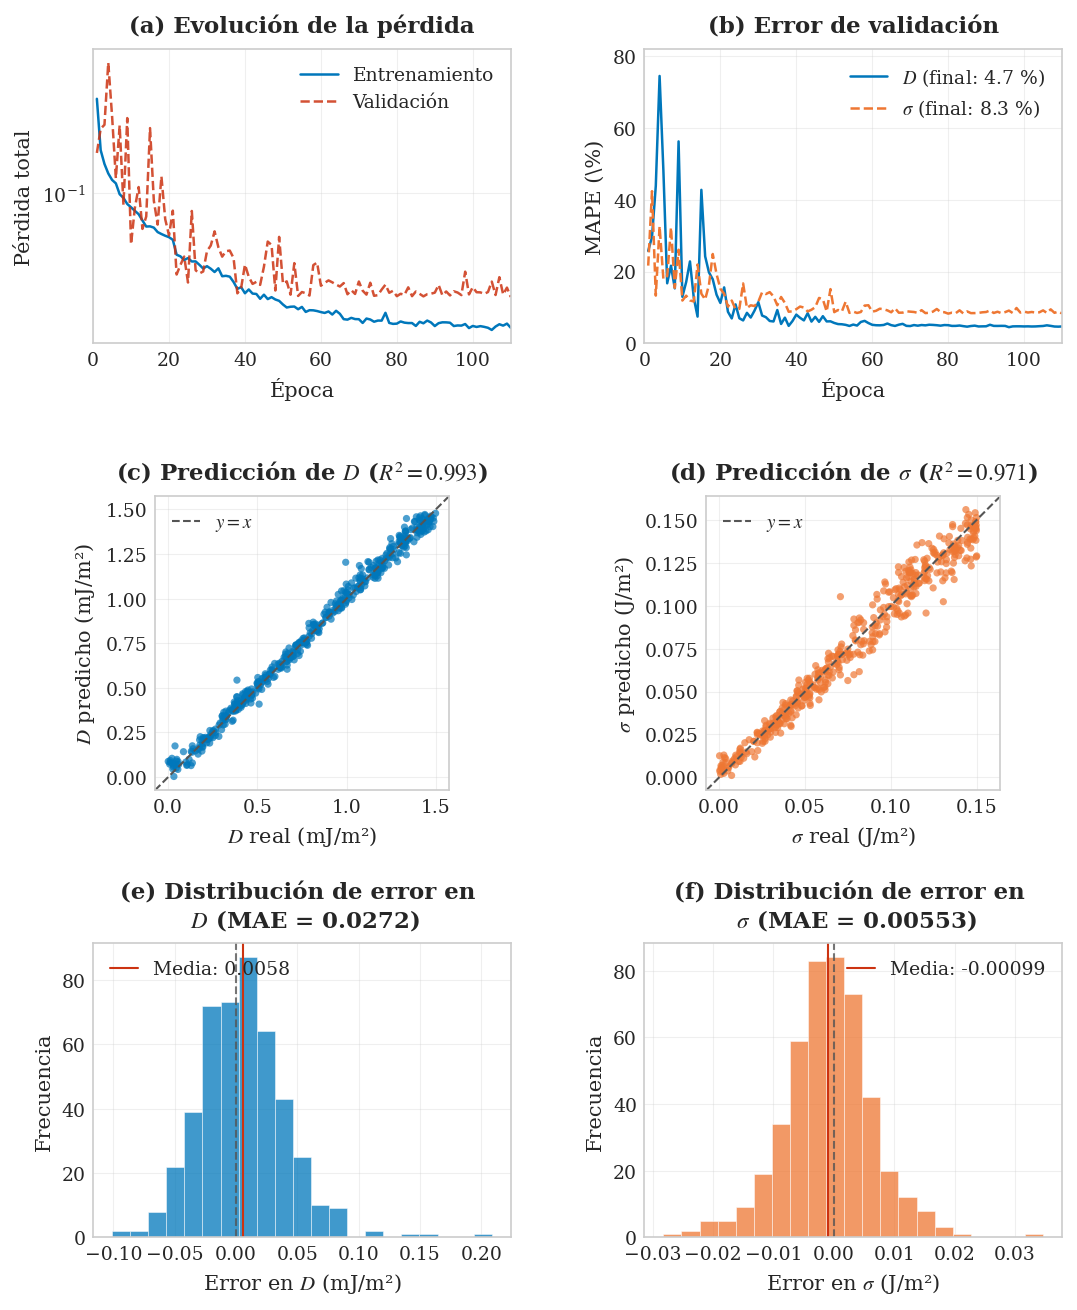


✓ Figures saved:
   PNG: outputs_ablation_final/pinn__with_dpectral__nonfiltered_noannealing/figures/results_pinn__with_dpectral__nonfiltered_noannealing.png
   PDF: outputs_ablation_final/pinn__with_dpectral__nonfiltered_noannealing/figures/results_pinn__with_dpectral__nonfiltered_noannealing.pdf

TABLA LATEX PARA EL DOCUMENTO

\begin{table}[htbp]
\centering
\caption{Métricas de desempeño del modelo PINN en el conjunto de validación 
          ($n = 461$ muestras).}
\label{tab:metrics}
\begin{tabular}{lcc}
\toprule
Métrica & $D$ (DMI) & $\sigma$ (Energía de pared) \\
\midrule
$R^2$ & 0.993 & 0.971 \\
MAPE (\%) & 4.7 & 8.3 \\
MAE & 0.0272 mJ/m² & 0.00553 J/m² \\
Sesgo (media del error) & 0.0058 mJ/m² & -0.00099 J/m² \\
\bottomrule
\end{tabular}
\end{table}



In [47]:
# ==============================================================================
# CELL 13: VISUALIZATION (Paper-ready style + CSV export)
# ==============================================================================
# ==============================================================================
# VISUALIZATION - THESIS STYLE (Improved version)
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from pathlib import Path

# =============================================================================
# 1. SAVE TRAINING HISTORY TO CSV (sin cambios)
# =============================================================================
history_df = pd.DataFrame({
    'epoch': np.arange(1, len(history['train_loss_total']) + 1),
    'train_loss_total': history['train_loss_total'],
    'train_loss_reg': history['train_loss_reg'],
    'train_loss_energy': history['train_loss_energy'],
    'train_loss_spectral': history['train_loss_spectral'],
    'val_loss_total': history['val_loss_total'],
    'val_loss_reg': history['val_loss_reg'],
    'val_loss_energy': history['val_loss_energy'],
    'val_loss_spectral': history['val_loss_spectral'],
    'val_mape_D': history['val_mape_D'],
    'val_mape_sigma': history['val_mape_sigma'],
    'lr': history['lr'],
    'weight_energy': history['weight_energy'],
    'weight_spectral': history['weight_spectral'],
})

csv_path = FIG_DIR / f"training_history_{RUN_TAG}.csv"
history_df.to_csv(csv_path, index=False)
print(f"✓ Training history saved to {csv_path}")

# =============================================================================
# 2. THESIS-READY STYLE CONFIGURATION
# =============================================================================



# Paleta de colores profesional (colorblind-friendly, print-safe)
COLORS = {
    # Primarios
    'train': '#0077BB',       # Azul fuerte - entrenamiento
    'val': '#CC3311',         # Rojo - validación
    
    # Parámetros
    'D': '#0077BB',           # Azul - DMI
    'sigma': '#EE7733',       # Naranja - sigma
    
    # Componentes de loss
    'regression': '#0077BB',  # Azul
    'spectral': '#009988',    # Verde azulado
    'energy': '#EE7733',      # Naranja
    
    # Referencias
    'reference': '#555555',   # Gris oscuro
    'highlight': '#CC3311',   # Rojo para destacar
    'neutral': '#BBBBBB',     # Gris claro
}

# Aplicar estilo
setup_thesis_style()

# =============================================================================
# 3. GET FINAL VALUES FROM HISTORY
# =============================================================================
final_mape_D = history['val_mape_D'][-1]
final_mape_sigma = history['val_mape_sigma'][-1]
final_val_loss = history['val_loss_total'][-1]

print(f"\nFinal metrics from training history:")
print(f"  MAPE D: {final_mape_D:.1f}%")
print(f"  MAPE σ: {final_mape_sigma:.1f}%")
print(f"  Val Loss: {final_val_loss:.4e}")

# =============================================================================
# 4. CREATE MAIN FIGURE
# =============================================================================

# Tamaño optimizado para tesis (ancho de página completa)
fig = plt.figure(figsize=(7.6, 8.9))  # Ligeramente más compacto
gs = fig.add_gridspec(3, 2, hspace=0.52, wspace=0.32,
                      left=0.10, right=0.95, top=0.95, bottom=0.06)

epochs = np.arange(1, len(history['train_loss_total']) + 1)

# -------------------------------------------------------------------------
# (a) Loss Evolution
# -------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])

ax1.semilogy(epochs, history['train_loss_total'], 
             color=COLORS['train'], linewidth=1.2, label='Entrenamiento')
ax1.semilogy(epochs, history['val_loss_total'], 
             color=COLORS['val'], linewidth=1.2, linestyle='--', 
             alpha=0.85, label='Validación')

ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida total')
ax1.set_title('(a) Evolución de la pérdida', fontweight='semibold', pad=8)
ax1.legend(loc='upper right')
ax1.set_xlim([0, len(epochs)])

# -------------------------------------------------------------------------
# (b) Validation MAPE
# -------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])

ax2.plot(epochs, history['val_mape_D'], 
         color=COLORS['D'], linewidth=1.2,
         label=f'$D$ (final: {final_mape_D:.1f} %)')
ax2.plot(epochs, history['val_mape_sigma'], 
         color=COLORS['sigma'], linewidth=1.2, linestyle='--',
         label=f'$\\sigma$ (final: {final_mape_sigma:.1f} %)')

ax2.set_xlabel('Época')
ax2.set_ylabel('MAPE (\\%)')
ax2.set_title('(b) Error de validación', fontweight='semibold', pad=8)
ax2.legend(loc='upper right')
ax2.set_ylim(bottom=0, top=min(100, max(max(history['val_mape_D'][:30]), 
                                         max(history['val_mape_sigma'][:30])) * 1.1))
ax2.set_xlim([0, len(epochs)])

# -------------------------------------------------------------------------
# (c) D Prediction Scatter
# -------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 0])

D_plot = D_pred_val.numpy() * 1e3  # Convert to mJ/m²
D_true_plot = D_true_val.numpy() * 1e3

# Scatter con transparencia adaptativa al número de puntos
n_points = len(D_plot)
alpha = max(0.3, min(0.7, 500/n_points))

ax3.scatter(D_true_plot, D_plot, s=12, alpha=alpha, 
            c=COLORS['D'], edgecolors='none', rasterized=True)

# Línea de predicción perfecta
d_min = min(D_true_plot.min(), D_plot.min())
d_max = max(D_true_plot.max(), D_plot.max())
d_margin = (d_max - d_min) * 0.05
d_lim = [d_min - d_margin, d_max + d_margin]

ax3.plot(d_lim, d_lim, '--', color=COLORS['reference'], 
         linewidth=1.0, label='$y = x$', zorder=1)

ax3.set_xlabel('$D$ real (mJ/m²)')
ax3.set_ylabel('$D$ predicho (mJ/m²)')
ax3.set_title(f'(c) Predicción de $D$ ($R^2 = {r2_D:.3f}$)', 
              fontweight='semibold', pad=8)
ax3.set_xlim(d_lim)
ax3.set_ylim(d_lim)
ax3.set_aspect('equal', adjustable='box')
ax3.legend(loc='upper left', handlelength=1.5)

# -------------------------------------------------------------------------
# (d) σ Prediction Scatter
# -------------------------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 1])

s_plot = s_pred_val.numpy()
s_true_plot = s_true_val.numpy()

ax4.scatter(s_true_plot, s_plot, s=12, alpha=alpha,
            c=COLORS['sigma'], edgecolors='none', rasterized=True)

# Línea de predicción perfecta
s_min = min(s_true_plot.min(), s_plot.min())
s_max = max(s_true_plot.max(), s_plot.max())
s_margin = (s_max - s_min) * 0.05
s_lim = [s_min - s_margin, s_max + s_margin]

ax4.plot(s_lim, s_lim, '--', color=COLORS['reference'], 
         linewidth=1.0, label='$y = x$', zorder=1)

ax4.set_xlabel('$\\sigma$ real (J/m²)')
ax4.set_ylabel('$\\sigma$ predicho (J/m²)')
ax4.set_title(f'(d) Predicción de $\\sigma$ ($R^2 = {r2_s:.3f}$)', 
              fontweight='semibold', pad=8)
ax4.set_xlim(s_lim)
ax4.set_ylim(s_lim)
ax4.set_aspect('equal', adjustable='box')
ax4.legend(loc='upper left', handlelength=1.5)

# -------------------------------------------------------------------------
# (e) D Error Distribution
# -------------------------------------------------------------------------
ax5 = fig.add_subplot(gs[2, 0])

D_error = (D_pred_val - D_true_val).numpy() * 1e3
mae_D = np.mean(np.abs(D_error))
mean_D_error = np.mean(D_error)

# Histograma con bins apropiados
n_bins = min(30, max(15, int(np.sqrt(len(D_error)))))
ax5.hist(D_error, bins=n_bins, alpha=0.75, color=COLORS['D'], 
         edgecolor='white', linewidth=0.3)

# Líneas de referencia
ax5.axvline(0, color=COLORS['reference'], linestyle='--', 
            linewidth=1.0, alpha=0.8)
ax5.axvline(mean_D_error, color=COLORS['highlight'], linestyle='-', 
            linewidth=1.0, label=f'Media: {mean_D_error:.4f}')

ax5.set_xlabel('Error en $D$ (mJ/m²)')
ax5.set_ylabel('Frecuencia')
ax5.set_title(f'(e) Distribución de error en \n $D$ (MAE = {mae_D:.4f})', 
              fontweight='semibold', pad=8)
ax5.legend(loc='upper left', handlelength=1.5)

# -------------------------------------------------------------------------
# (f) σ Error Distribution
# -------------------------------------------------------------------------
ax6 = fig.add_subplot(gs[2, 1])

s_error = (s_pred_val - s_true_val).numpy()
mae_s = np.mean(np.abs(s_error))
mean_s_error = np.mean(s_error)

ax6.hist(s_error, bins=n_bins, alpha=0.75, color=COLORS['sigma'],
         edgecolor='white', linewidth=0.3)

ax6.axvline(0, color=COLORS['reference'], linestyle='--', 
            linewidth=1.0, alpha=0.8)
ax6.axvline(mean_s_error, color=COLORS['highlight'], linestyle='-', 
            linewidth=1.0, label=f'Media: {mean_s_error:.5f}')

ax6.set_xlabel('Error en $\\sigma$ (J/m²)')
ax6.set_ylabel('Frecuencia')
ax6.set_title(f'(f) Distribución de error en \n $\\sigma$ (MAE = {mae_s:.5f})', 
              fontweight='semibold', pad=8)
ax6.legend(loc='upper right', handlelength=1.5)

# =============================================================================
# 5. SAVE FIGURE
# =============================================================================
fig_path = FIG_DIR / f"results_{RUN_TAG}.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')

pdf_path = FIG_DIR / f"results_{RUN_TAG}.pdf"
plt.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')

plt.show()

print(f"\n✓ Figures saved:")
print(f"   PNG: {fig_path}")
print(f"   PDF: {pdf_path}")

# =============================================================================
# 6. LATEX TABLE
# =============================================================================
print("\n" + "="*60)
print("TABLA LATEX PARA EL DOCUMENTO")
print("="*60)
print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Métricas de desempeño del modelo PINN en el conjunto de validación 
          ($n = {len(D_plot)}$ muestras).}}
\\label{{tab:metrics}}
\\begin{{tabular}}{{lcc}}
\\toprule
Métrica & $D$ (DMI) & $\\sigma$ (Energía de pared) \\\\
\\midrule
$R^2$ & {r2_D:.3f} & {r2_s:.3f} \\\\
MAPE (\\%) & {final_mape_D:.1f} & {final_mape_sigma:.1f} \\\\
MAE & {mae_D:.4f} mJ/m² & {mae_s:.5f} J/m² \\\\
Sesgo (media del error) & {mean_D_error:.4f} mJ/m² & {mean_s_error:.5f} J/m² \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")

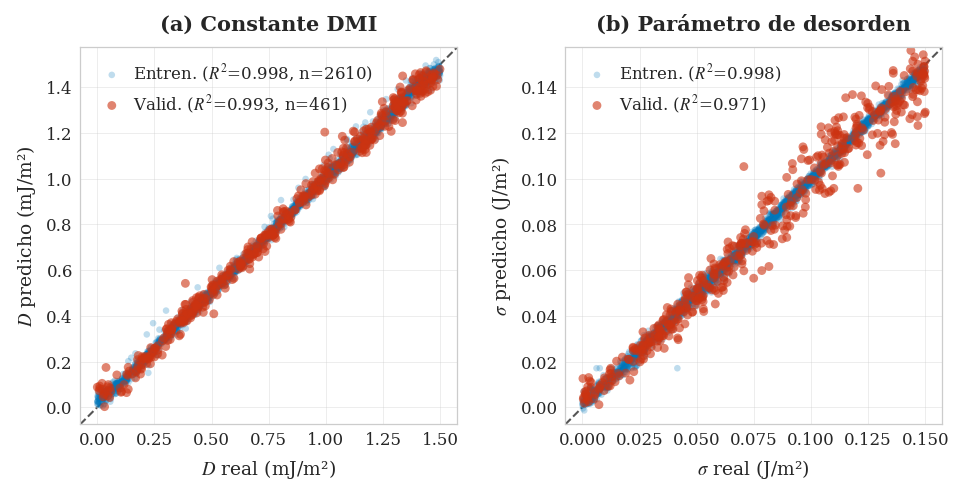


✓ Figura guardada:
   PNG: outputs_ablation_final/pinn__with_dpectral__nonfiltered_noannealing/figures/train_vs_val_pinn__with_dpectral__nonfiltered_noannealing.png
   PDF: outputs_ablation_final/pinn__with_dpectral__nonfiltered_noannealing/figures/train_vs_val_pinn__with_dpectral__nonfiltered_noannealing.pdf

COMPARACIÓN ENTRENAMIENTO VS VALIDACIÓN
Métrica              Entrenamiento     Validación       
-------------------------------------------------------
R² (D)               0.9980            0.9929           
R² (σ)               0.9981            0.9714           
n muestras           2610              461              

\begin{table}[htbp]
\centering
\caption{Comparación del desempeño en conjuntos de entrenamiento y validación.}
\label{tab:train_val_comparison}
\begin{tabular}{lccc}
\toprule
Parámetro & Conjunto & $R^2$ & $n$ \\
\midrule
\multirow{2}{*}{$D$ (DMI)} 
    & Entrenamiento & 0.998 & 2610 \\
    & Validación & 0.993 & 461 \\
\midrule
\multirow{2}{*}{$\sigma$ (Desor

In [48]:
# ==============================================================================
# TRAIN VS VAL SCATTER PLOTS (Thesis-ready style)
# ==============================================================================

model.eval()
train_preds, train_targets = [], []
val_preds, val_targets = [], []

with torch.no_grad():
    for imgs, m_fields, targets, run_ids in train_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds_unnorm = outputs.cpu() * t_std_t.cpu() + t_mean_t.cpu()
        targets_unnorm = targets * t_std_t.cpu() + t_mean_t.cpu()
        train_preds.append(preds_unnorm)
        train_targets.append(targets_unnorm)
    
    for imgs, m_fields, targets, run_ids in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds_unnorm = outputs.cpu() * t_std_t.cpu() + t_mean_t.cpu()
        targets_unnorm = targets * t_std_t.cpu() + t_mean_t.cpu()
        val_preds.append(preds_unnorm)
        val_targets.append(targets_unnorm)

train_preds = torch.cat(train_preds).numpy()
train_targets = torch.cat(train_targets).numpy()
val_preds = torch.cat(val_preds).numpy()
val_targets = torch.cat(val_targets).numpy()

# =============================================================================
# Compute R² for each split
# =============================================================================
def compute_r2(pred, true):
    ss_res = np.sum((true - pred)**2)
    ss_tot = np.sum((true - np.mean(true))**2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else 0

r2_D_train = compute_r2(train_preds[:, 0], train_targets[:, 0])
r2_D_val = compute_r2(val_preds[:, 0], val_targets[:, 0])
r2_s_train = compute_r2(train_preds[:, 1], train_targets[:, 1])
r2_s_val = compute_r2(val_preds[:, 1], val_targets[:, 1])

# =============================================================================
# Thesis-ready style (consistent with main results figure)
# =============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.6,
    'grid.linewidth': 0.4,
    'grid.alpha': 0.4,
    'lines.linewidth': 1.2,
})

# Colores consistentes con figura principal
COLORS = {
    'train': '#0077BB',      # Azul - entrenamiento
    'val': '#CC3311',        # Rojo - validación
    'reference': '#555555',  # Gris - línea y=x
}

# =============================================================================
# Create figure
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(6.5, 3.2))

# Preparar datos
D_train_true = train_targets[:, 0] * 1e3  # a mJ/m²
D_train_pred = train_preds[:, 0] * 1e3
D_val_true = val_targets[:, 0] * 1e3
D_val_pred = val_preds[:, 0] * 1e3

s_train_true = train_targets[:, 1]
s_train_pred = train_preds[:, 1]
s_val_true = val_targets[:, 1]
s_val_pred = val_preds[:, 1]

n_train = len(train_preds)
n_val = len(val_preds)

# -------------------------------------------------------------------------
# (a) D prediction
# -------------------------------------------------------------------------
ax = axes[0]

# Training data (fondo, más transparente)
ax.scatter(D_train_true, D_train_pred, 
           s=10, alpha=0.25, c=COLORS['train'], edgecolors='none',
           label=f'Entren. ($R^2$={r2_D_train:.3f}, n={n_train})',
           rasterized=True)

# Validation data (frente, más visible)
ax.scatter(D_val_true, D_val_pred, 
           s=18, alpha=0.6, c=COLORS['val'], edgecolors='none',
           label=f'Valid. ($R^2$={r2_D_val:.3f}, n={n_val})',
           rasterized=True)

# Línea de predicción perfecta
d_min = min(D_train_true.min(), D_val_true.min())
d_max = max(D_train_true.max(), D_val_true.max())
d_margin = (d_max - d_min) * 0.05
d_lim = [d_min - d_margin, d_max + d_margin]

ax.plot(d_lim, d_lim, '--', color=COLORS['reference'], 
        linewidth=1.0, zorder=0)

ax.set_xlabel('$D$ real (mJ/m²)')
ax.set_ylabel('$D$ predicho (mJ/m²)')
ax.set_title('(a) Constante DMI', fontweight='semibold', pad=8)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8',
          handletextpad=0.3, borderpad=0.4)
ax.set_xlim(d_lim)
ax.set_ylim(d_lim)
ax.set_aspect('equal', adjustable='box')

# -------------------------------------------------------------------------
# (b) σ prediction
# -------------------------------------------------------------------------
ax = axes[1]

# Training data
ax.scatter(s_train_true, s_train_pred,
           s=10, alpha=0.25, c=COLORS['train'], edgecolors='none',
           label=f'Entren. ($R^2$={r2_s_train:.3f})',
           rasterized=True)

# Validation data
ax.scatter(s_val_true, s_val_pred,
           s=18, alpha=0.6, c=COLORS['val'], edgecolors='none',
           label=f'Valid. ($R^2$={r2_s_val:.3f})',
           rasterized=True)

# Línea de predicción perfecta
s_min = min(s_train_true.min(), s_val_true.min())
s_max = max(s_train_true.max(), s_val_true.max())
s_margin = (s_max - s_min) * 0.05
s_lim = [s_min - s_margin, s_max + s_margin]

ax.plot(s_lim, s_lim, '--', color=COLORS['reference'], 
        linewidth=1.0, zorder=0)

ax.set_xlabel('$\\sigma$ real (J/m²)')
ax.set_ylabel('$\\sigma$ predicho (J/m²)')
ax.set_title('(b) Parámetro de desorden', fontweight='semibold', pad=8)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8',
          handletextpad=0.3, borderpad=0.4)
ax.set_xlim(s_lim)
ax.set_ylim(s_lim)
ax.set_aspect('equal', adjustable='box')

# =============================================================================
# Save
# =============================================================================
plt.tight_layout(w_pad=1.5)

fig_path = FIG_DIR / f"train_vs_val_{RUN_TAG}.png"
pdf_path = FIG_DIR / f"train_vs_val_{RUN_TAG}.pdf"

plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Figura guardada:")
print(f"   PNG: {fig_path}")
print(f"   PDF: {pdf_path}")

# =============================================================================
# Summary table
# =============================================================================
print(f"\n{'='*55}")
print(f"COMPARACIÓN ENTRENAMIENTO VS VALIDACIÓN")
print(f"{'='*55}")
print(f"{'Métrica':<20} {'Entrenamiento':<17} {'Validación':<17}")
print(f"{'-'*55}")
print(f"{'R² (D)':<20} {r2_D_train:<17.4f} {r2_D_val:<17.4f}")
print(f"{'R² (σ)':<20} {r2_s_train:<17.4f} {r2_s_val:<17.4f}")
print(f"{'n muestras':<20} {n_train:<17} {n_val:<17}")
print(f"{'='*55}")

# LaTeX table
print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Comparación del desempeño en conjuntos de entrenamiento y validación.}}
\\label{{tab:train_val_comparison}}
\\begin{{tabular}}{{lccc}}
\\toprule
Parámetro & Conjunto & $R^2$ & $n$ \\\\
\\midrule
\\multirow{{2}}{{*}}{{$D$ (DMI)}} 
    & Entrenamiento & {r2_D_train:.3f} & {n_train} \\\\
    & Validación & {r2_D_val:.3f} & {n_val} \\\\
\\midrule
\\multirow{{2}}{{*}}{{$\\sigma$ (Desorden)}} 
    & Entrenamiento & {r2_s_train:.3f} & {n_train} \\\\
    & Validación & {r2_s_val:.3f} & {n_val} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")

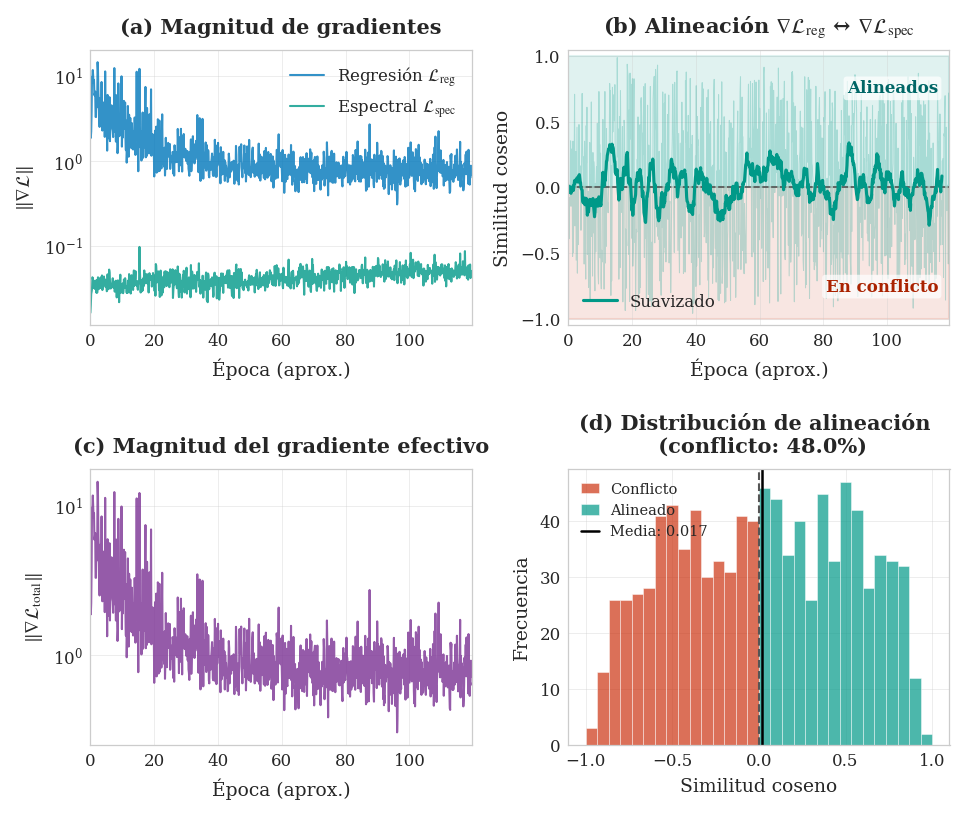


✓ Análisis de gradientes guardado:
   PNG: outputs_ablation_final/pinn__with_dpectral__nonfiltered_noannealing/figures/gradient_analysis_pinn__with_dpectral__nonfiltered_noannealing.png
   PDF: outputs_ablation_final/pinn__with_dpectral__nonfiltered_noannealing/figures/gradient_analysis_pinn__with_dpectral__nonfiltered_noannealing.pdf

RESUMEN DE CONFLICTO DE GRADIENTES
Métrica                                       Valor          
------------------------------------------------------------
Muestras de gradiente totales                 957            
Similitud coseno media (Reg ↔ Spec)           0.0170         
Tasa de conflicto (coseno < 0)                48.0          %

\begin{table}[htbp]
\centering
\caption{Análisis de conflicto entre gradientes de los componentes de la función de pérdida.}
\label{tab:gradient_conflict}
\begin{tabular}{lc}
\toprule
Métrica & Valor \\
\midrule
Similitud coseno media & 0.017 \\
Tasa de conflicto (\%) & 48.0 \\
Muestras totales & 957 \\
\bottomrule

In [49]:
# ==============================================================================
# GRADIENT CONFLICT VISUALIZATION (Thesis-ready)
# ==============================================================================

if gradient_tracker and len(gradient_tracker.history['grad_norm_reg']) > 0:
    
    # =========================================================================
    # Style setup (consistent with other figures)
    # =========================================================================
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
        'mathtext.fontset': 'stix',
        'font.size': 9,
        'axes.titlesize': 10,
        'axes.labelsize': 9,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'axes.linewidth': 0.6,
        'grid.linewidth': 0.4,
        'grid.alpha': 0.4,
    })
    
    # Colors (consistent palette)
    COLORS = {
        'regression': '#0077BB',   # Azul
        'spectral': '#009988',     # Verde azulado
        'combined': '#7B3294',     # Púrpura
        'reference': '#555555',    # Gris
        'aligned': '#009988',      # Verde (mismo que spectral)
        'conflict': '#CC3311',     # Rojo
    }
    
    # =========================================================================
    # Prepare data
    # =========================================================================
    steps = np.arange(len(gradient_tracker.history['grad_norm_reg']))
    summary = gradient_tracker.get_summary()
    
    # Convert steps to epochs (approximate)
    steps_per_epoch = len(train_loader) // GRAD_TRACK_INTERVAL
    epochs_approx = steps / max(steps_per_epoch, 1)
    
    # =========================================================================
    # Create figure
    # =========================================================================
    fig, axes = plt.subplots(2, 2, figsize=(6.5, 5.5))
    
    # -------------------------------------------------------------------------
    # (a) Gradient Magnitudes
    # -------------------------------------------------------------------------
    ax = axes[0, 0]
    
    ax.semilogy(epochs_approx, gradient_tracker.history['grad_norm_reg'], 
                label=r'Regresión $\mathcal{L}_{\mathrm{reg}}$', 
                color=COLORS['regression'], alpha=0.8, linewidth=1.0)
    ax.semilogy(epochs_approx, gradient_tracker.history['grad_norm_spectral'], 
                label=r'Espectral $\mathcal{L}_{\mathrm{spec}}$', 
                color=COLORS['spectral'], alpha=0.8, linewidth=1.0)
    
    ax.set_xlabel('Época (aprox.)')
    ax.set_ylabel(r'$\|\nabla \mathcal{L}\|$')
    ax.set_title('(a) Magnitud de gradientes', fontweight='semibold', pad=8)
    ax.legend(loc='upper right', framealpha=0.95, edgecolor='0.8')
    ax.set_xlim([0, epochs_approx.max()])
    
    # -------------------------------------------------------------------------
    # (b) Gradient Alignment Over Time - FIXED LEGEND ISSUE
    # -------------------------------------------------------------------------
    ax = axes[0, 1]
    
    cosine_data = np.array(gradient_tracker.history['cosine_reg_spectral'])
    
    # Background zones (sin leyenda - usaremos texto)
    ax.fill_between([0, epochs_approx.max()], 0, 1, 
                    alpha=0.12, color=COLORS['aligned'], zorder=0)
    ax.fill_between([0, epochs_approx.max()], -1, 0, 
                    alpha=0.12, color=COLORS['conflict'], zorder=0)
    
    # Texto con fondo para mejor contraste
    ax.text(epochs_approx.max() * 0.97, 0.82, 'Alineados', 
            fontsize=8, color='#006666', fontweight='bold',
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                      alpha=0.7, edgecolor='none'))
    
    ax.text(epochs_approx.max() * 0.97, -0.82, 'En conflicto', 
            fontsize=8, color='#AA2200', fontweight='bold',
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                      alpha=0.7, edgecolor='none'))
    
    # Raw data (muy transparente, de fondo)
    ax.plot(epochs_approx, cosine_data, color=COLORS['spectral'], 
            alpha=0.25, linewidth=0.5, zorder=1)
    
    # Smoothed curve
    window = min(20, len(steps) // 10) if len(steps) > 20 else 1
    if window > 1:
        cosine_smooth = np.convolve(cosine_data, np.ones(window)/window, mode='valid')
        epochs_smooth = epochs_approx[:len(cosine_smooth)]
        ax.plot(epochs_smooth, cosine_smooth, color=COLORS['spectral'], 
                linewidth=1.5, label='Suavizado', zorder=2)
    
    # Reference line
    ax.axhline(0, color=COLORS['reference'], linestyle='--', linewidth=0.8, zorder=1)
    
    ax.set_xlabel('Época (aprox.)')
    ax.set_ylabel('Similitud coseno')
    ax.set_title(r'(b) Alineación $\nabla\mathcal{L}_{\mathrm{reg}}$ ↔ $\nabla\mathcal{L}_{\mathrm{spec}}$', 
                 fontweight='semibold', pad=8)
    ax.set_ylim(-1.05, 1.05)
    ax.set_xlim([0, epochs_approx.max()])
    
    # Leyenda compacta solo para la curva
    ax.legend(loc='lower left', framealpha=0.95, edgecolor='0.8')
    
    # -------------------------------------------------------------------------
    # (c) Combined Gradient Norm
    # -------------------------------------------------------------------------
    ax = axes[1, 0]
    
    ax.semilogy(epochs_approx, gradient_tracker.history['grad_norm_combined'], 
                color=COLORS['combined'], alpha=0.8, linewidth=1.0)
    
    ax.set_xlabel('Época (aprox.)')
    ax.set_ylabel(r'$\|\nabla \mathcal{L}_{\mathrm{total}}\|$')
    ax.set_title('(c) Magnitud del gradiente efectivo', fontweight='semibold', pad=8)
    ax.set_xlim([0, epochs_approx.max()])
    
    # Warmup line
    if USE_ANNEALING:
        ax.axvline(WARMUP_EPOCHS, color=COLORS['reference'], linestyle=':', 
                   linewidth=1.0, label=f'Fin warmup (época {WARMUP_EPOCHS})')
        ax.legend(loc='upper right', framealpha=0.95, edgecolor='0.8')
    
    # -------------------------------------------------------------------------
    # (d) Alignment Distribution
    # -------------------------------------------------------------------------
    ax = axes[1, 1]
    
    cosine_vals = np.array(gradient_tracker.history['cosine_reg_spectral'])
    conflict_rate = summary.get('conflict_rate_reg_spectral', 0) * 100
    mean_cosine = np.mean(cosine_vals)
    
    # Histogram con colores por región
    bins = np.linspace(-1, 1, 31)
    n_neg, _, _ = ax.hist(cosine_vals[cosine_vals < 0], bins=bins[bins <= 0], 
                          alpha=0.7, color=COLORS['conflict'],
                          edgecolor='white', linewidth=0.3, label='Conflicto')
    n_pos, _, _ = ax.hist(cosine_vals[cosine_vals >= 0], bins=bins[bins >= 0], 
                          alpha=0.7, color=COLORS['aligned'],
                          edgecolor='white', linewidth=0.3, label='Alineado')
    
    # Reference lines
    ax.axvline(0, color=COLORS['reference'], linestyle='--', linewidth=1.0)
    ax.axvline(mean_cosine, color='black', linestyle='-', linewidth=1.2,
               label=f'Media: {mean_cosine:.3f}')
    
    ax.set_xlabel('Similitud coseno')
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'(d) Distribución de alineación \n (conflicto: {conflict_rate:.1f}%)', 
                 fontweight='semibold', pad=8)
    ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8',
              fontsize=7, handlelength=1.2)
    ax.set_xlim([-1.1, 1.1])
    
    # =========================================================================
    # Final adjustments and save
    # =========================================================================
    plt.tight_layout(h_pad=1.8, w_pad=1.2)
    
    fig_path = FIG_DIR / f"gradient_analysis_{RUN_TAG}.png"
    pdf_path = FIG_DIR / f"gradient_analysis_{RUN_TAG}.pdf"
    
    plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')
    plt.show()
    
    # =========================================================================
    # Print summary
    # =========================================================================
    print(f"\n✓ Análisis de gradientes guardado:")
    print(f"   PNG: {fig_path}")
    print(f"   PDF: {pdf_path}")
    
    print(f"\n{'='*60}")
    print(f"RESUMEN DE CONFLICTO DE GRADIENTES")
    print(f"{'='*60}")
    print(f"{'Métrica':<45} {'Valor':<15}")
    print(f"{'-'*60}")
    print(f"{'Muestras de gradiente totales':<45} {len(steps):<15}")
    print(f"{'Similitud coseno media (Reg ↔ Spec)':<45} {mean_cosine:<15.4f}")
    print(f"{'Tasa de conflicto (coseno < 0)':<45} {conflict_rate:<14.1f}%")
    print(f"{'='*60}")
    
    # LaTeX table
    print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Análisis de conflicto entre gradientes de los componentes de la función de pérdida.}}
\\label{{tab:gradient_conflict}}
\\begin{{tabular}}{{lc}}
\\toprule
Métrica & Valor \\\\
\\midrule
Similitud coseno media & {mean_cosine:.3f} \\\\
Tasa de conflicto (\\%) & {conflict_rate:.1f} \\\\
Muestras totales & {len(steps)} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")

else:
    print("⚠️ No hay datos de seguimiento de gradientes disponibles.")

In [50]:
# ==============================================================================
# CELL 15: OOD EVALUATION - CONFIGURATION
# ==============================================================================
# Run this AFTER training, or in a new session to load saved model

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# -------------------------------------------------
# OOD Data Paths (MODIFY THESE!)
# -------------------------------------------------
OOD_CSV_PATH = Path("../mumax_dataset_ku_by_block_disorder_phy_outside_clamp/training_index.csv")  # <-- CHANGE THIS
OOD_IMG_DIR = Path("../images/mumax_dataset_ku_by_block_disorder_phy_outside_clamp_both_above")               # <-- CHANGE THIS
OOD_NPY_DIR = Path("../mumax_dataset_ku_by_block_disorder_phy_outside_clamp_both_above")            # <-- CHANGE THIS (if using energy validation)

#RUN_TAG = "improved_pinn_0.5_physics"
#FIG_DIR = Path("./outputs_improved_pinn_january7/" + RUN_TAG + "/figures/")


# Model checkpoint to load
MODEL_CHECKPOINT = BEST_PATH  # Uses the path from training, or set manually:
#MODEL_CHECKPOINT = Path("./outputs_improved_pinn_january7/" + RUN_TAG + "/checkpoints/best_"+ RUN_TAG +".pt")

# Do we need NPY files for OOD? (Set False if you only have images)
OOD_LOAD_NPY = True  # Usually False for quick evaluation

# Training ranges (for distance calculation)
TRAIN_D_MIN, TRAIN_D_MAX = ID_D_RANGE  # From config: (0.3e-3, 1.5e-3)
TRAIN_SIGMA_MIN, TRAIN_SIGMA_MAX = ID_SIGMA_RANGE  # From config: (0.02, 0.15)

print(f"OOD Evaluation Configuration:")
print(f"  OOD CSV: {OOD_CSV_PATH}")
print(f"  OOD Images: {OOD_IMG_DIR}")
print(f"  Model: {MODEL_CHECKPOINT}")
print(f"  Training D range: [{TRAIN_D_MIN*1e3:.2f}, {TRAIN_D_MAX*1e3:.2f}] mJ/m²")
print(f"  Training σ range: [{TRAIN_SIGMA_MIN:.2f}, {TRAIN_SIGMA_MAX:.2f}]")


OOD Evaluation Configuration:
  OOD CSV: ../mumax_dataset_ku_by_block_disorder_phy_outside_clamp/training_index.csv
  OOD Images: ../images/mumax_dataset_ku_by_block_disorder_phy_outside_clamp_both_above
  Model: outputs_ablation_final/pinn__with_dpectral__nonfiltered_noannealing/checkpoints/best_pinn__with_dpectral__nonfiltered_noannealing.pt
  Training D range: [0.30, 1.50] mJ/m²
  Training σ range: [0.02, 0.15]


In [51]:

# ==============================================================================
# CELL 16: LOAD MODEL FROM CHECKPOINT
# ==============================================================================

# Load checkpoint
checkpoint = torch.load(CKPT_DIR / f"best_{RUN_TAG}.pt", map_location=device, weights_only=False)#torch.load(MODEL_CHECKPOINT, map_location=device, weights_only=False)

# Recreate model (must match architecture!)
model_ood = ImprovedPINN().to(device)
model_ood.load_state_dict(checkpoint['model_state_dict'])
model_ood.eval()

# Get normalization parameters
ood_t_mean = checkpoint['target_mean']
ood_t_std = checkpoint['target_std']
ood_t_mean_t = torch.tensor(ood_t_mean, device=device, dtype=torch.float32)
ood_t_std_t = torch.tensor(ood_t_std, device=device, dtype=torch.float32)

print(f"✓ Model loaded from epoch {checkpoint['epoch']}")
print(f"  Validation loss at save: {checkpoint['val_loss']:.4e}")
print(f"  Target normalization: mean=[{ood_t_mean[0]*1e3:.3f} mJ/m², {ood_t_mean[1]:.4f}]")
print(f"                        std=[{ood_t_std[0]*1e3:.3f}, {ood_t_std[1]:.4f}]")


✓ Model loaded from epoch 110
  Validation loss at save: 2.2787e-02
  Target normalization: mean=[0.785 mJ/m², 0.0767]
                        std=[0.422, 0.0420]


In [52]:

# ==============================================================================
# CELL 17: OOD DATASET CLASS (Simplified - no NPY needed)
# ==============================================================================

class OODDataset(Dataset):
    """
    Simple dataset for OOD evaluation.
    Only loads images, no NPY files needed.
    """
    
    def __init__(self, csv_path, img_dir, index_col='run_id',
                 col_D='Dind', col_sigma='sigma_nominal',
                 img_prefix='mz_binary_', img_ext='.png',
                 target_mean=None, target_std=None):
        
        self.df = pd.read_csv(csv_path)
        self.df.set_index(index_col, inplace=True)
        
        self.img_dir = Path(img_dir)
        self.col_D = col_D
        self.col_sigma = col_sigma
        
        self.target_mean = target_mean
        self.target_std = target_std
        
        self.records = []
        
        # Find all images
        img_files = sorted(self.img_dir.glob(f"{img_prefix}*{img_ext}"))
        
        for img_path in img_files:
            try:
                run_id = int(img_path.stem.replace(img_prefix, ""))
            except ValueError:
                continue
            
            if run_id not in self.df.index:
                continue
            
            row = self.df.loc[run_id]
            D = float(row[col_D])
            sigma = float(row[col_sigma])
            
            self.records.append({
                'img_path': img_path,
                'D': D,
                'sigma': sigma,
                'run_id': run_id
            })
        
        print(f"[OODDataset] Loaded {len(self.records)} samples")
        
        if len(self.records) > 0:
            D_vals = [r['D'] for r in self.records]
            s_vals = [r['sigma'] for r in self.records]
            print(f"  D range: [{min(D_vals)*1e3:.2f}, {max(D_vals)*1e3:.2f}] mJ/m²")
            print(f"  σ range: [{min(s_vals):.3f}, {max(s_vals):.3f}]")
    
    def __len__(self):
        return len(self.records)
    
    def __getitem__(self, idx):
        r = self.records[idx]
        
        # Load image
        arr = load_16bit_image(r['img_path'])
        img = torch.from_numpy(arr).unsqueeze(0).float()
        img = img.repeat(3, 1, 1)  # Expand to 3 channels
        
        # Target (normalized)
        target = np.array([r['D'], r['sigma']], dtype=np.float32)
        if self.target_mean is not None:
            target = (target - self.target_mean) / self.target_std
        target = torch.tensor(target, dtype=torch.float32)
        
        # Also return raw values for analysis
        raw_target = torch.tensor([r['D'], r['sigma']], dtype=torch.float32)
        
        return img, target, raw_target, r['run_id']



In [53]:

# ==============================================================================
# CELL 18: LOAD OOD DATA AND RUN INFERENCE
# ==============================================================================

# Create OOD dataset
ood_dataset = OODDataset(
    csv_path=OOD_CSV_PATH,
    img_dir=OOD_IMG_DIR,
    index_col=IMG_INDEX_COL,  # Same as training
    col_D=COL_D,
    col_sigma=COL_SIGMA,
    img_prefix=IMG_PREFIX,
    img_ext=IMG_EXT,
    target_mean=ood_t_mean,
    target_std=ood_t_std
)

# Simple collate function
def ood_collate_fn(batch):
    imgs = torch.stack([item[0] for item in batch])
    targets = torch.stack([item[1] for item in batch])
    raw_targets = torch.stack([item[2] for item in batch])
    run_ids = [item[3] for item in batch]
    return imgs, targets, raw_targets, run_ids

ood_loader = DataLoader(
    ood_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=ood_collate_fn
)

print(f"\n✓ OOD DataLoader ready: {len(ood_loader)} batches")

# -------------------------------------------------
# Run inference
# -------------------------------------------------
model_ood.eval()

ood_preds = []
ood_targets = []
ood_run_ids = []

with torch.no_grad():
    for imgs, targets, raw_targets, run_ids in ood_loader:
        imgs = imgs.to(device)
        
        with torch.amp.autocast('cuda', enabled=True):
            outputs = model_ood(imgs)
        
        # Denormalize predictions
        preds_unnorm = outputs * ood_t_std_t + ood_t_mean_t
        
        ood_preds.append(preds_unnorm.cpu())
        ood_targets.append(raw_targets)  # Already in physical units
        ood_run_ids.extend(run_ids)

ood_preds = torch.cat(ood_preds)
ood_targets = torch.cat(ood_targets)

D_pred_ood = ood_preds[:, 0].numpy()
D_true_ood = ood_targets[:, 0].numpy()
s_pred_ood = ood_preds[:, 1].numpy()
s_true_ood = ood_targets[:, 1].numpy()

print(f"\n✓ Inference complete on {len(D_pred_ood)} OOD samples")


[OODDataset] Loaded 115 samples
  D range: [0.00, 1.80] mJ/m²
  σ range: [0.001, 0.180]

✓ OOD DataLoader ready: 8 batches

✓ Inference complete on 115 OOD samples


In [54]:

# ==============================================================================
# CELL 19: COMPUTE DISTANCE FROM TRAINING RANGE
# ==============================================================================

def compute_distance_to_training(D_values, sigma_values,
                                  D_min, D_max, sigma_min, sigma_max):
    """
    Compute how far each sample is from the training range.
    
    Returns:
        D_distance: Distance in D dimension (0 if inside range)
        sigma_distance: Distance in σ dimension (0 if inside range)
        total_distance: Combined normalized distance
        category: 'ID', 'OOD-D', 'OOD-sigma', 'OOD-both'
    """
    n = len(D_values)
    
    D_distance = np.zeros(n)
    sigma_distance = np.zeros(n)
    categories = []
    
    D_range = D_max - D_min
    sigma_range = sigma_max - sigma_min
    
    for i in range(n):
        D = D_values[i]
        sigma = sigma_values[i]
        
        # D distance (as fraction of training range)
        if D < D_min:
            D_distance[i] = (D_min - D) / D_range
        elif D > D_max:
            D_distance[i] = (D - D_max) / D_range
        else:
            D_distance[i] = 0.0
        
        # Sigma distance (as fraction of training range)
        if sigma < sigma_min:
            sigma_distance[i] = (sigma_min - sigma) / sigma_range
        elif sigma > sigma_max:
            sigma_distance[i] = (sigma - sigma_max) / sigma_range
        else:
            sigma_distance[i] = 0.0
        
        # Category
        D_in = D_min <= D <= D_max
        s_in = sigma_min <= sigma <= sigma_max
        
        if D_in and s_in:
            categories.append('ID')
        elif not D_in and s_in:
            categories.append('OOD-D')
        elif D_in and not s_in:
            categories.append('OOD-σ')
        else:
            categories.append('OOD-both')
    
    # Total distance (Euclidean in normalized space)
    total_distance = np.sqrt(D_distance**2 + sigma_distance**2)
    
    return D_distance, sigma_distance, total_distance, categories


# Compute distances
D_dist, sigma_dist, total_dist, categories = compute_distance_to_training(
    D_true_ood, s_true_ood,
    TRAIN_D_MIN, TRAIN_D_MAX,
    TRAIN_SIGMA_MIN, TRAIN_SIGMA_MAX
)

# Compute errors
D_error_abs = np.abs(D_pred_ood - D_true_ood)
D_error_pct = D_error_abs / (D_true_ood + 1e-10) * 100

sigma_error_abs = np.abs(s_pred_ood - s_true_ood)
sigma_error_pct = sigma_error_abs / (s_true_ood + 1e-10) * 100

print(f"\nDistance from training range:")
print(f"  D distance: min={D_dist.min():.3f}, max={D_dist.max():.3f}, mean={D_dist.mean():.3f}")
print(f"  σ distance: min={sigma_dist.min():.3f}, max={sigma_dist.max():.3f}, mean={sigma_dist.mean():.3f}")

# Category counts
from collections import Counter
cat_counts = Counter(categories)
print(f"\nSample categories:")
for cat, count in sorted(cat_counts.items()):
    print(f"  {cat}: {count} samples")



Distance from training range:
  D distance: min=0.000, max=0.247, mean=0.094
  σ distance: min=0.000, max=0.229, mean=0.081

Sample categories:
  OOD-D: 31 samples
  OOD-both: 53 samples
  OOD-σ: 31 samples


In [55]:

# ==============================================================================
# CELL 20: COMPUTE MAPE BY DISTANCE BINS
# ==============================================================================

def compute_mape_by_distance(distances, errors_pct, n_bins=5):
    """
    Compute MAPE for different distance bins.
    """
    if len(distances) == 0:
        return [], [], []
    
    # Create bins
    dist_max = max(distances.max(), 0.01)
    bin_edges = np.linspace(0, dist_max * 1.01, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    mape_per_bin = []
    count_per_bin = []
    
    for i in range(n_bins):
        mask = (distances >= bin_edges[i]) & (distances < bin_edges[i+1])
        if mask.sum() > 0:
            mape_per_bin.append(errors_pct[mask].mean())
            count_per_bin.append(mask.sum())
        else:
            mape_per_bin.append(np.nan)
            count_per_bin.append(0)
    
    return bin_centers, mape_per_bin, count_per_bin


# Compute MAPE by D distance
D_bin_centers, D_mape_by_dist, D_counts = compute_mape_by_distance(D_dist, D_error_pct, n_bins=5)

# Compute MAPE by sigma distance
s_bin_centers, s_mape_by_dist, s_counts = compute_mape_by_distance(sigma_dist, sigma_error_pct, n_bins=5)

# Compute MAPE by total distance
total_bin_centers, D_mape_by_total, _ = compute_mape_by_distance(total_dist, D_error_pct, n_bins=5)
_, s_mape_by_total, _ = compute_mape_by_distance(total_dist, sigma_error_pct, n_bins=5)

print("\n" + "="*60)
print("MAPE vs DISTANCE FROM TRAINING RANGE")
print("="*60)

print("\nD MAPE by D-distance:")
for i, (center, mape, count) in enumerate(zip(D_bin_centers, D_mape_by_dist, D_counts)):
    if count > 0:
        print(f"  Distance {center:.2f}: MAPE = {mape:.1f}% (n={count})")

print("\nσ MAPE by σ-distance:")
for i, (center, mape, count) in enumerate(zip(s_bin_centers, s_mape_by_dist, s_counts)):
    if count > 0:
        print(f"  Distance {center:.2f}: MAPE = {mape:.1f}% (n={count})")



MAPE vs DISTANCE FROM TRAINING RANGE

D MAPE by D-distance:
  Distance 0.02: MAPE = 4.6% (n=43)
  Distance 0.07: MAPE = 9.6% (n=24)
  Distance 0.12: MAPE = 9.7% (n=15)
  Distance 0.17: MAPE = 21.8% (n=15)
  Distance 0.22: MAPE = 141.7% (n=18)

σ MAPE by σ-distance:
  Distance 0.02: MAPE = 8.8% (n=46)
  Distance 0.07: MAPE = 15.3% (n=12)
  Distance 0.12: MAPE = 47.0% (n=31)
  Distance 0.16: MAPE = 69.3% (n=15)
  Distance 0.21: MAPE = 6.6% (n=11)


In [56]:

# ==============================================================================
# CELL 21: OVERALL OOD METRICS
# ==============================================================================

# Overall MAPE
overall_D_mape = D_error_pct.mean()
overall_s_mape = sigma_error_pct.mean()

# R² scores
def r2_numpy(y_pred, y_true):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res / (ss_tot + 1e-10)

r2_D_ood = r2_numpy(D_pred_ood, D_true_ood)
r2_s_ood = r2_numpy(s_pred_ood, s_true_ood)

# MAPE by category
print("\n" + "="*60)
print("OOD EVALUATION RESULTS")
print("="*60)

print(f"\nOverall OOD Performance:")
print(f"  D:  MAPE = {overall_D_mape:.1f}%, R² = {r2_D_ood:.3f}")
print(f"  σ:  MAPE = {overall_s_mape:.1f}%, R² = {r2_s_ood:.3f}")

print(f"\nPerformance by Category:")
for cat in ['ID', 'OOD-D', 'OOD-σ', 'OOD-both']:
    mask = np.array([c == cat for c in categories])
    if mask.sum() > 0:
        d_mape = D_error_pct[mask].mean()
        s_mape = sigma_error_pct[mask].mean()
        print(f"  {cat:10s} (n={mask.sum():3d}): D MAPE = {d_mape:5.1f}%, σ MAPE = {s_mape:5.1f}%")



OOD EVALUATION RESULTS

Overall OOD Performance:
  D:  MAPE = 30.0%, R² = 0.952
  σ:  MAPE = 27.4%, R² = 0.974

Performance by Category:
  OOD-D      (n= 31): D MAPE =  81.8%, σ MAPE =   8.1%
  OOD-σ      (n= 31): D MAPE =   4.1%, σ MAPE =  25.9%
  OOD-both   (n= 53): D MAPE =  14.9%, σ MAPE =  39.7%


Drawing training D range box: [0.00, 1.50] mJ/m²


/tmp/ipykernel_19125/842566563.py:247: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


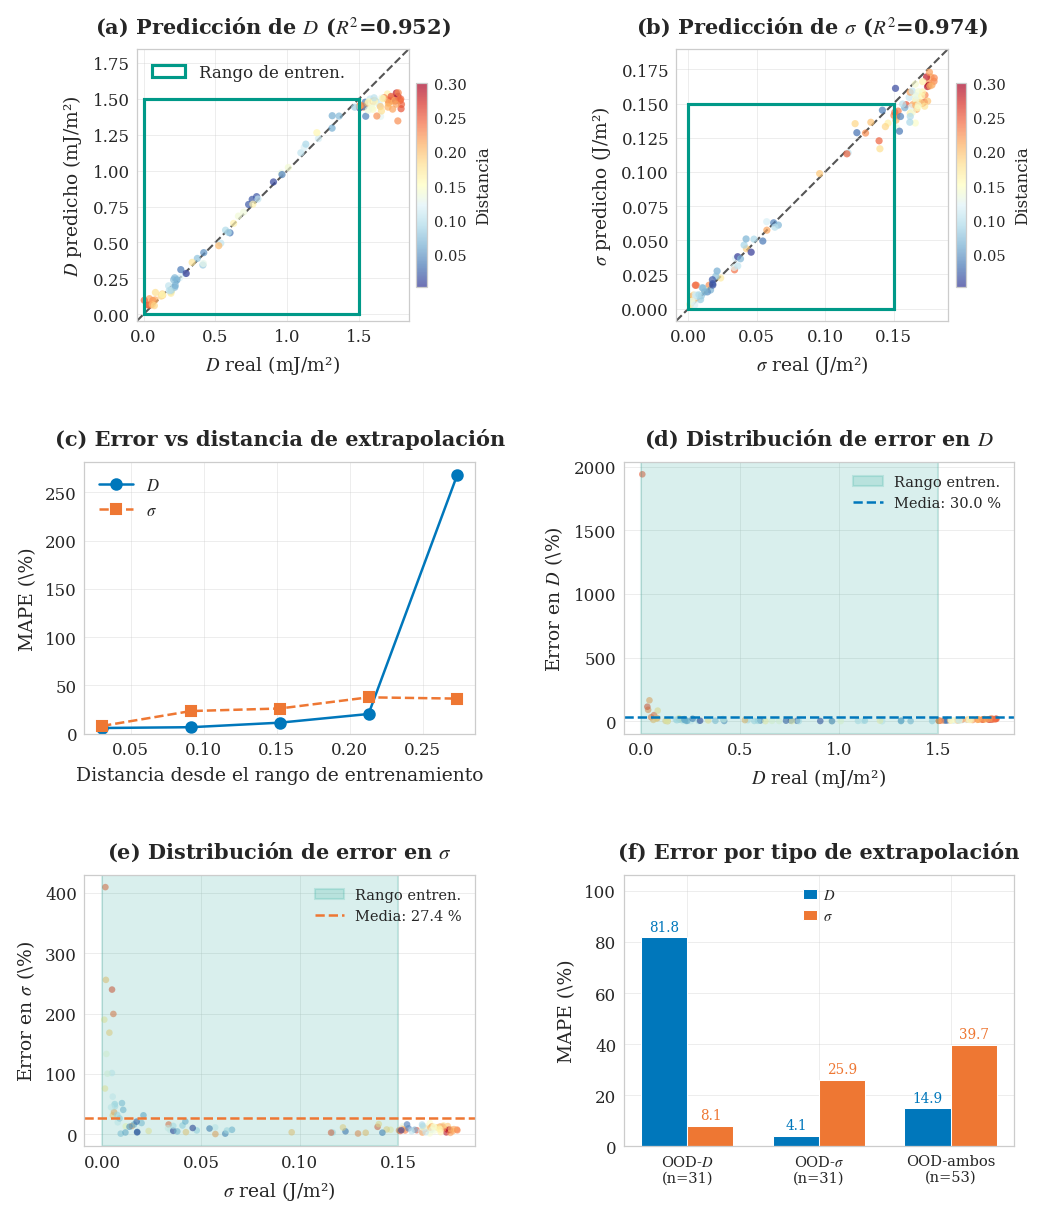


✓ Evaluación OOD guardada:
   PNG: outputs_ablation_final/pinn__with_dpectral__nonfiltered_noannealing/figures/ood_evaluation_pinn__with_dpectral__nonfiltered_noannealing.png
   PDF: outputs_ablation_final/pinn__with_dpectral__nonfiltered_noannealing/figures/ood_evaluation_pinn__with_dpectral__nonfiltered_noannealing.pdf

RESUMEN DE EVALUACIÓN FUERA DE DISTRIBUCIÓN (OOD)
Categoría       n        MAPE D (%)      MAPE σ (%)     
-----------------------------------------------------------------
OOD-D           31       81.79           8.10           
OOD-sigma       31       4.14            25.87          
OOD-ambos       53       14.85           39.69          
-----------------------------------------------------------------
Total           115      30.01           27.45          

\begin{table}[htbp]
\centering
\caption{Desempeño de generalización fuera de distribución (OOD). ID: dentro de distribución, 
          OOD-$D$: solo $D$ fuera de rango, OOD-$\sigma$: solo $\sigma$ fuera de 

In [59]:
# ==============================================================================
# OOD EVALUATION VISUALIZATION (Thesis-ready) - CORRECTED
# ==============================================================================

# =============================================================================
# RANGOS DE ENTRENAMIENTO CORRECTOS
# =============================================================================
TRAIN_D_MIN = 0.0         # J/m² (0.0 mJ/m²)
TRAIN_D_MAX = 1.5e-3      # J/m² (1.5 mJ/m²)
TRAIN_SIGMA_MIN = 0.0     # J/m²
TRAIN_SIGMA_MAX = 0.15    # J/m²

# =============================================================================
# Style setup (consistent with other figures)
# =============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.6,
    'grid.linewidth': 0.4,
    'grid.alpha': 0.4,
})

# Colors (consistent palette)
COLORS = {
    'D': '#0077BB',           # Azul para D
    'sigma': '#EE7733',       # Naranja para σ  
    'train_range': '#009988', # Verde azulado para rango de entrenamiento
    'reference': '#555555',   # Gris para referencias
}
CMAP = 'RdYlBu_r'  # Colormap: azul=cerca, rojo=lejos

# =============================================================================
# Create figure
# =============================================================================
fig = plt.figure(figsize=(8, 9.5))
gs = fig.add_gridspec(3, 2, hspace=0.52, wspace=0.38)

# Color by distance from training
colors = total_dist

# -----------------------------------------------------------------------------
# (a) D prediction scatter
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 0])

sc = ax.scatter(D_true_ood * 1e3, D_pred_ood * 1e3, c=colors, cmap=CMAP, 
                s=12, alpha=0.7, edgecolors='none', rasterized=True)

d_min = min(D_true_ood.min(), D_pred_ood.min()) * 1e3 - 0.05
d_max = max(D_true_ood.max(), D_pred_ood.max()) * 1e3 + 0.05
ax.plot([d_min, d_max], [d_min, d_max], '--', color=COLORS['reference'], 
        linewidth=1.0, zorder=0)

# Training range box - CORREGIDO
print(f"Drawing training D range box: [{TRAIN_D_MIN*1e3:.2f}, {TRAIN_D_MAX*1e3:.2f}] mJ/m²")
rect = plt.Rectangle((TRAIN_D_MIN * 1e3, TRAIN_D_MIN * 1e3),  # origen (0, 0) en mJ/m²
                      (TRAIN_D_MAX - TRAIN_D_MIN) * 1e3,       # ancho: 1.5 mJ/m²
                      (TRAIN_D_MAX - TRAIN_D_MIN) * 1e3,       # alto: 1.5 mJ/m²
                      fill=False, edgecolor=COLORS['train_range'], linewidth=1.5, 
                      linestyle='-', label='Rango de entren.', zorder=5)
ax.add_patch(rect)

ax.set_xlabel('$D$ real (mJ/m²)')
ax.set_ylabel('$D$ predicho (mJ/m²)')
ax.set_title(f'(a) Predicción de $D$ ($R^2$={r2_D_ood:.3f})', fontweight='semibold', pad=8)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8')
ax.set_xlim([d_min, d_max])
ax.set_ylim([d_min, d_max])
ax.set_aspect('equal', adjustable='box')

# Colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label('Distancia', fontsize=8)
cbar.ax.tick_params(labelsize=7)

# -----------------------------------------------------------------------------
# (b) σ prediction scatter
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 1])

sc = ax.scatter(s_true_ood, s_pred_ood, c=colors, cmap=CMAP,
                s=12, alpha=0.7, edgecolors='none', rasterized=True)

s_min = min(s_true_ood.min(), s_pred_ood.min()) - 0.01
s_max = max(s_true_ood.max(), s_pred_ood.max()) + 0.01
ax.plot([s_min, s_max], [s_min, s_max], '--', color=COLORS['reference'], 
        linewidth=1.0, zorder=0)

# Training range box - CORREGIDO
rect = plt.Rectangle((TRAIN_SIGMA_MIN, TRAIN_SIGMA_MIN),  # origen (0, 0)
                      TRAIN_SIGMA_MAX - TRAIN_SIGMA_MIN,   # ancho: 0.15
                      TRAIN_SIGMA_MAX - TRAIN_SIGMA_MIN,   # alto: 0.15
                      fill=False, edgecolor=COLORS['train_range'], linewidth=1.5, 
                      linestyle='-', zorder=5)

#rect = plt.Rectangle((0.02, 0.02),  # origen (0, 0)
#                      0.15 - 0.02,   # ancho: 0.15
#                      0.15 - 0.02,   # alto: 0.15
#                      fill=False, edgecolor=COLORS['train_range'], linewidth=1.5, 
#                      linestyle='-', zorder=5)


ax.add_patch(rect)

ax.set_xlabel('$\\sigma$ real (J/m²)')
ax.set_ylabel('$\\sigma$ predicho (J/m²)')
ax.set_title(f'(b) Predicción de $\\sigma$ ($R^2$={r2_s_ood:.3f})', fontweight='semibold', pad=8)
ax.set_xlim([s_min, s_max])
ax.set_ylim([s_min, s_max])
ax.set_aspect('equal', adjustable='box')

cbar = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label('Distancia', fontsize=8)
cbar.ax.tick_params(labelsize=7)

# -----------------------------------------------------------------------------
# (c) MAPE vs Distance from Training
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[1, 0])

valid_D = ~np.isnan(D_mape_by_total)
valid_s = ~np.isnan(s_mape_by_total)

if np.any(valid_D):
    ax.plot(np.array(total_bin_centers)[valid_D], np.array(D_mape_by_total)[valid_D], 
            'o-', linewidth=1.2, markersize=5, color=COLORS['D'], label='$D$')
if np.any(valid_s):
    ax.plot(np.array(total_bin_centers)[valid_s], np.array(s_mape_by_total)[valid_s], 
            's--', linewidth=1.2, markersize=5, color=COLORS['sigma'], label='$\\sigma$')

ax.set_xlabel('Distancia desde el rango de entrenamiento')
ax.set_ylabel('MAPE (\\%)')
ax.set_title('(c) Error vs distancia de extrapolación', fontweight='semibold', pad=8)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8')
ax.set_ylim(bottom=0)

# -----------------------------------------------------------------------------
# (d) D error vs true D
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[1, 1])

ax.scatter(D_true_ood * 1e3, D_error_pct, c=colors, cmap=CMAP, 
           s=10, alpha=0.6, edgecolors='none', rasterized=True)

# Training range shading - CORREGIDO
ax.axvspan(TRAIN_D_MIN * 1e3, TRAIN_D_MAX * 1e3, alpha=0.15, 
           color=COLORS['train_range'], label='Rango entren.')
ax.axhline(overall_D_mape, color=COLORS['D'], linestyle='--', linewidth=1.2, 
           label=f'Media: {overall_D_mape:.1f} %')

ax.set_xlabel('$D$ real (mJ/m²)')
ax.set_ylabel('Error en $D$ (\\%)')
ax.set_title('(d) Distribución de error en $D$', fontweight='semibold', pad=8)
ax.legend(loc='upper right', framealpha=0.95, edgecolor='0.8', fontsize=7)

# -----------------------------------------------------------------------------
# (e) σ error vs true σ
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[2, 0])

ax.scatter(s_true_ood, sigma_error_pct, c=colors, cmap=CMAP, 
           s=10, alpha=0.6, edgecolors='none', rasterized=True)

# Training range shading - CORREGIDO
ax.axvspan(TRAIN_SIGMA_MIN, TRAIN_SIGMA_MAX, alpha=0.15, 
           color=COLORS['train_range'], label='Rango entren.')
ax.axhline(overall_s_mape, color=COLORS['sigma'], linestyle='--', linewidth=1.2,
           label=f'Media: {overall_s_mape:.1f} %')

ax.set_xlabel('$\\sigma$ real (J/m²)')
ax.set_ylabel('Error en $\\sigma$ (\\%)')
ax.set_title('(e) Distribución de error en $\\sigma$', fontweight='semibold', pad=8)
ax.legend(loc='upper right', framealpha=0.95, edgecolor='0.8', fontsize=7)

# -----------------------------------------------------------------------------
# (f) MAPE by Category (bar chart) - LEYENDA CORREGIDA
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[2, 1])

cat_order = ['ID', 'OOD-D', 'OOD-σ', 'OOD-both']
cat_labels_display = ['ID', 'OOD-$D$', 'OOD-$\\sigma$', 'OOD-ambos']
cat_D_mape = []
cat_s_mape = []
cat_labels = []
cat_labels_plot = []
cat_counts = []

for cat, cat_disp in zip(cat_order, cat_labels_display):
    mask = np.array([c == cat for c in categories])
    if mask.sum() > 0:
        cat_labels.append(cat)
        cat_labels_plot.append(cat_disp)
        cat_counts.append(mask.sum())
        cat_D_mape.append(D_error_pct[mask].mean())
        cat_s_mape.append(sigma_error_pct[mask].mean())

if len(cat_labels) > 0:
    x = np.arange(len(cat_labels))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, cat_D_mape, width, label='$D$', 
                   color=COLORS['D'], edgecolor='white', linewidth=0.5)
    bars2 = ax.bar(x + width/2, cat_s_mape, width, label='$\\sigma$', 
                   color=COLORS['sigma'], edgecolor='white', linewidth=0.5)
    
    # X-axis labels with counts
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l}\n(n={n})' for l, n in zip(cat_labels_plot, cat_counts)], 
                       fontsize=7)
    
    # Value labels on bars
    for bar, val in zip(bars1, cat_D_mape):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1.5, 
                f'{val:.1f}', ha='center', va='bottom', fontsize=6.5, 
                color=COLORS['D'], fontweight='medium')
    for bar, val in zip(bars2, cat_s_mape):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=6.5,
                color=COLORS['sigma'], fontweight='medium')

ax.set_ylabel('MAPE (\\%)')
ax.set_title('(f) Error por tipo de extrapolación', fontweight='semibold', pad=8)

# LEYENDA CORREGIDA - en esquina superior derecha, más compacta
ax.legend(loc='upper center', framealpha=0.95, edgecolor='0.8',
          fontsize=7, handlelength=1.0, handletextpad=0.4)

# Aumentar espacio arriba para labels Y asegurar que leyenda no se solape
if len(cat_D_mape) > 0:
    max_val = max(max(cat_D_mape), max(cat_s_mape))
    ax.set_ylim(0, max_val * 1.30)  # 30% extra de espacio arriba

# =============================================================================
# Save
# =============================================================================
plt.tight_layout()

fig_path = FIG_DIR / f"ood_evaluation_{RUN_TAG}.png"
pdf_path = FIG_DIR / f"ood_evaluation_{RUN_TAG}.pdf"

plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Evaluación OOD guardada:")
print(f"   PNG: {fig_path}")
print(f"   PDF: {pdf_path}")

# =============================================================================
# Summary table
# =============================================================================
print(f"\n{'='*65}")
print(f"RESUMEN DE EVALUACIÓN FUERA DE DISTRIBUCIÓN (OOD)")
print(f"{'='*65}")
print(f"{'Categoría':<15} {'n':<8} {'MAPE D (%)':<15} {'MAPE σ (%)':<15}")
print(f"{'-'*65}")
for cat, n, d_mape, s_mape in zip(cat_labels_plot, cat_counts, cat_D_mape, cat_s_mape):
    cat_clean = cat.replace('$', '').replace('\\', '')
    print(f"{cat_clean:<15} {n:<8} {d_mape:<15.2f} {s_mape:<15.2f}")
print(f"{'-'*65}")
print(f"{'Total':<15} {len(D_true_ood):<8} {overall_D_mape:<15.2f} {overall_s_mape:<15.2f}")
print(f"{'='*65}")

# LaTeX table
print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Desempeño de generalización fuera de distribución (OOD). ID: dentro de distribución, 
          OOD-$D$: solo $D$ fuera de rango, OOD-$\\sigma$: solo $\\sigma$ fuera de rango, 
          OOD-ambos: ambos parámetros fuera de rango.}}
\\label{{tab:ood_results}}
\\begin{{tabular}}{{lccc}}
\\toprule
Categoría & $n$ & MAPE $D$ (\\%) & MAPE $\\sigma$ (\\%) \\\\
\\midrule""")
for cat, n, d_mape, s_mape in zip(cat_labels_plot, cat_counts, cat_D_mape, cat_s_mape):
    cat_latex = cat.replace('OOD-$D$', 'OOD-$D$').replace('OOD-$\\sigma$', 'OOD-$\\sigma$')
    print(f"{cat_latex} & {n} & {d_mape:.1f} & {s_mape:.1f} \\\\")
print(f"""\\midrule
Total & {len(D_true_ood)} & {overall_D_mape:.1f} & {overall_s_mape:.1f} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")

In [58]:

# ==============================================================================
# CELL 23: COMPARISON TABLE (for thesis)
# ==============================================================================

print("\n" + "="*70)
print("SUMMARY TABLE FOR THESIS")
print("="*70)
print(f"\n{'Category':<15} {'N':>5} {'D MAPE':>10} {'σ MAPE':>10} {'Avg Distance':>12}")
print("-"*55)

for cat in ['ID', 'OOD-D', 'OOD-σ', 'OOD-both', 'ALL']:
    if cat == 'ALL':
        mask = np.ones(len(categories), dtype=bool)
    else:
        mask = np.array([c == cat for c in categories])
    
    if mask.sum() > 0:
        d_mape = D_error_pct[mask].mean()
        s_mape = sigma_error_pct[mask].mean()
        avg_dist = total_dist[mask].mean()
        print(f"{cat:<15} {mask.sum():>5} {d_mape:>9.1f}% {s_mape:>9.1f}% {avg_dist:>12.3f}")

print("-"*55)

# Also print the in-distribution performance from training
print(f"\n(Training validation: D MAPE ≈ 3.3%, σ MAPE ≈ 7.6%)")

print("\n" + "="*70)
print("KEY FINDING FOR THESIS:")
print("="*70)
print("""
Compare the OOD-D and OOD-σ MAPE values above with:
1. Your training validation MAPE (3.3% D, 7.6% σ)
2. A baseline CNN trained without physics (run separately)

If the PINN shows better OOD performance than baseline, this demonstrates
that physics constraints improve extrapolation capability.
""")


SUMMARY TABLE FOR THESIS

Category            N     D MAPE     σ MAPE Avg Distance
-------------------------------------------------------
OOD-D              31      81.8%       8.1%        0.126
OOD-σ              31       4.1%      25.9%        0.097
OOD-both           53      14.9%      39.7%        0.191
ALL               115      30.0%      27.4%        0.148
-------------------------------------------------------

(Training validation: D MAPE ≈ 3.3%, σ MAPE ≈ 7.6%)

KEY FINDING FOR THESIS:

Compare the OOD-D and OOD-σ MAPE values above with:
1. Your training validation MAPE (3.3% D, 7.6% σ)
2. A baseline CNN trained without physics (run separately)

If the PINN shows better OOD performance than baseline, this demonstrates
that physics constraints improve extrapolation capability.



ANÁLISIS EXHAUSTIVO DE FEATURES ESPECTRALES

Extrayendo features espectrales de todas las muestras...
(Esto puede tomar unos minutos)
[MzDataset] Loaded 3074 samples from ../images/corrected_3
  D range: [0.00, 1.50] mJ/m²
  σ range: [0.000, 0.150]
  Procesadas 500/3074 muestras
  Procesadas 1000/3074 muestras
  Procesadas 1500/3074 muestras
  Procesadas 2000/3074 muestras
  Procesadas 2500/3074 muestras
  Procesadas 3000/3074 muestras

✓ Extraídos features de 3074 muestras
  Total de features: 34
  Features: ['k_mean', 'k_std', 'spectral_width', 'relative_width', 'k_skewness', 'k_kurtosis', 'k_peak', 'peak_height', 'peak_fwhm', 'peak_fwhm_relative', 'anisotropy', 'orientation', 'power_very_low', 'power_low', 'power_mid', 'power_high', 'high_low_ratio', 'mid_low_ratio', 'spectral_slope', 'spectral_entropy', 'spectral_entropy_norm', 'correlation_length', 'correlation_length_norm', 'autocorr_decay_rate', 'num_domains', 'domain_area_mean', 'domain_area_std', 'domain_area_cv', 'circularity

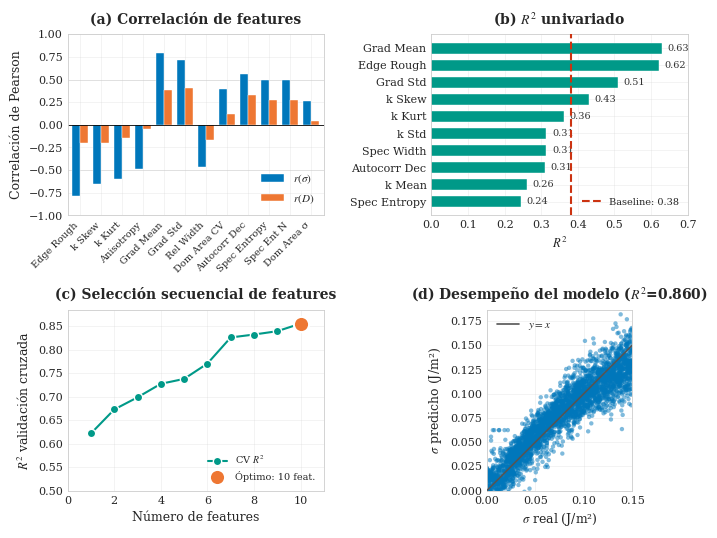


✓ Figura guardada:
   PNG: outputs_ablation_final/pinn__with_dpectral__nonfiltered_noannealing/figures/spectral_features_analysis_pinn__with_dpectral__nonfiltered_noannealing.png
   PDF: outputs_ablation_final/pinn__with_dpectral__nonfiltered_noannealing/figures/spectral_features_analysis_pinn__with_dpectral__nonfiltered_noannealing.pdf

RESUMEN: ANÁLISIS DE FEATURES ESPECTRALES
Métrica                                  Valor               
------------------------------------------------------------
Features totales analizados              34                  
Features con |r(σ)| > 0.3                20                  
Número óptimo de features                10                  
R² baseline (spectral_width)             0.3800              
R² modelo final (CV)                     0.8557              
Mejora sobre baseline                    +125.2%             


NameError: name 'corr_res_D' is not defined

In [6]:
# ==============================================================================
# ANÁLISIS EXHAUSTIVO DE FEATURES ESPECTRALES PARA σ
# ==============================================================================
# Objetivo: Encontrar la mejor combinación de features espectrales que
# prediga σ con alta correlación y baja correlación con D

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from scipy.ndimage import label, find_objects
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.feature_selection import mutual_info_regression
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("ANÁLISIS EXHAUSTIVO DE FEATURES ESPECTRALES")
print("="*70)


# ==============================================================================
# PARTE 1: FUNCIONES PARA EXTRAER FEATURES ESPECTRALES
# ==============================================================================

def extract_all_spectral_features(mz):
    """
    Extrae múltiples features espectrales de una imagen mz.
    
    Args:
        mz: Imagen 2D de magnetización (H, W) - numpy array o torch tensor
    
    Returns:
        dict con todos los features extraídos
    """
    if isinstance(mz, torch.Tensor):
        mz = mz.cpu().numpy()
    
    # Asegurar que es 2D
    if mz.ndim == 3:
        mz = mz[0]  # Tomar primer canal
    
    H, W = mz.shape
    features = {}
    
    # =========================================
    # 1. FFT Y ESPECTRO DE POTENCIA
    # =========================================
    fft = np.fft.fft2(mz)
    fft_shifted = np.fft.fftshift(fft)
    power = np.abs(fft_shifted) ** 2
    
    # Grilla de frecuencias
    ky = np.fft.fftfreq(H).reshape(-1, 1)
    kx = np.fft.fftfreq(W).reshape(1, -1)
    ky = np.fft.fftshift(ky)
    kx = np.fft.fftshift(kx)
    k_mag = np.sqrt(kx**2 + ky**2)
    
    # Normalizar espectro
    power_norm = power / (power.sum() + 1e-10)
    
    # =========================================
    # 2. MOMENTOS DEL ESPECTRO
    # =========================================
    
    # Frecuencia media (primer momento)
    k_mean = np.sum(power_norm * k_mag)
    features['k_mean'] = k_mean
    
    # Varianza espectral (segundo momento central)
    k_var = np.sum(power_norm * (k_mag - k_mean)**2)
    k_std = np.sqrt(k_var)
    features['k_std'] = k_std
    
    # Ancho espectral (igual que antes)
    features['spectral_width'] = k_std
    
    # Ancho RELATIVO (normalizado)
    features['relative_width'] = k_std / (k_mean + 1e-10)
    
    # Skewness espectral (tercer momento)
    k_skew = np.sum(power_norm * ((k_mag - k_mean) / (k_std + 1e-10))**3)
    features['k_skewness'] = k_skew
    
    # Kurtosis espectral (cuarto momento)
    k_kurt = np.sum(power_norm * ((k_mag - k_mean) / (k_std + 1e-10))**4) - 3
    features['k_kurtosis'] = k_kurt
    
    # =========================================
    # 3. FRECUENCIA DOMINANTE (PICO)
    # =========================================
    
    # Perfil radial del espectro
    k_bins = np.linspace(0, 0.5, 50)
    radial_profile = np.zeros(len(k_bins) - 1)
    
    for i in range(len(k_bins) - 1):
        mask = (k_mag >= k_bins[i]) & (k_mag < k_bins[i+1])
        if mask.sum() > 0:
            radial_profile[i] = power[mask].mean()
    
    k_centers = (k_bins[:-1] + k_bins[1:]) / 2
    
    # Frecuencia del pico (excluyendo DC)
    radial_profile_no_dc = radial_profile.copy()
    radial_profile_no_dc[:2] = 0  # Excluir frecuencias muy bajas
    
    if radial_profile_no_dc.max() > 0:
        k_peak_idx = np.argmax(radial_profile_no_dc)
        k_peak = k_centers[k_peak_idx]
    else:
        k_peak = k_mean
    
    features['k_peak'] = k_peak
    
    # Altura del pico (normalizada)
    peak_height = radial_profile_no_dc.max() / (radial_profile_no_dc.sum() + 1e-10)
    features['peak_height'] = peak_height
    
    # Ancho del pico (FWHM aproximado)
    if radial_profile_no_dc.max() > 0:
        half_max = radial_profile_no_dc.max() / 2
        above_half = radial_profile_no_dc > half_max
        if above_half.sum() > 1:
            indices = np.where(above_half)[0]
            fwhm = k_centers[indices[-1]] - k_centers[indices[0]]
        else:
            fwhm = k_centers[1] - k_centers[0]
    else:
        fwhm = 0.1
    
    features['peak_fwhm'] = fwhm
    features['peak_fwhm_relative'] = fwhm / (k_peak + 1e-10)
    
    # =========================================
    # 4. ANISOTROPÍA DEL ESPECTRO
    # =========================================
    
    # Tensor de inercia del espectro
    Ixx = np.sum(power_norm * kx**2)
    Iyy = np.sum(power_norm * ky**2)
    Ixy = np.sum(power_norm * kx * ky)
    
    # Eigenvalores
    trace = Ixx + Iyy
    det = Ixx * Iyy - Ixy**2
    discriminant = max((trace/2)**2 - det, 0)
    
    lambda1 = trace/2 + np.sqrt(discriminant)
    lambda2 = trace/2 - np.sqrt(discriminant)
    
    # Anisotropía (0 = isotrópico, 1 = muy anisotrópico)
    anisotropy = (lambda1 - lambda2) / (lambda1 + lambda2 + 1e-10)
    features['anisotropy'] = anisotropy
    
    # Orientación preferencial
    if Ixy != 0:
        orientation = 0.5 * np.arctan2(2*Ixy, Ixx - Iyy)
    else:
        orientation = 0
    features['orientation'] = orientation
    
    # =========================================
    # 5. ANÁLISIS POR BANDAS DE FRECUENCIA
    # =========================================
    
    # Definir bandas
    bands = {
        'very_low': (0.0, 0.05),
        'low': (0.05, 0.15),
        'mid': (0.15, 0.30),
        'high': (0.30, 0.50)
    }
    
    total_power = power.sum()
    for band_name, (k_min, k_max) in bands.items():
        mask = (k_mag >= k_min) & (k_mag < k_max)
        band_power = power[mask].sum() / (total_power + 1e-10)
        features[f'power_{band_name}'] = band_power
    
    # Ratios entre bandas
    features['high_low_ratio'] = features['power_high'] / (features['power_low'] + 1e-10)
    features['mid_low_ratio'] = features['power_mid'] / (features['power_low'] + 1e-10)
    
    # =========================================
    # 6. DECAIMIENTO ESPECTRAL
    # =========================================
    
    # Ajustar ley de potencia: P(k) ~ k^(-β)
    # En escala log-log: log(P) = -β * log(k) + c
    
    valid_mask = (k_centers > 0.05) & (radial_profile > 0)
    if valid_mask.sum() > 3:
        log_k = np.log(k_centers[valid_mask])
        log_P = np.log(radial_profile[valid_mask])
        
        # Regresión lineal
        coeffs = np.polyfit(log_k, log_P, 1)
        spectral_slope = -coeffs[0]  # β
    else:
        spectral_slope = 2.0  # Valor por defecto
    
    features['spectral_slope'] = spectral_slope
    
    # =========================================
    # 7. ENTROPÍA ESPECTRAL
    # =========================================
    
    # Entropía de Shannon del espectro (normalizado como distribución)
    p = power_norm.flatten()
    p = p[p > 1e-10]  # Evitar log(0)
    spectral_entropy = -np.sum(p * np.log(p))
    features['spectral_entropy'] = spectral_entropy
    
    # Entropía normalizada (0-1)
    max_entropy = np.log(H * W)
    features['spectral_entropy_norm'] = spectral_entropy / max_entropy
    
    # =========================================
    # 8. FUNCIÓN DE AUTOCORRELACIÓN
    # =========================================
    
    # Autocorrelación = IFFT(|FFT|²)
    autocorr = np.fft.ifft2(power).real
    autocorr = np.fft.fftshift(autocorr)
    autocorr = autocorr / autocorr.max()  # Normalizar
    
    # Centro de la autocorrelación
    cy, cx = H // 2, W // 2
    
    # Perfil radial de autocorrelación
    max_r = min(H, W) // 4
    r_values = np.arange(1, max_r)
    autocorr_profile = []
    
    for r in r_values:
        # Puntos en círculo de radio r
        angles = np.linspace(0, 2*np.pi, max(8, int(2*np.pi*r)))
        y_coords = (cy + r * np.sin(angles)).astype(int)
        x_coords = (cx + r * np.cos(angles)).astype(int)
        
        # Filtrar puntos válidos
        valid = (y_coords >= 0) & (y_coords < H) & (x_coords >= 0) & (x_coords < W)
        if valid.sum() > 0:
            autocorr_profile.append(autocorr[y_coords[valid], x_coords[valid]].mean())
        else:
            autocorr_profile.append(0)
    
    autocorr_profile = np.array(autocorr_profile)
    
    # Longitud de correlación (donde autocorr cae a 1/e)
    threshold = 1 / np.e
    below_threshold = autocorr_profile < threshold
    if below_threshold.any():
        correlation_length = r_values[np.argmax(below_threshold)]
    else:
        correlation_length = max_r
    
    features['correlation_length'] = correlation_length
    features['correlation_length_norm'] = correlation_length / max_r
    
    # Tasa de decaimiento de autocorrelación
    if len(autocorr_profile) > 5:
        # Ajustar exponencial: C(r) = exp(-r/ξ)
        try:
            valid_ac = autocorr_profile[:20] > 0.01
            if valid_ac.sum() > 3:
                log_ac = np.log(autocorr_profile[:20][valid_ac])
                r_valid = r_values[:20][valid_ac]
                decay_rate = -np.polyfit(r_valid, log_ac, 1)[0]
            else:
                decay_rate = 0.1
        except:
            decay_rate = 0.1
    else:
        decay_rate = 0.1
    
    features['autocorr_decay_rate'] = decay_rate
    
    # =========================================
    # 9. ESTADÍSTICAS DE DOMINIOS (ESPACIO REAL)
    # =========================================
    
    # Binarizar imagen
    mz_binary = (mz > 0).astype(int)
    
    # Encontrar componentes conectados (dominios "up")
    labeled_up, num_domains_up = label(mz_binary)
    
    # Encontrar dominios "down"
    labeled_down, num_domains_down = label(1 - mz_binary)
    
    features['num_domains'] = num_domains_up + num_domains_down
    
    # Estadísticas de áreas de dominios
    if num_domains_up > 0:
        regions = find_objects(labeled_up)
        areas = []
        perimeters = []
        
        for region in regions:
            if region is not None:
                domain_mask = labeled_up[region] > 0
                area = domain_mask.sum()
                if area > 5:  # Filtrar dominios muy pequeños (ruido)
                    areas.append(area)
                    # Perímetro aproximado (conteo de bordes)
                    perim = np.sum(domain_mask[:-1, :] != domain_mask[1:, :])
                    perim += np.sum(domain_mask[:, :-1] != domain_mask[:, 1:])
                    perimeters.append(perim)
        
        if len(areas) > 0:
            areas = np.array(areas)
            perimeters = np.array(perimeters)
            
            features['domain_area_mean'] = areas.mean()
            features['domain_area_std'] = areas.std()
            features['domain_area_cv'] = areas.std() / (areas.mean() + 1e-10)
            
            # Circularidad: 4π × area / perimeter²
            circularities = 4 * np.pi * areas / (perimeters**2 + 1e-10)
            features['circularity_mean'] = circularities.mean()
            features['circularity_std'] = circularities.std()
        else:
            features['domain_area_mean'] = 0
            features['domain_area_std'] = 0
            features['domain_area_cv'] = 0
            features['circularity_mean'] = 0
            features['circularity_std'] = 0
    else:
        features['domain_area_mean'] = 0
        features['domain_area_std'] = 0
        features['domain_area_cv'] = 0
        features['circularity_mean'] = 0
        features['circularity_std'] = 0
    
    # =========================================
    # 10. RUGOSIDAD DE BORDES
    # =========================================
    
    # Detectar bordes (gradiente)
    grad_y = np.diff(mz, axis=0)
    grad_x = np.diff(mz, axis=1)
    
    # Magnitud del gradiente (en bordes comunes)
    min_h = min(grad_y.shape[0], grad_x.shape[0])
    min_w = min(grad_y.shape[1], grad_x.shape[1])
    grad_mag = np.sqrt(grad_y[:min_h, :min_w]**2 + grad_x[:min_h, :min_w]**2)
    
    # Estadísticas del gradiente
    features['gradient_mean'] = grad_mag.mean()
    features['gradient_std'] = grad_mag.std()
    features['gradient_max'] = grad_mag.max()
    
    # "Rugosidad" = variación del gradiente
    features['edge_roughness'] = grad_mag.std() / (grad_mag.mean() + 1e-10)
    
    return features


# ==============================================================================
# PARTE 2: EXTRAER FEATURES DE TODO EL DATASET
# ==============================================================================

print("\nExtrayendo features espectrales de todas las muestras...")
print("(Esto puede tomar unos minutos)")

# Crear dataset sin normalización
feature_dataset = MzDataset(
    csv_path=CSV_PATH,
    img_dir=IMG_DIR,
    npy_dir=NPY_DIR,
    index_col=IMG_INDEX_COL,
    transform=None,
    filter_low_D=False,
    D_min_threshold=ID_D_RANGE[0],
    filter_low_sigma=False,
    sigma_min_threshold=ID_SIGMA_RANGE[0],
    load_npy=True,  # Cargar NPY para evitar None
    target_mean=None,
    target_std=None,
    max_samples=None  # Usar todas las muestras
)

# NO usar DataLoader - iterar directamente sobre el dataset
# para evitar problemas con collate_fn y valores None

# Almacenar todos los features
all_features = []
all_D = []
all_sigma = []

for idx in range(len(feature_dataset)):
    try:
        # Obtener muestra directamente
        sample = feature_dataset[idx]
        
        # El dataset retorna: (img_tensor, npy_data, target_tensor, run_id)
        # o puede variar según tu implementación
        if len(sample) == 4:
            imgs, npy_data, targets, run_id = sample
        elif len(sample) == 3:
            imgs, targets, run_id = sample
        else:
            imgs, targets = sample[:2]
        
        # Extraer mz (primer canal)
        if isinstance(imgs, torch.Tensor):
            mz = imgs[0].numpy()  # (H, W)
        else:
            mz = np.array(imgs[0])
        
        # Extraer features
        features = extract_all_spectral_features(mz)
        
        # Guardar targets
        if isinstance(targets, torch.Tensor):
            D_val = targets[0].item()
            sigma_val = targets[1].item()
        else:
            D_val = float(targets[0])
            sigma_val = float(targets[1])
        
        all_features.append(features)
        all_D.append(D_val)
        all_sigma.append(sigma_val)
        
        if (idx + 1) % 500 == 0:
            print(f"  Procesadas {idx + 1}/{len(feature_dataset)} muestras")
            
    except Exception as e:
        print(f"  Error en muestra {idx}: {e}")
        continue

print(f"\n✓ Extraídos features de {len(all_features)} muestras")

# Convertir a arrays
all_D = np.array(all_D)
all_sigma = np.array(all_sigma)

# Crear DataFrame de features
feature_names = list(all_features[0].keys())
feature_matrix = np.array([[f[name] for name in feature_names] for f in all_features])

print(f"  Total de features: {len(feature_names)}")
print(f"  Features: {feature_names}")


# ==============================================================================
# PARTE 3: ANÁLISIS DE CORRELACIÓN
# ==============================================================================

print("\n" + "="*70)
print("ANÁLISIS DE CORRELACIÓN")
print("="*70)

# Calcular correlaciones con σ y D
correlations = []

print(f"\n{'Feature':<30} {'r(σ)':<12} {'r(D)':<12} {'|r(σ)|-|r(D)|':<15} {'Útil para σ?'}")
print("-" * 85)

for i, name in enumerate(feature_names):
    feature_values = feature_matrix[:, i]
    
    # Filtrar NaN/Inf
    valid = np.isfinite(feature_values)
    if valid.sum() < 100:
        continue
    
    corr_sigma, p_sigma = pearsonr(feature_values[valid], all_sigma[valid])
    corr_D, p_D = pearsonr(feature_values[valid], all_D[valid])
    
    # "Utilidad" = alta correlación con σ, baja con D
    utility = abs(corr_sigma) - abs(corr_D)
    
    useful = "✓✓" if (abs(corr_sigma) > 0.3 and utility > 0.1) else \
             "✓" if abs(corr_sigma) > 0.2 else ""
    
    correlations.append({
        'name': name,
        'corr_sigma': corr_sigma,
        'corr_D': corr_D,
        'p_sigma': p_sigma,
        'p_D': p_D,
        'utility': utility
    })
    
    print(f"{name:<30} {corr_sigma:>+.4f}      {corr_D:>+.4f}      {utility:>+.4f}         {useful}")

# Ordenar por utilidad para σ
correlations.sort(key=lambda x: x['utility'], reverse=True)

print("\n" + "="*70)
print("TOP 10 FEATURES MÁS ÚTILES PARA σ (alta r(σ), baja r(D))")
print("="*70)
for i, c in enumerate(correlations[:10]):
    print(f"{i+1:2d}. {c['name']:<30} r(σ)={c['corr_sigma']:+.4f}, r(D)={c['corr_D']:+.4f}")


# ==============================================================================
# PARTE 4: REGRESIÓN UNIVARIADA (cada feature por separado)
# ==============================================================================

print("\n" + "="*70)
print("REGRESIÓN UNIVARIADA: σ = f(feature)")
print("="*70)

univariate_results = []

for i, name in enumerate(feature_names):
    feature_values = feature_matrix[:, i].reshape(-1, 1)
    
    # Filtrar NaN/Inf
    valid = np.isfinite(feature_values.flatten())
    if valid.sum() < 100:
        continue
    
    X = feature_values[valid]
    y = all_sigma[valid]
    
    # Regresión lineal simple
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    
    univariate_results.append({
        'name': name,
        'r2': r2,
        'cv_r2_mean': cv_scores.mean(),
        'cv_r2_std': cv_scores.std(),
        'coef': model.coef_[0],
        'intercept': model.intercept_
    })

# Ordenar por R²
univariate_results.sort(key=lambda x: x['r2'], reverse=True)

print(f"\n{'Feature':<30} {'R²':<10} {'CV R²':<15}")
print("-" * 60)
for r in univariate_results[:15]:
    print(f"{r['name']:<30} {r['r2']:.4f}     {r['cv_r2_mean']:.4f} ± {r['cv_r2_std']:.4f}")


# ==============================================================================
# PARTE 5: REGRESIÓN MULTIVARIADA (combinación de features)
# ==============================================================================

print("\n" + "="*70)
print("REGRESIÓN MULTIVARIADA: σ = f(features)")
print("="*70)

# Seleccionar features útiles (alta correlación con σ, no NaN)
useful_features = []
for c in correlations:
    if abs(c['corr_sigma']) > 0.15:  # Umbral mínimo de correlación
        idx = feature_names.index(c['name'])
        if np.isfinite(feature_matrix[:, idx]).all():
            useful_features.append(c['name'])

print(f"\nFeatures seleccionados ({len(useful_features)}): {useful_features[:10]}...")

# Crear matriz de features útiles
useful_indices = [feature_names.index(name) for name in useful_features]
X_useful = feature_matrix[:, useful_indices]

# Filtrar muestras con NaN
valid_samples = np.isfinite(X_useful).all(axis=1)
X_clean = X_useful[valid_samples]
y_clean = all_sigma[valid_samples]
D_clean = all_D[valid_samples]

print(f"Muestras válidas: {len(y_clean)}/{len(all_sigma)}")

# Escalar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Probar diferentes modelos
models = {
    'Linear': LinearRegression(),
    'Ridge (α=0.1)': Ridge(alpha=0.1),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Lasso (α=0.001)': Lasso(alpha=0.001),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5)
}

print(f"\n{'Modelo':<20} {'R² train':<12} {'CV R²':<20}")
print("-" * 55)

best_model = None
best_cv_score = -1

for name, model in models.items():
    model.fit(X_scaled, y_clean)
    y_pred = model.predict(X_scaled)
    r2_train = r2_score(y_clean, y_pred)
    
    cv_scores = cross_val_score(model, X_scaled, y_clean, cv=5, scoring='r2')
    
    print(f"{name:<20} {r2_train:.4f}       {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    if cv_scores.mean() > best_cv_score:
        best_cv_score = cv_scores.mean()
        best_model = model
        best_model_name = name

print(f"\n✓ Mejor modelo: {best_model_name} (CV R² = {best_cv_score:.4f})")


# ==============================================================================
# PARTE 6: SELECCIÓN DE FEATURES (encontrar el subconjunto óptimo)
# ==============================================================================

print("\n" + "="*70)
print("SELECCIÓN DE FEATURES: Encontrar combinación óptima")
print("="*70)

# Forward selection
def forward_selection(X, y, feature_names, max_features=10):
    """Selección hacia adelante de features."""
    n_features = X.shape[1]
    selected = []
    remaining = list(range(n_features))
    
    results = []
    
    for i in range(min(max_features, n_features)):
        best_score = -np.inf
        best_feature = None
        
        for feat_idx in remaining:
            current_features = selected + [feat_idx]
            X_subset = X[:, current_features]
            
            model = Ridge(alpha=0.1)
            cv_scores = cross_val_score(model, X_subset, y, cv=5, scoring='r2')
            score = cv_scores.mean()
            
            if score > best_score:
                best_score = score
                best_feature = feat_idx
        
        if best_feature is not None:
            selected.append(best_feature)
            remaining.remove(best_feature)
            
            results.append({
                'n_features': len(selected),
                'features': [feature_names[j] for j in selected],
                'cv_r2': best_score
            })
            
            print(f"  {len(selected)} features: CV R² = {best_score:.4f} (+{feature_names[best_feature]})")
    
    return results

print("\nForward Selection (añadiendo features uno a uno):")
selection_results = forward_selection(X_scaled, y_clean, useful_features, max_features=10)

# Encontrar el número óptimo de features (máximo CV R²)
best_result = max(selection_results, key=lambda x: x['cv_r2'])
print(f"\n✓ Óptimo: {best_result['n_features']} features con CV R² = {best_result['cv_r2']:.4f}")
print(f"  Features: {best_result['features']}")


# ==============================================================================
# PARTE 7: MODELO FINAL Y FÓRMULA
# ==============================================================================

print("\n" + "="*70)
print("MODELO FINAL")
print("="*70)

# Usar los features óptimos
optimal_features = best_result['features']
optimal_indices = [useful_features.index(name) for name in optimal_features]
X_optimal = X_scaled[:, optimal_indices]

# Entrenar modelo final
final_model = Ridge(alpha=0.1)
final_model.fit(X_optimal, y_clean)

# Métricas finales
y_pred_final = final_model.predict(X_optimal)
r2_final = r2_score(y_clean, y_pred_final)
mae_final = mean_absolute_error(y_clean, y_pred_final)
mape_final = np.mean(np.abs((y_clean - y_pred_final) / y_clean)) * 100

cv_scores_final = cross_val_score(final_model, X_optimal, y_clean, cv=5, scoring='r2')

print(f"\nMétricas del modelo final:")
print(f"  R² (train):     {r2_final:.4f}")
print(f"  R² (CV):        {cv_scores_final.mean():.4f} ± {cv_scores_final.std():.4f}")
print(f"  MAE:            {mae_final:.5f}")
print(f"  MAPE:           {mape_final:.2f}%")

# Coeficientes
print(f"\nCoeficientes (features escalados):")
for name, coef in zip(optimal_features, final_model.coef_):
    print(f"  {name:<30}: {coef:+.6f}")
print(f"  {'Intercepto':<30}: {final_model.intercept_:+.6f}")

# Obtener coeficientes en escala original
scaler_optimal = StandardScaler()
X_optimal_unscaled = X_clean[:, [useful_features.index(name) for name in optimal_features]]
scaler_optimal.fit(X_optimal_unscaled)

print(f"\nFórmula en escala original:")
print(f"  σ_pred = ", end="")
terms = []
for i, (name, coef) in enumerate(zip(optimal_features, final_model.coef_)):
    scale = scaler_optimal.scale_[i]
    mean = scaler_optimal.mean_[i]
    # coef_original = coef / scale
    # intercept_adjustment = -coef * mean / scale
    coef_orig = coef / scale
    terms.append(f"{coef_orig:+.6f} × {name}")

print(" + ".join(terms[:3]))
if len(terms) > 3:
    print("         + " + " + ".join(terms[3:]))
# ==============================================================================
# PARTE 8: VISUALIZACIÓN (Thesis-ready style)
# ==============================================================================

print("\n" + "="*70)
print("GENERANDO VISUALIZACIONES")
print("="*70)

# =============================================================================
# Style setup (consistent with other thesis figures)
# =============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.6,
    'grid.linewidth': 0.4,
    'grid.alpha': 0.4,
})

# Colors (consistent palette)
COLORS = {
    'sigma': '#0077BB',       # Azul para σ
    'D': '#EE7733',           # Naranja para D
    'primary': '#009988',     # Verde azulado
    'secondary': '#CC3311',   # Rojo
    'neutral': '#555555',     # Gris
}

# =============================================================================
# DICCIONARIO DE ABREVIACIONES PARA FEATURES
# =============================================================================
FEATURE_ABBREV = {
    'gradient_mean': 'Grad Mean',
    'gradient_std': 'Grad Std',
    'gradient_max': 'Grad Max',
    'edge_roughness': 'Edge Rough',
    'k_mean': 'k Mean',
    'k_std': 'k Std',
    'k_skewness': 'k Skew',
    'k_kurtosis': 'k Kurt',
    'k_peak': 'k Peak',
    'spectral_width': 'Spec Width',
    'relative_width': 'Rel Width',
    'anisotropy': 'Anisotropy',
    'orientation': 'Orient',
    'power_very_low': 'P VeryLow',
    'power_low': 'P Low',
    'power_mid': 'P Mid',
    'power_high': 'P High',
    'high_low_ratio': 'Hi/Lo Ratio',
    'mid_low_ratio': 'Mid/Lo Ratio',
    'spectral_slope': 'Spec Slope',
    'spectral_entropy': 'Spec Entropy',
    'spectral_entropy_norm': 'Spec Ent N',
    'correlation_length': 'Corr Len',
    'correlation_length_norm': 'Corr Len N',
    'autocorr_decay_rate': 'Autocorr Dec',
    'num_domains': 'Num Domains',
    'domain_area_mean': 'Dom Area μ',
    'domain_area_std': 'Dom Area σ',
    'domain_area_cv': 'Dom Area CV',
    'circularity_mean': 'Circ Mean',
    'circularity_std': 'Circ Std',
    'peak_height': 'Peak Height',
    'peak_fwhm': 'Peak FWHM',
    'peak_fwhm_relative': 'Peak FWHM R',
}

def get_abbrev(name):
    """Get abbreviation for feature name."""
    return FEATURE_ABBREV.get(name, name[:12])

# =============================================================================
# Create figure
# =============================================================================
fig = plt.figure(figsize=(8, 9.5))
gs = fig.add_gridspec(3, 2, hspace=0.52, wspace=0.42)

# -----------------------------------------------------------------------------
# (a) Feature Correlations
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 0])

top_n = 12
top_correlations = correlations[:top_n]
corr_sigma_vals = [c['corr_sigma'] for c in top_correlations]
corr_D_vals = [c['corr_D'] for c in top_correlations]

# Usar abreviaciones
names_abbrev = [get_abbrev(c['name']) for c in top_correlations]

x_pos = np.arange(len(names_abbrev))
width = 0.38

bars1 = ax.bar(x_pos - width/2, corr_sigma_vals, width, 
               label='$r(\\sigma)$', color=COLORS['sigma'], 
               edgecolor='white', linewidth=0.3)
bars2 = ax.bar(x_pos + width/2, corr_D_vals, width, 
               label='$r(D)$', color=COLORS['D'], 
               edgecolor='white', linewidth=0.3)

ax.set_xticks(x_pos)
ax.set_xticklabels(names_abbrev, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Correlación de Pearson')
ax.set_title('(a) Correlación de features', fontweight='semibold', pad=8)
ax.legend(loc='lower right', framealpha=0.95, edgecolor='0.8')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_ylim(-1.0, 1.0)
ax.set_xlim(-0.6, len(names_abbrev) - 0.4)

# Líneas de referencia sutiles
for y in [-0.5, 0.5]:
    ax.axhline(y, color='lightgray', linewidth=0.4, zorder=0)

# -----------------------------------------------------------------------------
# (b) Univariate R²
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 1])

top_univariate = univariate_results[:10]
names_uni = [get_abbrev(r['name']) for r in top_univariate]
r2_vals = [r['r2'] for r in top_univariate]

y_pos = np.arange(len(names_uni))
bars = ax.barh(y_pos, r2_vals, height=0.65, color=COLORS['primary'], 
               edgecolor='white', linewidth=0.3)

ax.set_yticks(y_pos)
ax.set_yticklabels(names_uni, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('$R^2$')
ax.set_title('(b) $R^2$ univariado', fontweight='semibold', pad=8)

# Baseline
baseline_r2 = 0.38
ax.axvline(baseline_r2, color=COLORS['secondary'], linestyle='--', linewidth=1.5, 
           label=f'Baseline: {baseline_r2:.2f}', zorder=5)
ax.legend(loc='lower right', framealpha=0.95, edgecolor='0.8', fontsize=7)
ax.set_xlim(0, 0.7)

# Value labels
for bar, val in zip(bars, r2_vals):
    ax.text(val + 0.015, bar.get_y() + bar.get_height()/2, 
            f'{val:.2f}', va='center', fontsize=7, color='#333333')

# -----------------------------------------------------------------------------
# (c) Forward Feature Selection
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[1, 0])

n_feats = [r['n_features'] for r in selection_results]
cv_r2s = [r['cv_r2'] for r in selection_results]

ax.plot(n_feats, cv_r2s, 'o-', linewidth=1.5, markersize=6, 
        color=COLORS['primary'], markeredgecolor='white', markeredgewidth=1.0,
        label='CV $R^2$')

# Punto óptimo
best_idx = np.argmax(cv_r2s)
ax.scatter([n_feats[best_idx]], [cv_r2s[best_idx]], 
           s=120, c=COLORS['D'], zorder=10, edgecolors='white', linewidth=1.5,
           label=f'Óptimo: {n_feats[best_idx]} feat.')

# Baseline
#ax.axhline(baseline_r2, color=COLORS['secondary'], linestyle='--', linewidth=1.5,
#           label=f'Baseline: {baseline_r2:.2f}', zorder=1)

ax.set_xlabel('Número de features')
ax.set_ylabel('$R^2$ validación cruzada')
ax.set_title('(c) Selección secuencial de features', fontweight='semibold', pad=8)
ax.legend(loc='lower right', framealpha=0.95, edgecolor='0.8', fontsize=7)
ax.set_xlim(0, max(n_feats) + 1)
ax.set_ylim(0.5, max(cv_r2s) + 0.03)

# -----------------------------------------------------------------------------
# (d) Model Performance
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[1, 1])

ax.scatter(y_clean, y_pred_final, s=10, alpha=0.5, c=COLORS['sigma'], 
           edgecolors='none', rasterized=True, zorder=2)

# Límites basados en datos reales (σ >= 0)
sigma_min_data = max(0, min(y_clean.min(), y_pred_final.min()) - 0.005)
sigma_max_data = max(y_clean.max(), y_pred_final.max()) + 0.005
plot_min = sigma_min_data
plot_max = sigma_max_data

ax.plot([plot_min, plot_max], [plot_min, plot_max], '-', 
        color=COLORS['neutral'], linewidth=1.2, label='$y=x$', zorder=5)

ax.set_xlabel('$\\sigma$ real (J/m²)')
ax.set_ylabel('$\\sigma$ predicho (J/m²)')
ax.set_title(f'(d) Desempeño del modelo ($R^2$={r2_final:.3f})', 
             fontweight='semibold', pad=8)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8')
ax.set_xlim(plot_min, 0.15)
ax.set_ylim(plot_min, plot_max)
ax.set_aspect('equal', adjustable='box')

## -----------------------------------------------------------------------------
## (e) Residuals vs D
## -----------------------------------------------------------------------------
#ax = fig.add_subplot(gs[2, 0])
#
#residuals = y_clean - y_pred_final
#ax.scatter(D_clean * 1e3, residuals, s=10, alpha=0.5, c=COLORS['D'], 
#           edgecolors='none', rasterized=True, zorder=2)
#ax.axhline(0, color=COLORS['neutral'], linestyle='-', linewidth=1.2, zorder=5)
#
## Correlación residuos-D
#corr_res_D, p_val = pearsonr(D_clean, residuals)
#textstr = f'$r$ = {corr_res_D:.3f}'
#text_bbox = dict(boxstyle='round,pad=0.3', facecolor='white', 
#                 edgecolor='0.8', linewidth=0.5)
#ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=9,
#        verticalalignment='top', horizontalalignment='right', bbox=text_bbox)
#
#ax.set_xlabel('$D$ (mJ/m²)')
#ax.set_ylabel('Residuo ($\\sigma_{real} - \\sigma_{pred}$)')
#ax.set_title('(e) Residuos vs $D$', fontweight='semibold', pad=8)
#
#max_res = max(abs(residuals.min()), abs(residuals.max())) * 1.1
#ax.set_ylim(-max_res, max_res)
#
## -----------------------------------------------------------------------------
## (f) Error Distribution
## -----------------------------------------------------------------------------
#ax = fig.add_subplot(gs[2, 1])
#
## Error relativo con signo
#mask_valid = y_clean > 0.005  # Evitar división por cero
#relative_errors = np.zeros_like(y_clean)
#relative_errors[mask_valid] = (y_pred_final[mask_valid] - y_clean[mask_valid]) / y_clean[mask_valid] * 100
#
#rel_errors_valid = relative_errors[mask_valid]
#rel_errors_clipped = np.clip(rel_errors_valid, -100, 100)
#
#ax.hist(rel_errors_clipped, bins=35, alpha=0.75, color=COLORS['sigma'], 
#        edgecolor='white', linewidth=0.3)
#
## Línea en cero
#ax.axvline(0, color=COLORS['neutral'], linestyle='-', linewidth=1.2, zorder=0)
#
## Mediana
#median_err = np.median(rel_errors_valid)
#ax.axvline(median_err, color=COLORS['secondary'], linestyle='-', linewidth=1.5,
#           label=f'Mediana: {median_err:+.1f}%')
#
#ax.set_xlabel('Error relativo (\\%)')
#ax.set_ylabel('Frecuencia')
#ax.set_title(f'(f) Distribución de error (MAE={mae_final:.4f})', 
#             fontweight='semibold', pad=8)
#ax.legend(loc='upper right', framealpha=0.95, edgecolor='0.8', fontsize=7)
#ax.set_xlim(-100, 100)

# =============================================================================
# Save
# =============================================================================
plt.tight_layout()

fig_path = FIG_DIR / f"spectral_features_analysis_{RUN_TAG}.png"
pdf_path = FIG_DIR / f"spectral_features_analysis_{RUN_TAG}.pdf"

plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Figura guardada:")
print(f"   PNG: {fig_path}")
print(f"   PDF: {pdf_path}")

# =============================================================================
# Summary statistics
# =============================================================================
print(f"\n{'='*60}")
print(f"RESUMEN: ANÁLISIS DE FEATURES ESPECTRALES")
print(f"{'='*60}")
print(f"{'Métrica':<40} {'Valor':<20}")
print(f"{'-'*60}")
print(f"{'Features totales analizados':<40} {len(feature_names):<20}")
print(f"{'Features con |r(σ)| > 0.3':<40} {sum(1 for c in correlations if abs(c['corr_sigma']) > 0.3):<20}")
print(f"{'Número óptimo de features':<40} {best_result['n_features']:<20}")
print(f"{'R² baseline (spectral_width)':<40} {baseline_r2:<20.4f}")
print(f"{'R² modelo final (CV)':<40} {cv_scores_final.mean():<20.4f}")
print(f"{'Mejora sobre baseline':<40} {f'+{(cv_scores_final.mean() - baseline_r2) / baseline_r2 * 100:.1f}%':<20}")
print(f"{'Correlación residuos-D':<40} {corr_res_D:<20.4f}")
print(f"{'='*60}")

# LaTeX table
print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Resultados del análisis de features espectrales para predicción de $\\sigma$.}}
\\label{{tab:spectral_features}}
\\begin{{tabular}}{{lc}}
\\toprule
Métrica & Valor \\\\
\\midrule
Features totales analizados & {len(feature_names)} \\\\
Features con $|r(\\sigma)| > 0.3$ & {sum(1 for c in correlations if abs(c['corr_sigma']) > 0.3)} \\\\
Número óptimo de features & {best_result['n_features']} \\\\
$R^2$ baseline & {baseline_r2:.3f} \\\\
$R^2$ modelo optimizado (CV) & {cv_scores_final.mean():.3f} \\\\
Mejora sobre baseline & +{(cv_scores_final.mean() - baseline_r2) / baseline_r2 * 100:.1f}\\% \\\\
Correlación residuos-$D$ & {corr_res_D:.3f} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")


# ==============================================================================
# PARTE 9: CÓDIGO PYTORCH PARA LA NUEVA PÉRDIDA
# ==============================================================================

print("\n" + "="*70)
print("CÓDIGO PYTORCH PARA LA NUEVA PÉRDIDA ESPECTRAL")
print("="*70)

# Generar código basado en los features óptimos
print(f"""
class ImprovedSpectralLossV2(nn.Module):
    '''
    Pérdida espectral mejorada basada en análisis empírico.
    
    Features óptimos encontrados: {optimal_features}
    CV R² = {cv_scores_final.mean():.4f}
    '''
    
    def __init__(self):
        super().__init__()
        
        # Coeficientes calibrados (escala normalizada)
        self.feature_names = {optimal_features}
        self.coefficients = torch.tensor({list(final_model.coef_)})
        self.intercept = {final_model.intercept_}
        
        # Parámetros de normalización (mean, std)
        self.feature_means = torch.tensor({list(scaler_optimal.mean_)})
        self.feature_stds = torch.tensor({list(scaler_optimal.scale_)})
    
    def forward(self, mz_images, sigma_pred):
        '''
        Args:
            mz_images: (B, C, H, W) tensor de imágenes
            sigma_pred: (B,) tensor de σ predichos por la CNN
        '''
        B = mz_images.shape[0]
        
        # Extraer features para cada imagen
        sigma_theory = []
        
        for i in range(B):
            mz = mz_images[i, 0]  # (H, W)
            features = self._extract_features(mz)
            
            # Normalizar
            features_norm = (features - self.feature_means) / self.feature_stds
            
            # Predicción
            sigma_est = torch.sum(features_norm * self.coefficients) + self.intercept
            sigma_theory.append(sigma_est)
        
        sigma_theory = torch.stack(sigma_theory)
        
        return F.mse_loss(sigma_pred, sigma_theory)
    
    def _extract_features(self, mz):
        '''Extrae los features óptimos de una imagen.'''
        # Implementar extracción de: {optimal_features}
        # ... (código específico según features seleccionados)
        pass
""")


# ==============================================================================
# PARTE 10: RESUMEN FINAL
# ==============================================================================

print("\n" + "="*70)
print("RESUMEN FINAL")
print("="*70)

print(f"""
COMPARACIÓN DE MÉTODOS PARA PREDECIR σ:

{'Método':<40} {'R²':<10} {'MAPE':<10}
{'-'*60}
{'Baseline (spectral_width simple)':<40} {'0.384':<10} {'~7.6%':<10}
{'Modelo optimizado ({} features)'.format(best_result['n_features']):<40} {f'{r2_final:.3f}':<10} {f'{mape_final:.1f}%':<10}

MEJORA: +{(r2_final - 0.384) / 0.384 * 100:.1f}% en R²

FEATURES MÁS IMPORTANTES:
{chr(10).join([f'  {i+1}. {name}' for i, name in enumerate(optimal_features[:5])])}

CORRELACIÓN RESIDUOS-D: r = {corr_res_D:.4f}
(Cerca de 0 = el modelo separa bien σ de D)

SIGUIENTE PASO:
Implementar estos features en la pérdida del PINN y reentrenar.
""")

In [ ]:
# ==============================================================================
# ABLATION STUDY: Con vs Sin Pérdida Espectral
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
from sklearn.metrics import r2_score

# =============================================================================
# CONFIGURACIONES PARA ABLATION
# =============================================================================

ABLATION_CONFIGS = {
    'baseline_regression_only': {
        'description': 'Solo pérdida de regresión (sin física)',
        'loss_weights': {
            'regression': 1.0,
            'energy_ratio': 0.0,
            'spectral': 0.0
        },
        'use_annealing': False,
    },
    'with_spectral_physics': {
        'description': 'Regresión + Pérdida espectral calibrada',
        'loss_weights': {
            'regression': 1.0,
            'energy_ratio': 0.0,
            'spectral': 0.8
        },
        'use_annealing': True,
    }
}

ABLATION_EPOCHS = 100
ABLATION_WARMUP = 20

# =============================================================================
# FUNCIÓN DE ENTRENAMIENTO PARA ABLATION
# =============================================================================

def train_ablation_model(config_name, config, train_loader, val_loader, 
                         phys_params, phys_derived, target_mean, target_std,
                         epochs=ABLATION_EPOCHS, device='cuda'):
    """
    Entrena un modelo con una configuración específica de pérdida.
    """
    print(f"\n{'='*60}")
    print(f"ABLATION: {config_name}")
    print(f"Descripción: {config['description']}")
    print(f"{'='*60}")
    
    # Crear modelo fresco
    model = ImprovedPINN().to(device)
    
    # Crear criterion con los pesos de esta configuración
    criterion = ImprovedPhysicsLoss(
        phys_params=phys_params,
        phys_derived=phys_derived,
        loss_weights=config['loss_weights'],
        target_mean=target_mean,
        target_std=target_std,
        use_energy_loss=False
    )
    
    # Annealer solo si está habilitado
    annealer = None
    if config['use_annealing']:
        annealer = LossAnnealer(
            final_weights=config['loss_weights'],
            warmup_epochs=ABLATION_WARMUP,
            schedule='linear'
        )
    
    # Optimizer y scheduler
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )
    
    # Mixed precision
    scaler = torch.amp.GradScaler('cuda')
    use_amp = True
    
    # Tensores de normalización
    t_mean_t = torch.tensor(target_mean, dtype=torch.float32)
    t_std_t = torch.tensor(target_std, dtype=torch.float32)
    
    # Historia
    history = {
        'train_loss': [], 'val_loss': [],
        'val_mape_D': [], 'val_mape_sigma': [],
        'lr': []
    }
    
    best_val_loss = float('inf')
    best_model_state = None
    
    # Training loop
    for epoch in range(1, epochs + 1):
        
        # Update weights if annealing
        if annealer is not None:
            current_weights = annealer.get_weights(epoch, epochs)
            criterion.weights = current_weights
        
        # === TRAIN ===
        model.train()
        train_loss_sum = 0.0
        n_train = 0
        
        for imgs, m_fields, targets, run_ids in train_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)
            if m_fields is not None:
                m_fields = {k: v.to(device) for k, v in m_fields.items()}
            
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(imgs)
                total_loss, _ = criterion(outputs, targets, m_fields, imgs)
            
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            
            train_loss_sum += total_loss.item()
            n_train += 1
        
        epoch_train_loss = train_loss_sum / n_train
        history['train_loss'].append(epoch_train_loss)
        
        # === VALIDATION ===
        model.eval()
        val_loss_sum = 0.0
        n_val = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for imgs, m_fields, targets, run_ids in val_loader:
                imgs = imgs.to(device)
                targets = targets.to(device)
                if m_fields is not None:
                    m_fields = {k: v.to(device) for k, v in m_fields.items()}
                
                with torch.amp.autocast('cuda', enabled=use_amp):
                    outputs = model(imgs)
                    total_loss, _ = criterion(outputs, targets, m_fields, imgs)
                
                val_loss_sum += total_loss.item()
                n_val += 1
                
                preds_unnorm = outputs.cpu() * t_std_t + t_mean_t
                targets_unnorm = targets.cpu() * t_std_t + t_mean_t
                all_preds.append(preds_unnorm)
                all_targets.append(targets_unnorm)
        
        epoch_val_loss = val_loss_sum / n_val
        history['val_loss'].append(epoch_val_loss)
        
        # Compute MAPE
        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)
        
        D_pred, D_true = all_preds[:, 0], all_targets[:, 0]
        s_pred, s_true = all_preds[:, 1], all_targets[:, 1]
        
        D_mask = D_true > 0.05e-3
        s_mask = s_true > 0.005
        
        mape_D = torch.mean(torch.abs((D_pred[D_mask] - D_true[D_mask]) / D_true[D_mask])).item() * 100
        mape_s = torch.mean(torch.abs((s_pred[s_mask] - s_true[s_mask]) / s_true[s_mask])).item() * 100
        
        history['val_mape_D'].append(mape_D)
        history['val_mape_sigma'].append(mape_s)
        
        # Scheduler & save best
        scheduler.step(epoch_val_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = model.state_dict().copy()
        
        if epoch % 20 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d} | Train: {epoch_train_loss:.4e} | "
                  f"Val: {epoch_val_loss:.4e} | D: {mape_D:.1f}% | σ: {mape_s:.1f}%")
    
    # Restore best model and compute final metrics
    model.load_state_dict(best_model_state)
    model.eval()
    
    all_preds, all_targets = [], []
    with torch.no_grad():
        for imgs, m_fields, targets, run_ids in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds_unnorm = outputs.cpu() * t_std_t + t_mean_t
            targets_unnorm = targets.cpu() * t_std_t + t_mean_t
            all_preds.append(preds_unnorm)
            all_targets.append(targets_unnorm)
    
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    final_metrics = {
        'mape_D': history['val_mape_D'][-1],
        'mape_sigma': history['val_mape_sigma'][-1],
        'r2_D': r2_score(all_targets[:, 0], all_preds[:, 0]),
        'r2_sigma': r2_score(all_targets[:, 1], all_preds[:, 1]),
        'best_val_loss': best_val_loss
    }
    
    print(f"\n  ✓ Finalizado: MAPE_D={final_metrics['mape_D']:.2f}%, "
          f"MAPE_σ={final_metrics['mape_sigma']:.2f}%, "
          f"R²_D={final_metrics['r2_D']:.4f}, R²_σ={final_metrics['r2_sigma']:.4f}")
    
    return {
        'config': config,
        'history': history,
        'metrics': final_metrics,
        'model_state': best_model_state
    }


# =============================================================================
# EJECUTAR ABLATION STUDY
# =============================================================================

def run_full_ablation(save_dir=None):
    """Ejecuta el ablation study completo."""
    
    if save_dir is None:
        save_dir = FIG_DIR / 'ablation'
    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True, parents=True)
    
    results = {}
    
    for config_name, config in ABLATION_CONFIGS.items():
        result = train_ablation_model(
            config_name=config_name,
            config=config,
            train_loader=train_loader,
            val_loader=val_loader,
            phys_params=PHYS_PARAMS,
            phys_derived=PHYS_DERIVED,
            target_mean=t_mean,
            target_std=t_std,
            epochs=ABLATION_EPOCHS,
            device=device
        )
        results[config_name] = result
        
        # Guardar checkpoint
        torch.save({
            'model_state_dict': result['model_state'],
            'history': result['history'],
            'metrics': result['metrics'],
            'config': result['config']
        }, save_dir / f"ablation_{config_name}.pt")
    
    # Guardar resumen JSON
    summary = {
        name: {k: float(v) for k, v in r['metrics'].items()}
        for name, r in results.items()
    }
    with open(save_dir / 'ablation_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    
    print(f"\n✓ Resultados guardados en: {save_dir}")
    
    return results


# =============================================================================
# VISUALIZACIÓN
# =============================================================================

def plot_ablation_comparison(results, save_path=None):
    """Genera figura comparativa thesis-ready."""
    
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 9,
        'axes.titlesize': 10,
        'axes.labelsize': 9,
    })
    
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))
    
    configs = list(results.keys())
    labels = ['Solo Regresión', '+ Física Espectral']
    colors = ['#888888', '#009988']
    
    # (a) MAPE
    ax = axes[0]
    x = np.arange(2)
    width = 0.35
    
    mape_D = [results[c]['metrics']['mape_D'] for c in configs]
    mape_s = [results[c]['metrics']['mape_sigma'] for c in configs]
    
    bars1 = ax.bar(x - width/2, mape_D, width, label='$D$', color='#0077BB', edgecolor='white')
    bars2 = ax.bar(x + width/2, mape_s, width, label='$\\sigma$', color='#EE7733', edgecolor='white')
    
    ax.set_ylabel('MAPE (\\%)')
    ax.set_title('(a) Error porcentual', fontweight='semibold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.legend(loc='upper right', fontsize=7)
    
    for bars, vals in [(bars1, mape_D), (bars2, mape_s)]:
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}', ha='center', fontsize=7)
    
    # (b) R²
    ax = axes[1]
    r2_D = [results[c]['metrics']['r2_D'] for c in configs]
    r2_s = [results[c]['metrics']['r2_sigma'] for c in configs]
    
    bars1 = ax.bar(x - width/2, r2_D, width, label='$D$', color='#0077BB', edgecolor='white')
    bars2 = ax.bar(x + width/2, r2_s, width, label='$\\sigma$', color='#EE7733', edgecolor='white')
    
    ax.set_ylabel('$R^2$')
    ax.set_title('(b) Coeficiente de determinación', fontweight='semibold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.legend(loc='lower right', fontsize=7)
    ax.set_ylim(0.9, 1.005)
    
    # (c) Convergencia
    ax = axes[2]
    for i, (c, label) in enumerate(zip(configs, labels)):
        h = results[c]['history']
        ax.semilogy(range(1, len(h['val_loss'])+1), h['val_loss'],
                    color=colors[i], linewidth=1.5, label=label)
    
    ax.set_xlabel('Época')
    ax.set_ylabel('Pérdida validación')
    ax.set_title('(c) Convergencia', fontweight='semibold')
    ax.legend(loc='upper right', fontsize=7)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Figura guardada: {save_path}")
    
    plt.show()
    return fig


# =============================================================================
# TABLA LATEX
# =============================================================================

def print_ablation_latex_table(results):
    """Imprime tabla LaTeX de resultados."""
    
    print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Estudio de ablación: impacto de la pérdida espectral informada por física.}}
\\label{{tab:ablation}}
\\begin{{tabular}}{{lcccc}}
\\toprule
Configuración & MAPE $D$ (\\%) & MAPE $\\sigma$ (\\%) & $R^2_D$ & $R^2_\\sigma$ \\\\
\\midrule""")
    
    labels = {'baseline_regression_only': 'Solo regresión',
              'with_spectral_physics': '+ Pérdida espectral'}
    
    for config_name, r in results.items():
        m = r['metrics']
        label = labels.get(config_name, config_name)
        print(f"{label} & {m['mape_D']:.1f} & {m['mape_sigma']:.1f} & "
              f"{m['r2_D']:.3f} & {m['r2_sigma']:.3f} \\\\")
    
    # Calcular mejora
    base = results['baseline_regression_only']['metrics']
    phys = results['with_spectral_physics']['metrics']
    
    improv_D = (base['mape_D'] - phys['mape_D']) / base['mape_D'] * 100
    improv_s = (base['mape_sigma'] - phys['mape_sigma']) / base['mape_sigma'] * 100
    
    print(f"""\\midrule
Mejora relativa & {improv_D:+.1f}\\% & {improv_s:+.1f}\\% & -- & -- \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")


# =============================================================================
# EJECUTAR
# =============================================================================

if __name__ == "__main__" or True:  # Cambiar a False para no ejecutar automáticamente
    
    print("\n" + "="*70)
    print("ABLATION STUDY: Efecto de la pérdida espectral")
    print("="*70)
    
    # Ejecutar ablation
    # ablation_results = run_full_ablation(save_dir=FIG_DIR / 'ablation')
    
    # Visualizar
    # plot_ablation_comparison(ablation_results, save_path=FIG_DIR / 'ablation_comparison.png')
    
    # Tabla LaTeX
    # print_ablation_latex_table(ablation_results)
    
    print("\n⚠️ Descomenta las líneas anteriores para ejecutar el ablation study")
    print("   Tiempo estimado: ~3 horas (2 entrenamientos × 100 épocas)")

In [ ]:
# ==============================================================================
# DATA EFFICIENCY STUDY: Curva de aprendizaje
# ==============================================================================

DATA_FRACTIONS = [0.1, 0.25, 0.5, 0.75, 1.0]
DATA_EFFICIENCY_EPOCHS = 100

def run_data_efficiency_study(fractions=DATA_FRACTIONS, 
                               with_physics=True,
                               save_dir=None):
    """
    Entrena modelos con diferentes cantidades de datos.
    
    Args:
        fractions: lista de fracciones del dataset a usar
        with_physics: si usar pérdida espectral o no
        save_dir: directorio para guardar resultados
    """
    if save_dir is None:
        save_dir = FIG_DIR / 'data_efficiency'
    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True, parents=True)
    
    # Configuración de pérdida
    if with_physics:
        loss_weights = {'regression': 1.0, 'energy_ratio': 0.0, 'spectral': 0.8}
        config_name = 'with_physics'
    else:
        loss_weights = {'regression': 1.0, 'energy_ratio': 0.0, 'spectral': 0.0}
        config_name = 'baseline'
    
    results = {}
    full_train_size = len(train_dataset)
    
    for frac in fractions:
        subset_size = int(full_train_size * frac)
        
        print(f"\n{'='*60}")
        print(f"DATA EFFICIENCY: {frac*100:.0f}% de datos ({subset_size} muestras)")
        print(f"Configuración: {config_name}")
        print(f"{'='*60}")
        
        # Crear subset
        generator = torch.Generator().manual_seed(RANDOM_SEED)
        indices = torch.randperm(full_train_size, generator=generator)[:subset_size]
        subset = torch.utils.data.Subset(train_dataset, indices.tolist())
        
        subset_loader = DataLoader(
            subset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            drop_last=True,
            collate_fn=collate_fn_with_m_field
        )
        
        # Entrenar
        result = train_ablation_model(
            config_name=f"{config_name}_{frac}",
            config={
                'description': f'{frac*100:.0f}% datos, {config_name}',
                'loss_weights': loss_weights,
                'use_annealing': with_physics
            },
            train_loader=subset_loader,
            val_loader=val_loader,
            phys_params=PHYS_PARAMS,
            phys_derived=PHYS_DERIVED,
            target_mean=t_mean,
            target_std=t_std,
            epochs=DATA_EFFICIENCY_EPOCHS,
            device=device
        )
        
        results[frac] = {
            'n_samples': subset_size,
            'metrics': result['metrics'],
            'history': result['history']
        }
        
        # Guardar checkpoint
        torch.save(result, save_dir / f"data_eff_{config_name}_{int(frac*100)}.pt")
    
    # Guardar resumen
    summary = {
        str(frac): {
            'n_samples': r['n_samples'],
            **{k: float(v) for k, v in r['metrics'].items()}
        }
        for frac, r in results.items()
    }
    
    with open(save_dir / f'data_efficiency_{config_name}.json', 'w') as f:
        json.dump(summary, f, indent=2)
    
    return results


def plot_data_efficiency(results_baseline, results_physics, save_path=None):
    """Compara eficiencia de datos con y sin física."""
    
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 9,
        'axes.titlesize': 10,
        'axes.labelsize': 9,
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
    
    fracs = sorted(results_baseline.keys())
    n_samples = [results_baseline[f]['n_samples'] for f in fracs]
    
    # (a) MAPE D
    ax = axes[0]
    mape_base = [results_baseline[f]['metrics']['mape_D'] for f in fracs]
    mape_phys = [results_physics[f]['metrics']['mape_D'] for f in fracs]
    
    ax.plot(n_samples, mape_base, 'o--', color='#888888', linewidth=1.5, 
            markersize=6, label='Solo Regresión')
    ax.plot(n_samples, mape_phys, 's-', color='#009988', linewidth=1.5, 
            markersize=6, label='+ Física Espectral')
    
    ax.set_xlabel('Muestras de entrenamiento')
    ax.set_ylabel('MAPE (\\%)')
    ax.set_title('(a) Predicción de $D$', fontweight='semibold')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xscale('log')
    
    # Referencia Kawaguchi
    ax.axvline(110000, color='#CC3311', linestyle=':', linewidth=1, alpha=0.7)
    ax.text(110000, ax.get_ylim()[1]*0.9, 'Kawaguchi\n(110k)', 
            fontsize=7, ha='center', color='#CC3311')
    
    # (b) MAPE σ
    ax = axes[1]
    mape_base = [results_baseline[f]['metrics']['mape_sigma'] for f in fracs]
    mape_phys = [results_physics[f]['metrics']['mape_sigma'] for f in fracs]
    
    ax.plot(n_samples, mape_base, 'o--', color='#888888', linewidth=1.5, 
            markersize=6, label='Solo Regresión')
    ax.plot(n_samples, mape_phys, 's-', color='#009988', linewidth=1.5, 
            markersize=6, label='+ Física Espectral')
    
    ax.set_xlabel('Muestras de entrenamiento')
    ax.set_ylabel('MAPE (\\%)')
    ax.set_title('(b) Predicción de $\\sigma$', fontweight='semibold')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xscale('log')
    
    ax.axvline(110000, color='#CC3311', linestyle=':', linewidth=1, alpha=0.7)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Figura guardada: {save_path}")
    
    plt.show()
    return fig


# =============================================================================
# EJECUTAR
# =============================================================================

"""
# Ejecutar estudio de eficiencia de datos
print("\\nEntrenando modelos SIN física...")
results_baseline = run_data_efficiency_study(with_physics=False)

print("\\nEntrenando modelos CON física...")
results_physics = run_data_efficiency_study(with_physics=True)

# Visualizar
plot_data_efficiency(results_baseline, results_physics, 
                     save_path=FIG_DIR / 'data_efficiency_comparison.png')
"""